In [1]:
# [0] 시스템 기초 설정 및 환경 구축
import os
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 및 시각화 한글 폰트 설정
warnings.filterwarnings('ignore')
if platform.system() == 'Darwin': 
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': 
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# [1] 데이터 전처리 및 검증 구조 설계
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, 
    StratifiedKFold, cross_validate, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# [2] 머신러닝 알고리즘 라인업 (Systemic Line-up)
# 2-1. 선형, 인접 이웃, SVM 및 기초 트리
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# 2-2. 앙상블 및 고성능 부스팅 모델
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    ExtraTreesClassifier, StackingClassifier, HistGradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 2-3. Automated ML (AutoGluon)
from autogluon.tabular import TabularPredictor

# [3] 성능 평가 지표 (KPI)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)

print("✅ 모든 라이브러리 로드 및 환경 설정 완료")

✅ 모든 라이브러리 로드 및 환경 설정 완료


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
import math

In [3]:
#!/bin/bash
# !kaggle datasets download prachi13/customer-analytics -p ./data

In [4]:
import os

HOME = os.getcwd()
# 압축 파일의 위치
zipPath = os.path.join(HOME, 'data','customer-analytics.zip')
# 압축 해제 할 위치
targetPath = os.path.join(HOME, 'data')

In [5]:
# from zipfile import ZipFile

# with ZipFile(zipPath, 'r') as zip_ref:
#     zip_ref.extractall(targetPath)

In [6]:
trainPath = os.path.join(targetPath, 'Train.csv')
df = pd.read_csv(trainPath)
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [8]:
df.isna().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [9]:
TARGET = 'Reached.on.Time_Y.N'
target = 'Reached.on.Time_Y.N'

빠른 분석을 위해 레이블 인코딩 후 히트맵 시각화

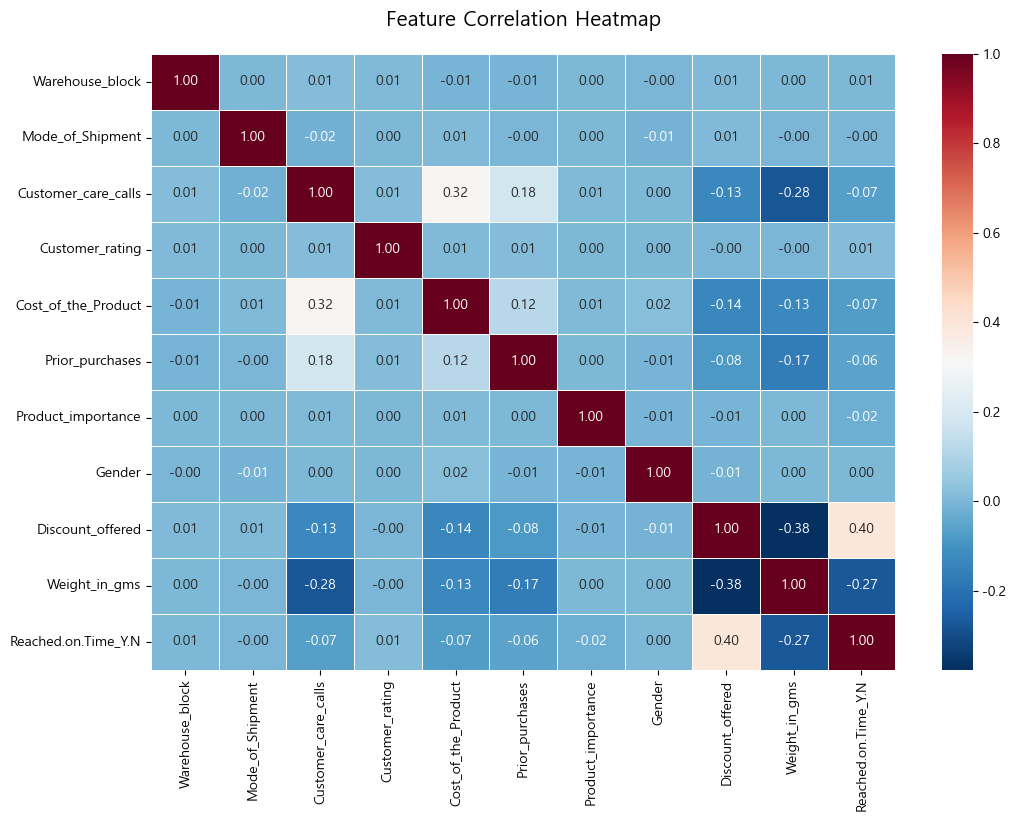

In [10]:


data = df.copy().drop(columns=['ID'])

# 범주형 변수 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
object_cols = data.select_dtypes(include=['object']).columns

for col in object_cols:
    data[col] = le.fit_transform(data[col])

# 히트맵 시각화
plt.figure(figsize=(12, 8)) 
sns.heatmap(data.corr(), annot=True, fmt='.2f', 
            cmap='RdBu_r', 
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Heatmap', fontsize=15, pad=20)
plt.show()

유의미한 상관계수
* Discount_offered: 0.4
* Weight_in_gms: -0.27

그 외의 가능성 있는 항목
* Cost_of_the_Product: -0.07
* Customer_care_calls: -0.07
* prior_purchases: -0.06

검증용 데이터 분리

In [11]:
# 1. stratify 옵션을 써서 정답(Reached.on.Time_Y.N) 비율을 유지하며 8:2로 나눕니다.
# 이 함수는 내부적으로 데이터를 랜덤하게 섞어주기 때문에 sample을 따로 안 써도 됩니다.
part1, part2 = train_test_split(df, 
                                test_size=0.2, 
                                random_state=42, 
                                stratify=df['Reached.on.Time_Y.N'])

# 2. 각각 파일로 저장
part1.to_csv('data/train_df.csv', index=False)
part2.to_csv('data/test_df.csv', index=False)

print("데이터 분할 및 저장 완료!")
print(f"학습용: {part1.shape}, 테스트용: {part2.shape}")

데이터 분할 및 저장 완료!
학습용: (8799, 12), 테스트용: (2200, 12)


In [12]:
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')
train_df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,7921,D,Road,4,1,261,2,medium,F,9,4158,0
1,1530,F,Ship,3,3,162,2,low,F,26,1659,1
2,10522,B,Ship,3,2,221,2,medium,M,9,4466,0
3,9559,D,Ship,3,5,157,4,medium,F,2,4640,0
4,969,A,Flight,2,5,272,2,low,M,24,3638,1


In [13]:
# target 데이터의 분포가 6:4로 비슷하게 이루어져 있음
print(f"배송 지연 확률: {train_df['Reached.on.Time_Y.N'].mean() * 100:.2f}%")

배송 지연 확률: 59.67%


| 컬럼명 (Column Name) | 설명 (Description) | 구분/범위 (Value Range) | 비고 (Additional Notes) |
| :--- | :--- | :--- | :--- |
| **ID** | 고객 고유 번호 | 숫자 (Numeric) | 인덱스. 정보 가치 없음|
| **Warehouse block** | 창고 구역 | A, B, C, D, E | 대규모 창고 내 구역 구분 |
| **Mode of shipment** | 배송 수단 | Ship, Flight, Road | 선박, 항공, 육로 배송 |
| **Customer care calls** | 고객 센터 문의 횟수 | 숫자 (Numeric) | 배송 관련 문의 전화 건수 |
| **Customer rating** | 고객 만족도 평점 | 1(낮음) ~ 5(높음) | 배송에 대한 만족도가 아닐수 있음에 주의 |
| **Cost of the product** | 제품 가격 | US 달러 ($) | 해당 제품의 판매가 |
| **Prior purchases** | 이전 구매 횟수 | 숫자 (Numeric) | 해당 고객의 과거 구매 이력 |
| **Product importance** | 제품 중요도 | low, medium, high | 중요도의 기준이 무엇인지 확인 불가 |
| **Gender** | 성별 | Male, Female |  |
| **Discount offered** | 할인액 | 1~65의 정수 | 할인 금액. 할인율과 다를것으로 추측 |
| **Weight in gms** | 제품 무게 | 그램 (g) | 제품의 실제 무게 |
| **Reached on time** | **정시 도착 여부** | 0: 정시, 1: 지연 | **타겟 변수 (Target Variable)** |

#### 특성 분류
범주형과 수치형의 분리

In [14]:
def split_feature_types(df, threshold=10):
    """
    ID를 제외하고 범주형과 수치형을 분리합니다.
    수치형 중에서도 고유값(unique) 개수가 threshold 이하이면 범주형으로 간주합니다.
    """
    temp_df = df.copy()
    if 'ID' in temp_df.columns:
        temp_df = temp_df.drop(columns=['ID'])
        
    # 타겟 제외
    target_name = 'Reached.on.Time_Y.N'
    features = [col for col in temp_df.columns if col != target_name]
    
    cat_cols = []
    num_cols = []
    
    for col in features:
        # 1. 데이터 타입이 object/category거나, 고유값 개수가 적은 경우 범주형으로 분류
        if temp_df[col].dtype in ['object', 'category'] or temp_df[col].nunique() <= threshold:
            cat_cols.append(col)
        # 2. 그 외에는 수치형으로 분류
        else:
            num_cols.append(col)

    print(f'범주형:{cat_cols}')
    print(f'숫자형:{num_cols}')
    return cat_cols, num_cols

In [15]:
cat_cols, num_cols = split_feature_types(train_df)

범주형:['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']
숫자형:['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']


### 시각화 함수 정의

In [16]:
# 범주형 특성의 시각화

target = 'Reached.on.Time_Y.N'

def plot_categorical_analysis(df, features, target):
    """
    범주형 특성 리스트를 받아 왼쪽에는 빈도 분포(Count), 
    오른쪽에는 타겟 지연율(Rate)을 나란히 시각화합니다.
    """
    num_features = len(features)
    # 한 행에 한 특성씩(왼쪽/오른쪽 두 개 그래프) 배치하므로 rows는 특성 개수와 같습니다.
    rows = num_features 
    
    plt.figure(figsize=(10, rows * 3))
    plt.suptitle('Categorical Feature Analysis: Distribution vs Delay Rate', fontsize=14, fontweight='bold', y=1.01)

    for i, col in enumerate(features):
        
        if df[col].dtype.name == 'category':
            order = df[col].cat.categories.tolist()
        else:
            order = sorted(df[col].unique())
        
        # --- 왼쪽: 빈도 분포 (Count Plot) ---
        plt.subplot(rows, 2, i * 2 + 1)
        sns.countplot(x=col, data=df, order=order, palette='Pastel1', hue=col, legend=False)
        plt.title(f'{col} Distribution', fontsize=10)
        plt.xlabel('') # 가독성을 위해 x축 레이블 생략 가능
       
        # --- 오른쪽: 지연율 (Delay Rate Bar Plot) ---
        plt.subplot(rows, 2, i * 2 + 2)
        # 지연율 계산
        ax = sns.barplot(
            x=col, y=target, data=df, order=order, 
            palette='viridis', hue=col, legend=False, errorbar=None
        )
        
        # 전체 평균 지연율 기준선
        avg_rate = df[target].mean()
        ax.axhline(avg_rate, color='red', linestyle='--', alpha=0.6)
        
        # 수치 표시 (%)
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.1%}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', fontsize=9, xytext=(0, 5),
                        textcoords='offset points')

        plt.title(f'{col} Delay Rate', fontsize=10)
        plt.xlabel('')
        plt.ylabel('')
        plt.ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

In [17]:
# 수치형 특성의 시각화

def plot_numeric_analysis(df, features, target):
    """
    수치형 특성 리스트를 받아 한 행에 KDE, Boxplot, Histogram+KDE를 시각화합니다.
    """
    num_features = len(features)
    # 한 행에 3개씩 배치
    plt.figure(figsize=(18, num_features * 4))
    plt.suptitle('Numerical Feature Analysis: KDE vs Boxplot vs Histogram', fontsize=18, fontweight='bold', y=1.02)

    for i, col in enumerate(features):
        # 1. KDE Plot: 두 그룹의 밀도 곡선 비교
        plt.subplot(num_features, 3, i*3 + 1)
        sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, palette='viridis', alpha=0.5)
        plt.title(f'{col} - Density Curve', fontsize=12)

        # 2. Boxplot: 중앙값 및 이상치 확인
        plt.subplot(num_features, 3, i*3 + 2)
        sns.boxplot(data=df, x=target, y=col, hue=target, palette='viridis', legend=False)
        plt.title(f'{col} - Outliers & Range', fontsize=12)
        
        # 3. Histogram + KDE: 실제 데이터 빈도와 곡선 결합
        plt.subplot(num_features, 3, i*3 + 3)
        sns.histplot(data=df, x=col, hue=target, kde=True, element="step", palette='viridis', alpha=0.3)
        plt.title(f'{col} - Histogram (Step)', fontsize=12)

    plt.tight_layout()
    plt.show()

### 각 특성별 지연율

In [18]:
# 시각화 가독성을 위해 범주 순서 정렬
importance_order = ['low', 'medium', 'high']
train_df['Product_importance'] = pd.Categorical(train_df['Product_importance'], 
                                         categories=importance_order, 
                                         ordered=True)

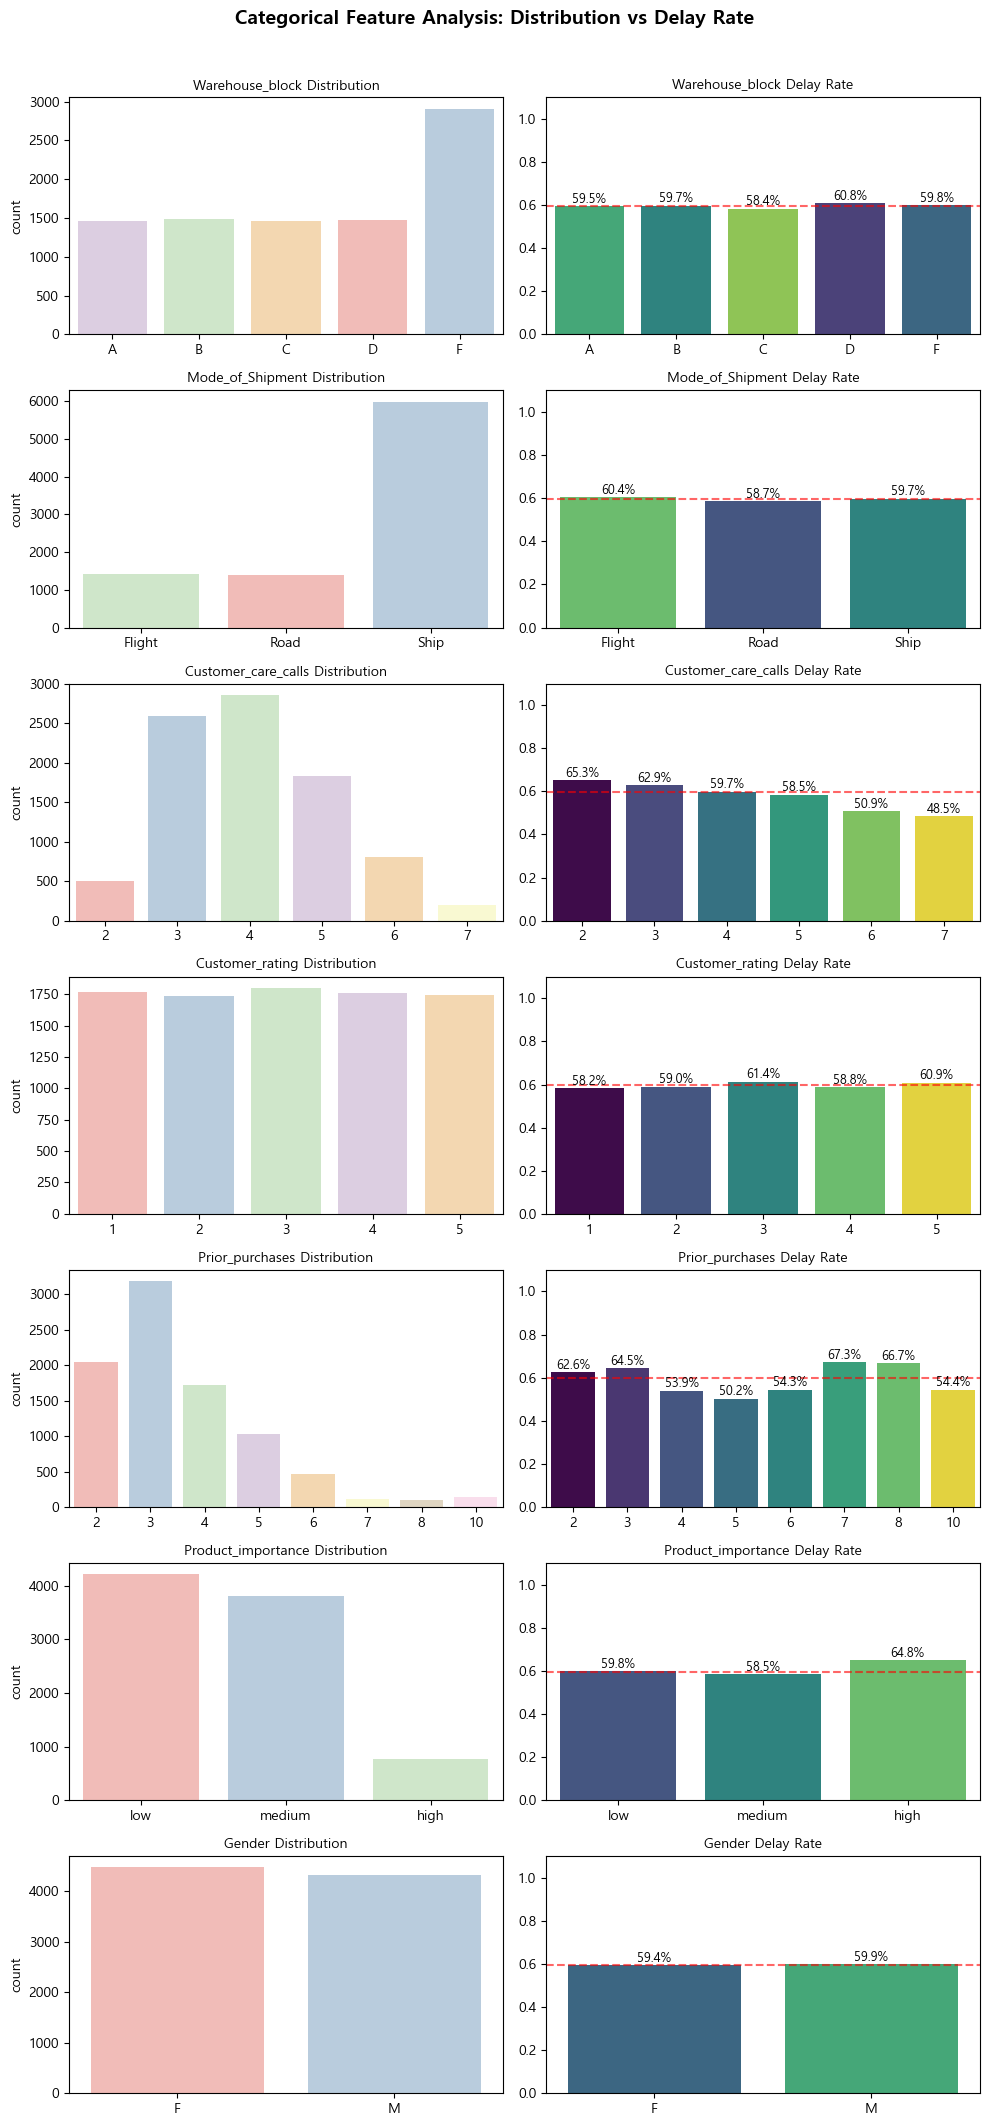

In [19]:
plot_categorical_analysis(train_df, cat_cols, target)

* Warehouse_block에서 f의 비중이 큰 것을 발견 <br>
	-> 하지만 지연율 차이 미미
* Mode_of_Shipment은 Ship에 집중 <br>
	 ->하지만 지연율 차이 미미
* Customer_care_calls는 2, 6, 7의 데이터 크기가 작음 <br>
	 ->많아질수록 지연율 떨어짐. 6 이후를 하나로 묶을 필요성
* Customer_rating은 분포가 고르다 <br>
	 ->지연율 차이도 미미
* Prior_purchases는 6 이후의 분포가 적음 <br>
	 ->지연율은 4,5,6에서 감소. 6 이후를 통합
* Product_importance는 High에서 오히려 높은 지연율 <br>
	-> importance의 기준이 무엇인지 확인 필요
* Gender에 따른 지연율의 차이 없음

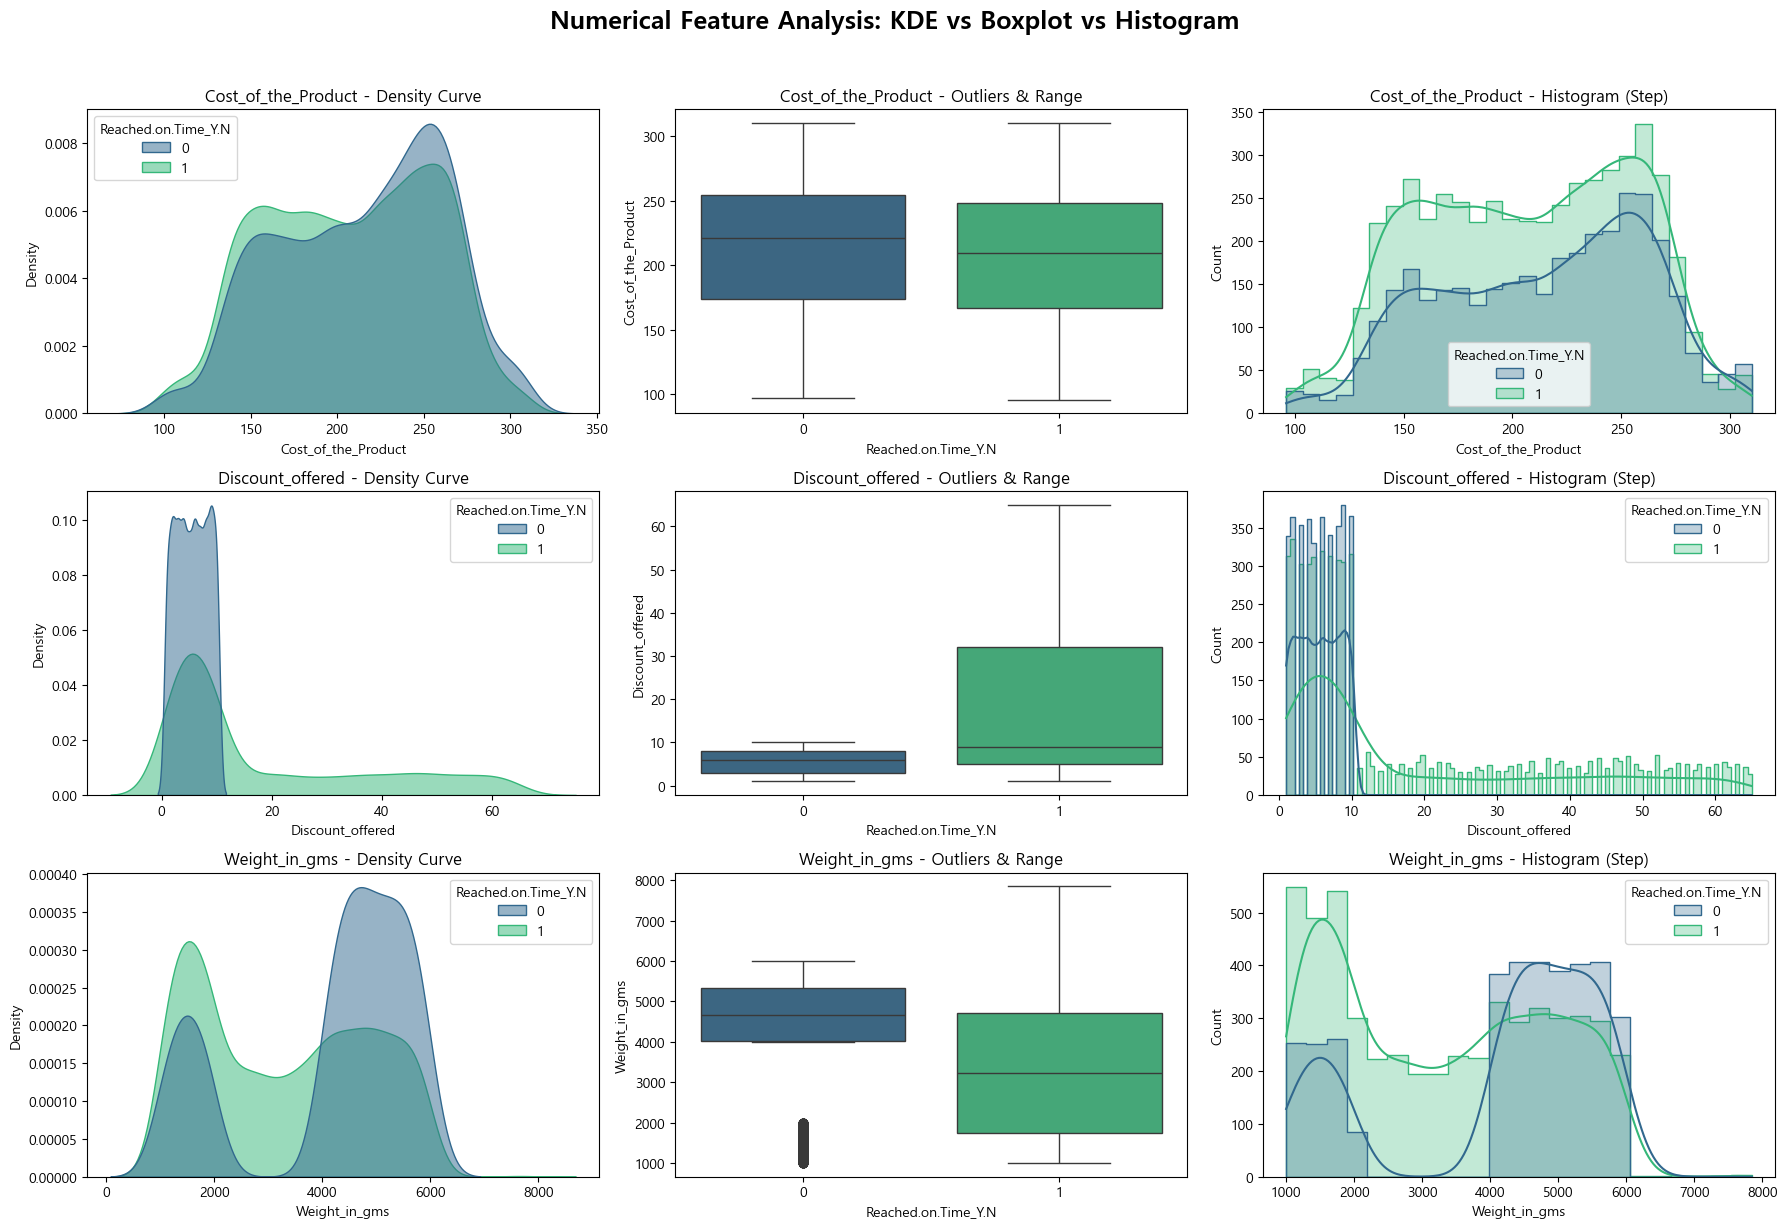

In [20]:
plot_numeric_analysis(train_df, num_cols, target)

* Cost_of_the_product는 큰 영향 없는듯 보인다
    -> 다른 특성과 결합하여 가능한 변수 만들어보기
* Discount_offered는 10 초과는 지연
    -> 10을 기준으로 구분 필요
* Weight_in_gms는 구간에 따른 지연율 차이
    -> 낮은 구간, 중간 구간, 높은 구간의 지연율이 각각 다름

## EDA

1. 특성간 분포 변화를 살펴보고 관계성 추측
    * 하나의 특성에 다른 features는 어떤 분포를 하는지 시각적으로 확인할 수 있는 함수 생성
    * 이상치 여부를 판단하는 로직을 넣어 효율적으로 데이터 탐색
2. 새로운 파생변수 생성 및 지연율에 대한 영향력 확인

### 특성간 비교 함수 정의

In [21]:
# 범주형 특성과의 관계 분석 함수

def summarize_categorical_with_plots(df, group_col, target_features, threshold=5.0):
    """
    각 창고별 비율과 전체 비율(Overall)을 비교하여 
    차이가 threshold(%p) 이상인 경우에만 표를 출력합니다.
    """
    filtered_features = [col for col in target_features if col != group_col]
    
    for col in filtered_features:
        # 1. 그룹별 빈도 및 비율 계산
        count_table = pd.crosstab(df[group_col], df[col])
        percent_table = pd.crosstab(df[group_col], df[col], normalize='index') * 100
        
        # 2. 전체 데이터(Overall) 비율 및 빈도 계산
        overall_counts = df[col].value_counts().reindex(count_table.columns)
        overall_percents = (df[col].value_counts(normalize=True) * 100).reindex(count_table.columns)
        
        # 3. 이상치 여부 판단 (어떤 그룹이라도 전체 평균과 threshold 이상 차이가 나는가?)
        is_outlier = False
        for category in overall_percents.index:
            diff = (percent_table[category] - overall_percents[category]).abs()
            if diff.max() >= threshold:
                is_outlier = True
                break
        
        # 4. 결과 출력
        if is_outlier:
            print(f"\n[🚨 이상치 발견] '{col}' 특성은 {group_col}별로 유의미한 차이가 있습니다.")
            
            # 5. 빈도와 비율을 합친 요약 테이블 생성
            summary_table = count_table.copy().astype(str)
            for row in count_table.index:
                for c in count_table.columns:
                    summary_table.loc[row, c] = f"{count_table.loc[row, c]} ({percent_table.loc[row, c]:.1f}%)"
            
            # 6. Overall(전체 평균) 행 추가
            overall_row = []
            for c in count_table.columns:
                overall_row.append(f"{overall_counts[c]} ({overall_percents[c]:.1f}%)")
            
            summary_table.loc['Overall'] = overall_row
            
            display(summary_table)


            # --- [시각화 데이터 준비] ---
            # 표와 동일한 구조를 위해 Overall을 포함한 Wide format 생성
            plot_df_wide = percent_table.copy()
            plot_df_wide.loc['Overall'] = overall_percents
            
            # 그래프용 Long format 변환
            plot_df_long = plot_df_wide.reset_index().melt(id_vars=group_col, var_name=col, value_name='Percentage')

            # --- [그래프 그리기] ---
            plt.figure(figsize=(10, 5))
            
            # 범례 순서를 표의 컬럼 순서와 동일하게 고정
            category_order = list(count_table.columns)
            
            ax = sns.barplot(
                data=plot_df_long, y=group_col, x='Percentage', hue=col, hue_order=category_order, palette='viridis' )
            
            # 막대 옆에 % 수치 표시
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f' {width:.1f}%', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=9, fontweight='bold', xytext=(3, 0), textcoords='offset points')

            plt.title(f'Distribution of {col} by {group_col}', fontsize=14, pad=20)
            plt.xlabel('Percentage (%)')
            plt.ylabel(group_col)
            plt.xlim(0, plot_df_long['Percentage'].max() * 1.2) # 수치 표시 공간 확보
            plt.legend(title=col, bbox_to_anchor=(1.02, 1), loc='upper left')
            plt.grid(axis='x', linestyle='--', alpha=0.3)
            plt.tight_layout()
            plt.show()

            
        else:
            print(f"[✅ 이상치 없음] '{col}': 모든 {group_col}에서 고른 분포를 보입니다.")

In [22]:
# 수치형 특성과의 관계 분석 함수

def summarize_numeric_with_plots(df, group_col, target_features, threshold=0.1):
    """
    수치형 특성의 그룹별 통계량과 전체 분포를 비교 시각화합니다.
    """
    for col in target_features:
        if col == group_col: continue
        
        # 1. 통계량 계산
        group_stats = df.groupby(group_col, observed=True)[col].describe()
        overall_stats = df[col].describe()
        
        # 2. 이상치 판단 (그룹 평균이 전체 평균과 threshold 이상 차이 나는지)
        mean_diff = (group_stats['mean'] - overall_stats['mean']).abs() / overall_stats['mean']
        
        if mean_diff.max() >= threshold:
            print(f"\n[🚨 차이 발견] '{col}' 특성은 {group_col}별로 평균 차이가 있습니다.")
            display(group_stats)

            # --- [시각화 시작] ---
            plt.figure(figsize=(12, 6))
            
            # (1) Box Plot 그리기
            ax = sns.boxplot(data=df, x=group_col, y=col, hue=group_col, palette='viridis', legend=False, showmeans=True,
                             meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
            
            # (2) 전체 평균(Overall Mean) 수평선 추가
            plt.axhline(overall_stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_stats["mean"]:.2f}')
            
            # (3) 각 그룹별 평균값을 텍스트로 표시
            means = df.groupby(group_col, observed=True)[col].mean()
            for i, mean in enumerate(means):
                ax.annotate(f'{mean:.2f}', xy=(i, mean), xytext=(0, 10),
                            textcoords='offset points', ha='center', fontsize=10, fontweight='bold', color='blue')

            plt.title(f'Comparison: {col} Distribution by {group_col}', fontsize=15)
            plt.legend(loc='upper right')
            plt.grid(axis='y', linestyle=':', alpha=0.7)
            plt.show()
        else:
            print(f"[✅ 통과] '{col}': 그룹별 평균 차이가 미미합니다.")

In [23]:
print(cat_cols)
print(num_cols)

['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']
['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']


In [24]:
# 데이터의 분포가 너무 적어 비교가 어려운 부분은 범주를 합친다.
train_df['Prior_purchases'] = train_df['Prior_purchases'].clip(upper=6)
train_df['Customer_care_calls'] = train_df['Customer_care_calls'].clip(lower=3, upper=6)

### 특성 간 분포 단순 비교

In [25]:
summarize_categorical_with_plots(train_df, 'Warehouse_block', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Warehouse_block에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Warehouse_block에서 고른 분포를 보입니다.


In [26]:
summarize_numeric_with_plots(train_df, 'Warehouse_block', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


In [27]:
summarize_categorical_with_plots(train_df, 'Mode_of_Shipment', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.


[✅ 이상치 없음] 'Customer_care_calls': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Mode_of_Shipment에서 고른 분포를 보입니다.


In [28]:
summarize_numeric_with_plots(train_df, 'Mode_of_Shipment', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


[✅ 이상치 없음] 'Warehouse_block': 모든 Customer_care_calls에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Customer_care_calls에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Customer_care_calls에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Prior_purchases' 특성은 Customer_care_calls별로 유의미한 차이가 있습니다.


Prior_purchases,2,3,4,5,6
Customer_care_calls,,,,,
3,910 (29.4%),1370 (44.2%),424 (13.7%),132 (4.3%),264 (8.5%)
4,731 (25.6%),1184 (41.4%),351 (12.3%),323 (11.3%),270 (9.4%)
5,366 (19.9%),548 (29.8%),279 (15.2%),425 (23.1%),220 (12.0%)
6,35 (3.5%),80 (8.0%),669 (66.8%),147 (14.7%),71 (7.1%)
Overall,2042 (23.2%),3182 (36.2%),1723 (19.6%),1027 (11.7%),825 (9.4%)


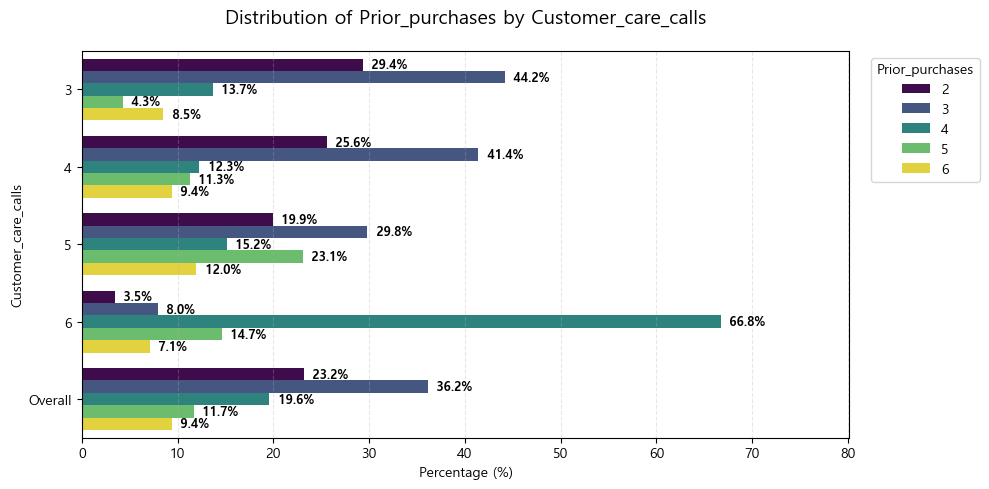


[🚨 이상치 발견] 'Product_importance' 특성은 Customer_care_calls별로 유의미한 차이가 있습니다.


Product_importance,low,medium,high
Customer_care_calls,,,
3,1395 (45.0%),1371 (44.2%),334 (10.8%)
4,1370 (47.9%),1264 (44.2%),225 (7.9%)
5,892 (48.5%),790 (43.0%),156 (8.5%)
6,557 (55.6%),392 (39.1%),53 (5.3%)
Overall,4214 (47.9%),3817 (43.4%),768 (8.7%)


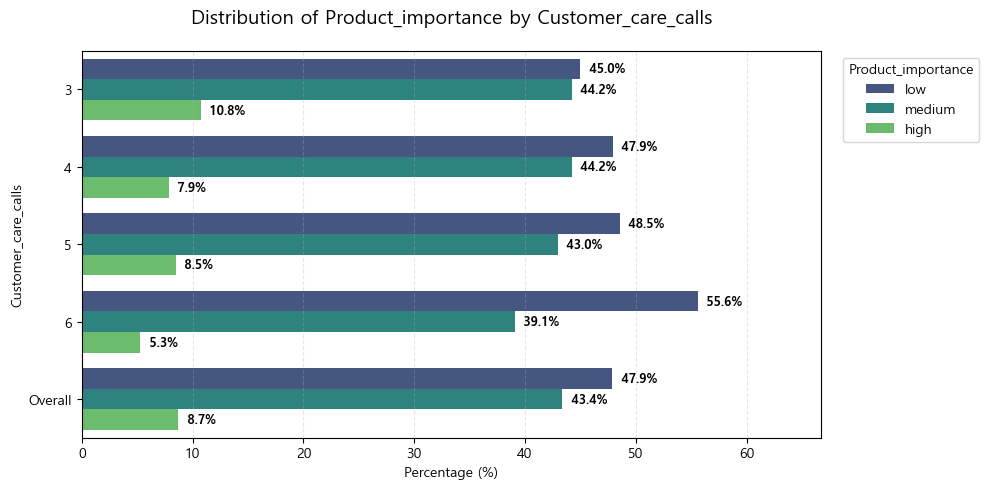

[✅ 이상치 없음] 'Gender': 모든 Customer_care_calls에서 고른 분포를 보입니다.


In [29]:
summarize_categorical_with_plots(train_df, 'Customer_care_calls', cat_cols, threshold=5.0)


[🚨 차이 발견] 'Cost_of_the_Product' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,198.072581,45.021721,96.0,160.00,197.0,237.0,310.0
4,2859.0,205.861840,44.537105,96.0,168.00,209.0,245.0,301.0
5,1838.0,214.638738,44.470881,97.0,179.00,225.0,251.0,307.0
6,1002.0,252.222555,49.119107,98.0,242.25,265.0,286.0,310.0


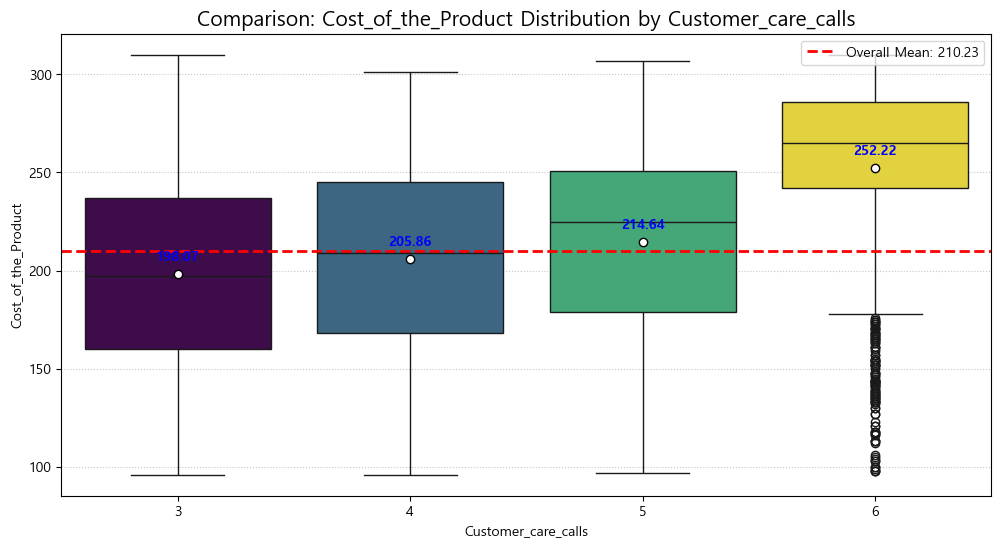


[🚨 차이 발견] 'Discount_offered' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,15.415484,17.528522,1.0,4.0,8.0,19.0,65.0
4,2859.0,13.380553,16.102605,1.0,4.0,7.0,11.0,65.0
5,1838.0,12.633841,15.638064,1.0,4.0,7.0,10.0,65.0
6,1002.0,8.335329,10.579575,1.0,3.0,6.0,9.0,65.0


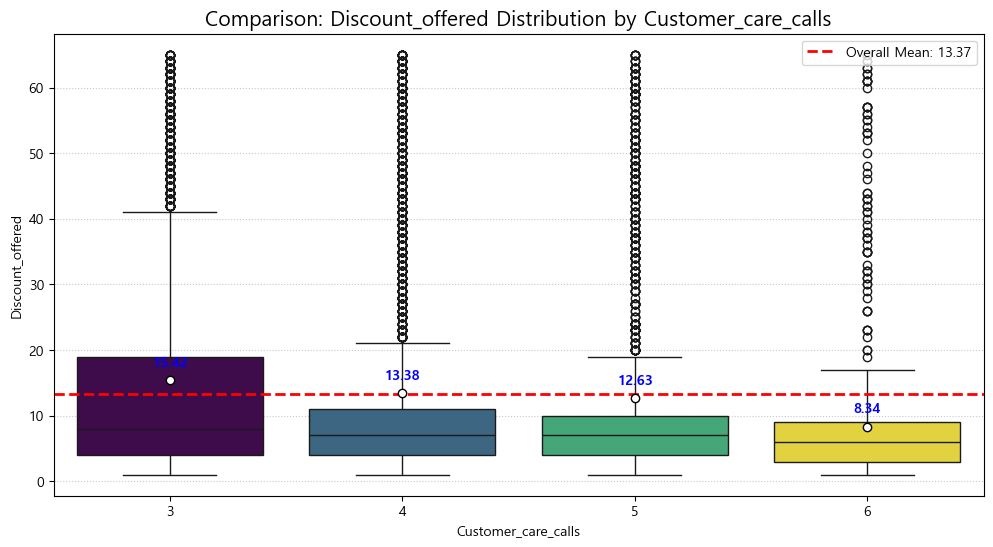


[🚨 차이 발견] 'Weight_in_gms' 특성은 Customer_care_calls별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Customer_care_calls,,,,,,,,
3,3100.0,3969.918387,1498.540805,1004.0,2727.00,4372.5,5184.25,7846.0
4,2859.0,3844.457503,1568.115869,1001.0,2270.50,4331.0,5148.50,6000.0
5,1838.0,3468.522307,1653.171112,1001.0,1730.50,3917.0,4946.00,6000.0
6,1002.0,2273.432136,1450.641967,1003.0,1303.25,1660.0,2334.00,5992.0


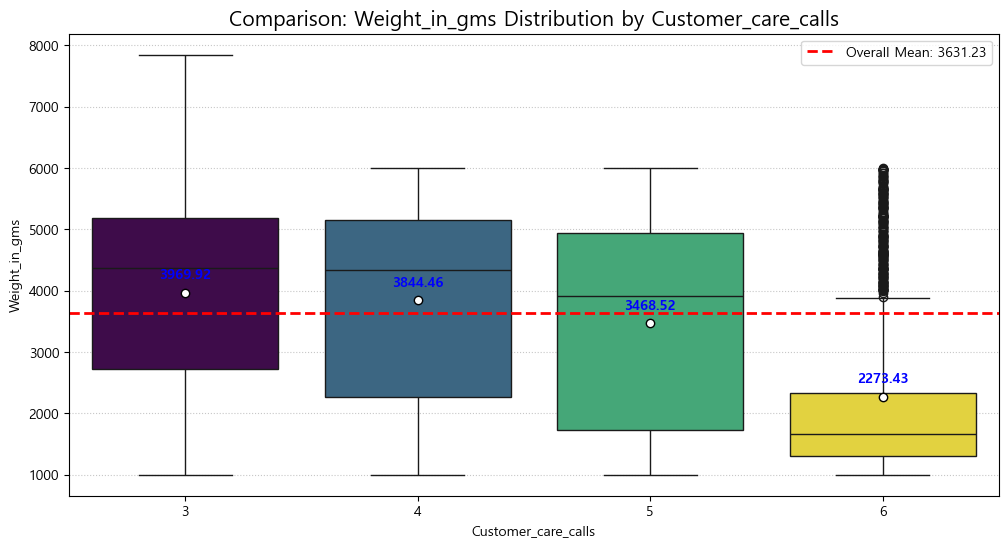

In [30]:
summarize_numeric_with_plots(train_df, 'Customer_care_calls', num_cols, threshold=0.1)

In [31]:
summarize_categorical_with_plots(train_df, 'Customer_rating', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Customer_rating에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Gender': 모든 Customer_rating에서 고른 분포를 보입니다.


In [32]:
summarize_numeric_with_plots(train_df, 'Customer_rating', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


[✅ 이상치 없음] 'Warehouse_block': 모든 Prior_purchases에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Prior_purchases에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Customer_care_calls' 특성은 Prior_purchases별로 유의미한 차이가 있습니다.


Customer_care_calls,3,4,5,6
Prior_purchases,,,,
2,910 (44.6%),731 (35.8%),366 (17.9%),35 (1.7%)
3,1370 (43.1%),1184 (37.2%),548 (17.2%),80 (2.5%)
4,424 (24.6%),351 (20.4%),279 (16.2%),669 (38.8%)
5,132 (12.9%),323 (31.5%),425 (41.4%),147 (14.3%)
6,264 (32.0%),270 (32.7%),220 (26.7%),71 (8.6%)
Overall,3100 (35.2%),2859 (32.5%),1838 (20.9%),1002 (11.4%)


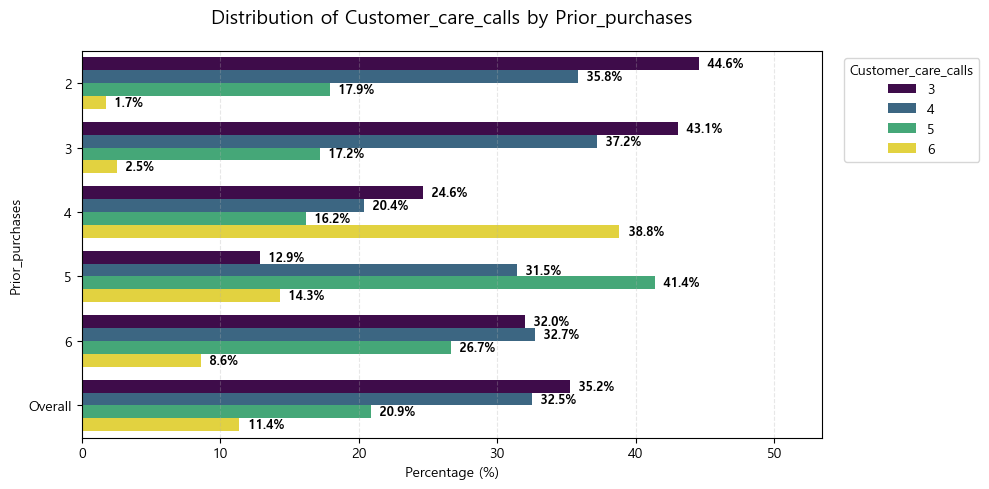

[✅ 이상치 없음] 'Customer_rating': 모든 Prior_purchases에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Product_importance' 특성은 Prior_purchases별로 유의미한 차이가 있습니다.


Product_importance,low,medium,high
Prior_purchases,,,
2,949 (46.5%),894 (43.8%),199 (9.7%)
3,1486 (46.7%),1387 (43.6%),309 (9.7%)
4,887 (51.5%),723 (42.0%),113 (6.6%)
5,574 (55.9%),411 (40.0%),42 (4.1%)
6,318 (38.5%),402 (48.7%),105 (12.7%)
Overall,4214 (47.9%),3817 (43.4%),768 (8.7%)


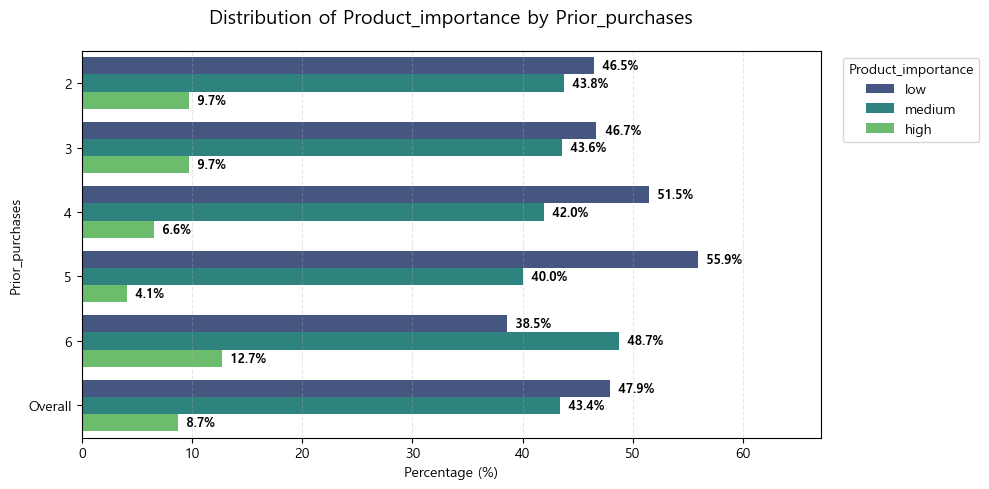

[✅ 이상치 없음] 'Gender': 모든 Prior_purchases에서 고른 분포를 보입니다.


In [33]:
summarize_categorical_with_plots(train_df, 'Prior_purchases', cat_cols, threshold=5.0)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.

[🚨 차이 발견] 'Discount_offered' 특성은 Prior_purchases별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Prior_purchases,,,,,,,,
2,2042.0,15.292360,17.313979,1.0,4.0,8.0,20.0,65.0
3,3182.0,15.174104,17.422930,1.0,4.0,7.0,19.0,65.0
4,1723.0,10.647127,13.727382,1.0,3.0,7.0,10.0,65.0
5,1027.0,9.397274,12.121377,1.0,3.0,6.0,9.0,65.0
6,825.0,12.253333,15.314346,1.0,4.0,7.0,10.0,65.0


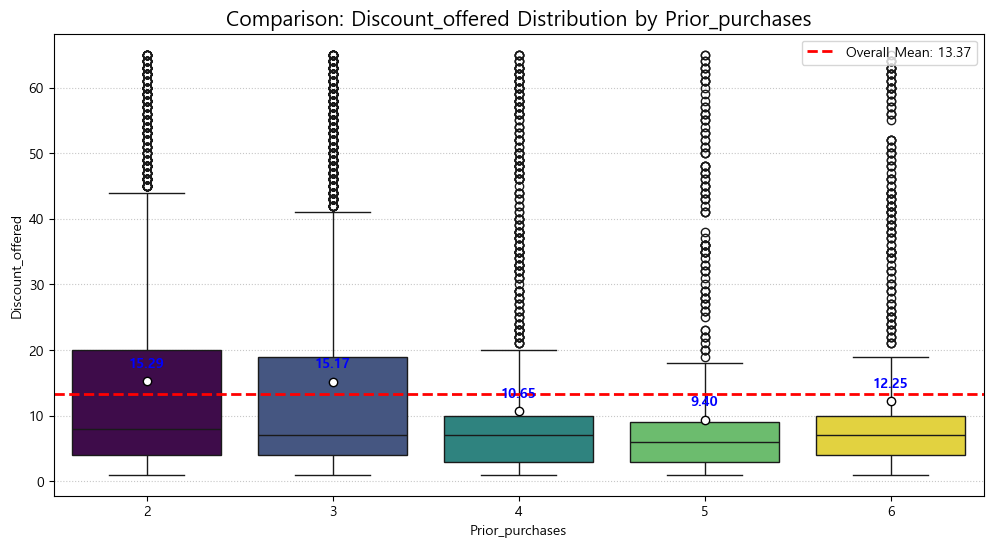


[🚨 차이 발견] 'Weight_in_gms' 특성은 Prior_purchases별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Prior_purchases,,,,,,,,
2,2042.0,4011.672870,1451.756663,1001.0,2858.50,4374.5,5190.00,6000.0
3,3182.0,4035.417976,1474.620793,1005.0,2866.25,4427.5,5213.75,7846.0
4,1723.0,3122.888566,1702.390639,1003.0,1535.50,2583.0,4781.00,5989.0
5,1027.0,2462.910419,1544.628663,1001.0,1357.50,1736.0,4056.50,5993.0
6,825.0,3646.656970,1624.899209,1003.0,1861.00,4179.0,5035.00,5995.0


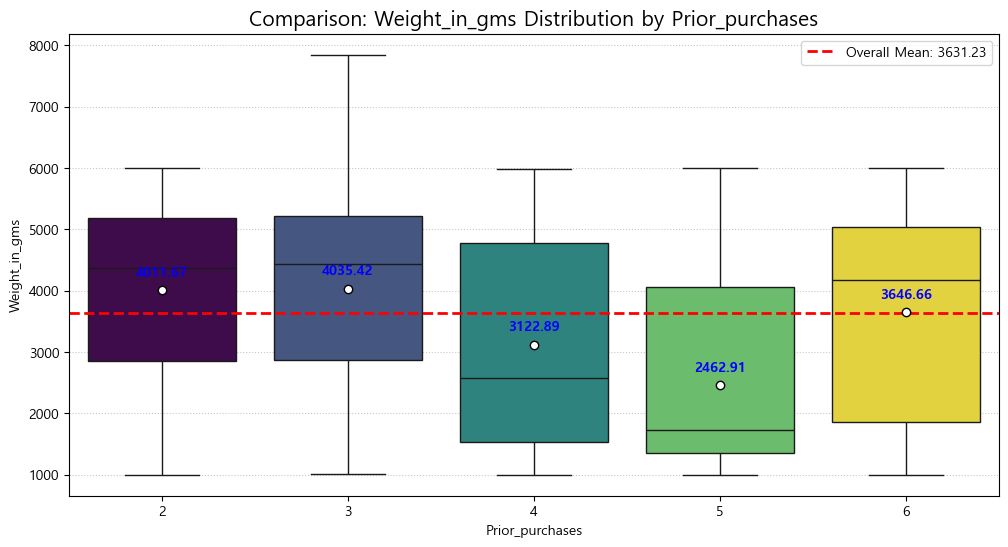

In [34]:
summarize_numeric_with_plots(train_df, 'Prior_purchases', num_cols, threshold=0.1)

[✅ 이상치 없음] 'Warehouse_block': 모든 Product_importance에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Product_importance에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Customer_care_calls' 특성은 Product_importance별로 유의미한 차이가 있습니다.


Customer_care_calls,3,4,5,6
Product_importance,,,,
low,1395 (33.1%),1370 (32.5%),892 (21.2%),557 (13.2%)
medium,1371 (35.9%),1264 (33.1%),790 (20.7%),392 (10.3%)
high,334 (43.5%),225 (29.3%),156 (20.3%),53 (6.9%)
Overall,3100 (35.2%),2859 (32.5%),1838 (20.9%),1002 (11.4%)


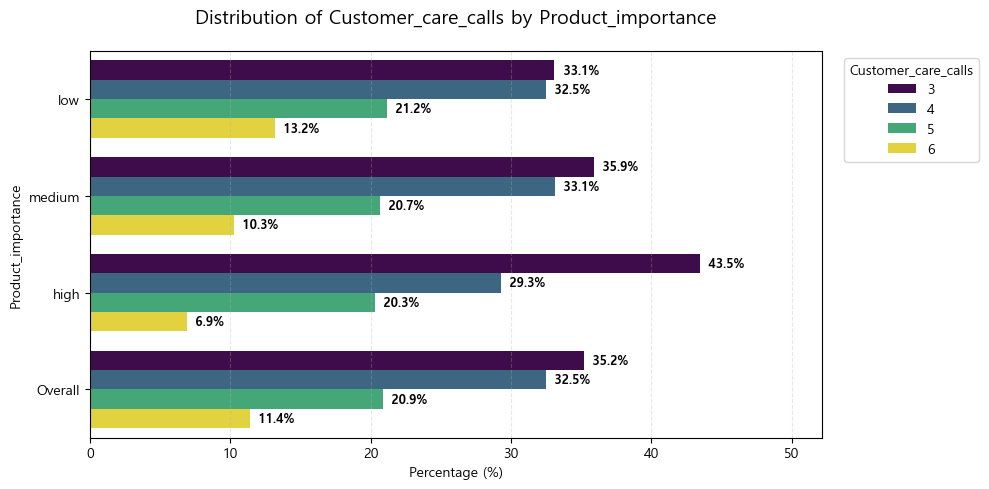

[✅ 이상치 없음] 'Customer_rating': 모든 Product_importance에서 고른 분포를 보입니다.

[🚨 이상치 발견] 'Prior_purchases' 특성은 Product_importance별로 유의미한 차이가 있습니다.


Prior_purchases,2,3,4,5,6
Product_importance,,,,,
low,949 (22.5%),1486 (35.3%),887 (21.0%),574 (13.6%),318 (7.5%)
medium,894 (23.4%),1387 (36.3%),723 (18.9%),411 (10.8%),402 (10.5%)
high,199 (25.9%),309 (40.2%),113 (14.7%),42 (5.5%),105 (13.7%)
Overall,2042 (23.2%),3182 (36.2%),1723 (19.6%),1027 (11.7%),825 (9.4%)


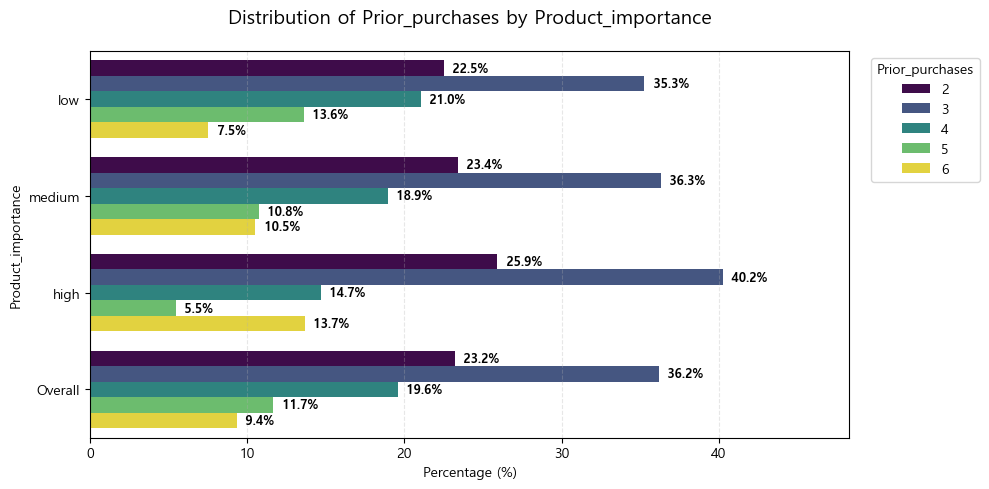

[✅ 이상치 없음] 'Gender': 모든 Product_importance에서 고른 분포를 보입니다.


In [35]:
summarize_categorical_with_plots(train_df, 'Product_importance', cat_cols, threshold=5.0)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.

[🚨 차이 발견] 'Weight_in_gms' 특성은 Product_importance별로 평균 차이가 있습니다.


,count,mean,std,min,25%,50%,75%,max
Product_importance,,,,,,,,
low,4214.0,3474.928334,1669.890264,1001.0,1714.00,3996.0,4986.75,5999.0
medium,3817.0,3727.875033,1605.159900,1001.0,1936.00,4212.0,5082.00,7846.0
high,768.0,4008.498698,1474.420311,1007.0,2868.25,4402.0,5195.50,6000.0


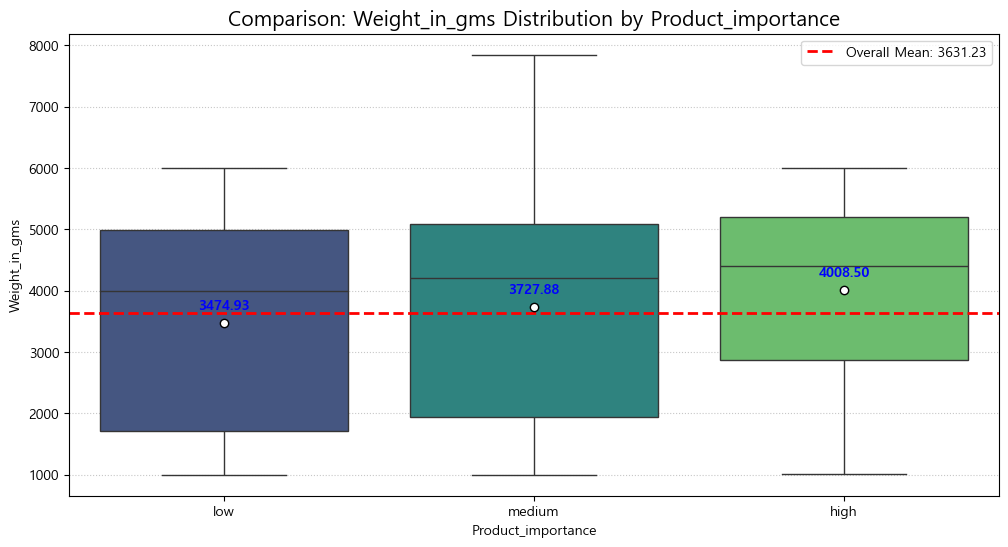

In [36]:
summarize_numeric_with_plots(train_df, 'Product_importance', num_cols, threshold=0.1)

In [37]:
summarize_categorical_with_plots(train_df, 'Gender', cat_cols, threshold=5.0)

[✅ 이상치 없음] 'Warehouse_block': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Mode_of_Shipment': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_care_calls': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Customer_rating': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Prior_purchases': 모든 Gender에서 고른 분포를 보입니다.
[✅ 이상치 없음] 'Product_importance': 모든 Gender에서 고른 분포를 보입니다.


In [38]:
summarize_numeric_with_plots(train_df, 'Gender', num_cols, threshold=0.1)

[✅ 통과] 'Cost_of_the_Product': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Discount_offered': 그룹별 평균 차이가 미미합니다.
[✅ 통과] 'Weight_in_gms': 그룹별 평균 차이가 미미합니다.


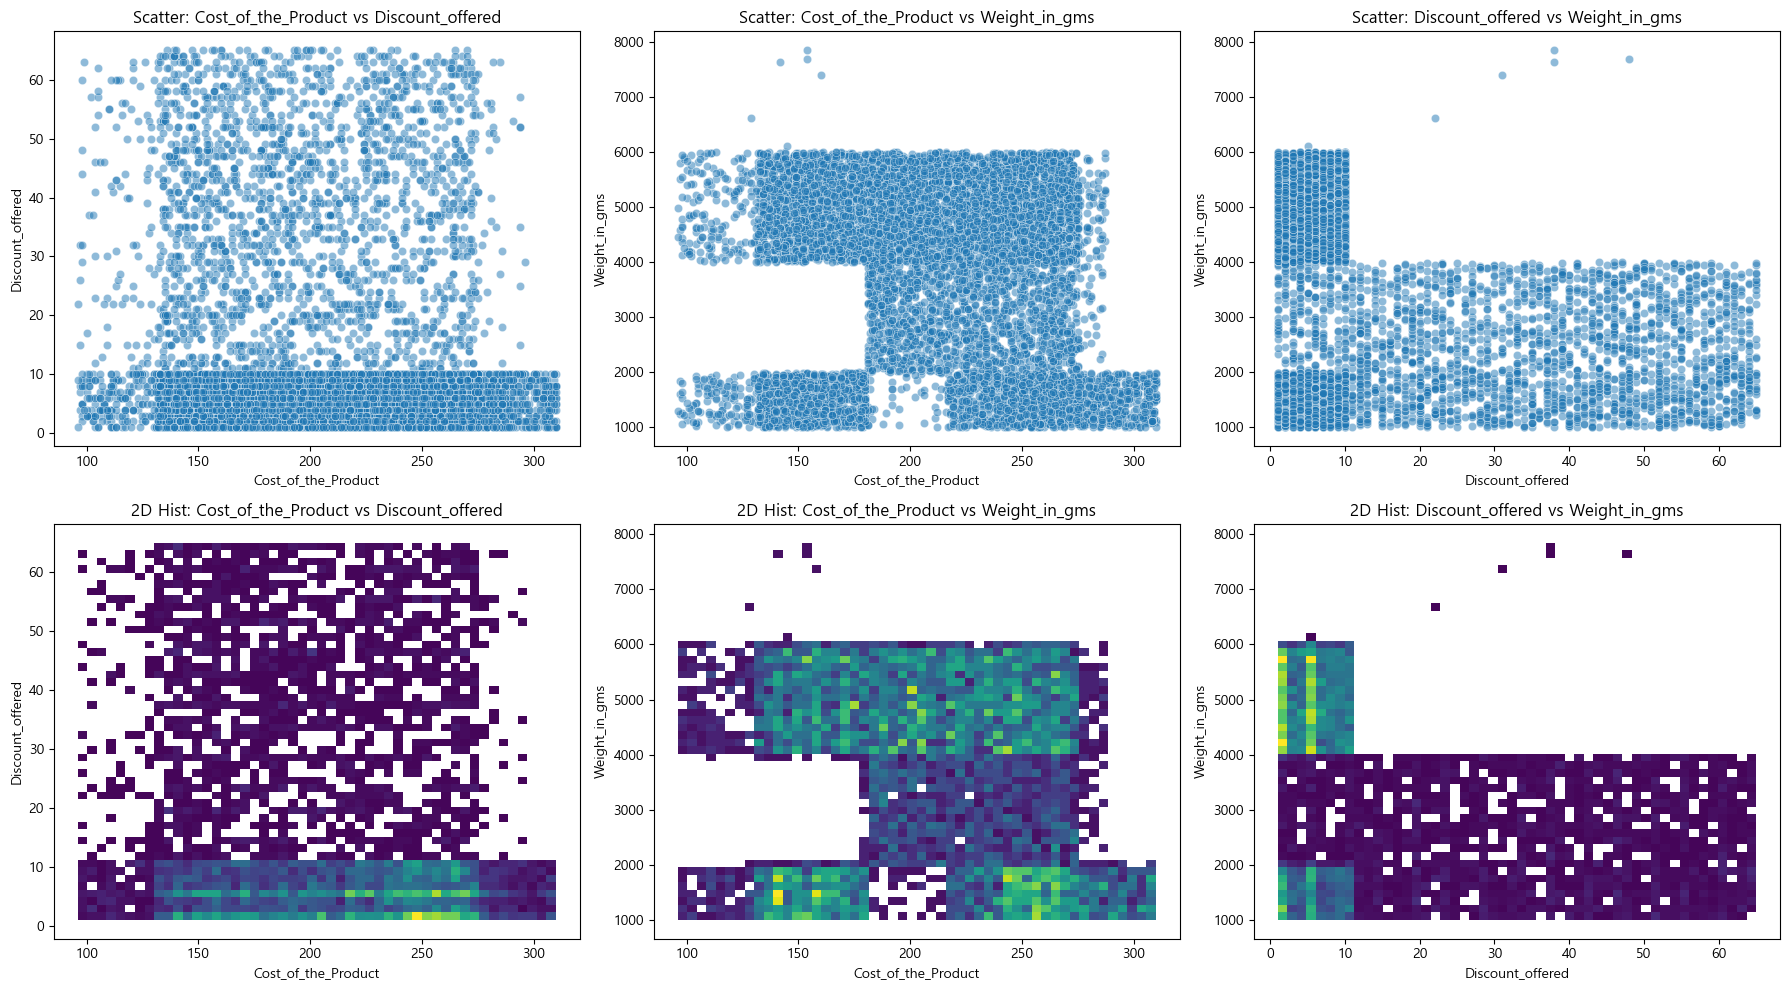

In [39]:
# 2행 3열의 레이아웃 설정
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- 첫 번째 열: 가격(Price) vs 할인액(Discount) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[0], y=num_cols[1], ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title(f'Scatter: {num_cols[0]} vs {num_cols[1]}')

# 2행: 2D Histplot
sns.histplot(data=train_df, x=num_cols[0], y=num_cols[1], ax=axes[1, 0], bins=50, cmap='viridis', cbar=False)
axes[1, 0].set_title(f'2D Hist: {num_cols[0]} vs {num_cols[1]}')

# --- 두 번째 열: 가격(Price) vs 무게(Weight) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[0], y=num_cols[2], ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title(f'Scatter: {num_cols[0]} vs {num_cols[2]}')

# 2행: 2D Histplot 
sns.histplot(data=train_df, x=num_cols[0], y=num_cols[2], ax=axes[1, 1], bins=50, cmap='viridis', cbar=False)
axes[1, 1].set_title(f'2D Hist: {num_cols[0]} vs {num_cols[2]}')

# --- 세 번째 열: 할인액(Discount) vs 무게(Weight) ---
# 1행: 산점도
sns.scatterplot(data=train_df, x=num_cols[1], y=num_cols[2], ax=axes[0, 2], alpha=0.5)
axes[0, 2].set_title(f'Scatter: {num_cols[1]} vs {num_cols[2]}')

# 2행: 2D Histplot
sns.histplot(data=train_df, x=num_cols[1], y=num_cols[2], ax=axes[1, 2], bins=50, cmap='viridis', cbar=False)
axes[1, 2].set_title(f'2D Hist: {num_cols[1]} vs {num_cols[2]}')

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

## 데이터 비교분석 결과 해석

### 1. Warehouse_block
* A, B, C, D, F 총 5개동
* F동을 제외하고 균일한 비중. F동은 타 동의 2배
* 각 동에 따른 다른 특성의 분포 차이 없음 - 무게, 가격, 운송 수단에 따른 영향이 없다
* 하나의 큰 창고에서 운송일 등 현재 데이터에 없는 기준으로 각 동에 분류하는 것으로 추정


In [40]:
train_df['Warehouse_block'].value_counts()

Warehouse_block
F    2910
B    1487
D    1470
A    1468
C    1464
Name: count, dtype: int64

### 2. Mode_of_Shipment
* Ship, Flight, Road 세 개의 운송 수단
* Ship의 비중이 압도적
* 운송수단에 따른 다른 특성의 분포 차이 없음
    -> 실제로는 가격/무게/부피에 따라 운송수단이 선택되는것을 고려한다면 이상한 데이터.

In [41]:
train_df['Mode_of_Shipment'].value_counts()

Mode_of_Shipment
Ship      5981
Flight    1420
Road      1398
Name: count, dtype: int64

운송 수단과 창고의 영향력을 확인하기 위해 두 변수를 합친다

In [42]:
copy_df = train_df.copy()
copy_df['Wh_Shipment_Combo'] = copy_df['Warehouse_block'].astype(str) + '_' + copy_df['Mode_of_Shipment'].astype(str)
copy_df['Wh_Shipment_Combo'].unique()

array(['D_Road', 'F_Ship', 'B_Ship', 'D_Ship', 'A_Flight', 'B_Road',
       'C_Ship', 'F_Road', 'A_Ship', 'F_Flight', 'D_Flight', 'C_Flight',
       'A_Road', 'B_Flight', 'C_Road'], dtype=object)

--- 조합별 지연율 (상위 10개) ---
                   Delay_Rate
Wh_Shipment_Combo            
D_Flight             0.628205
A_Road               0.619247
F_Flight             0.611111
D_Ship               0.608609
C_Flight             0.607595
B_Flight             0.602510
B_Ship               0.600198
F_Ship               0.596192
A_Ship               0.595745
F_Road               0.594170


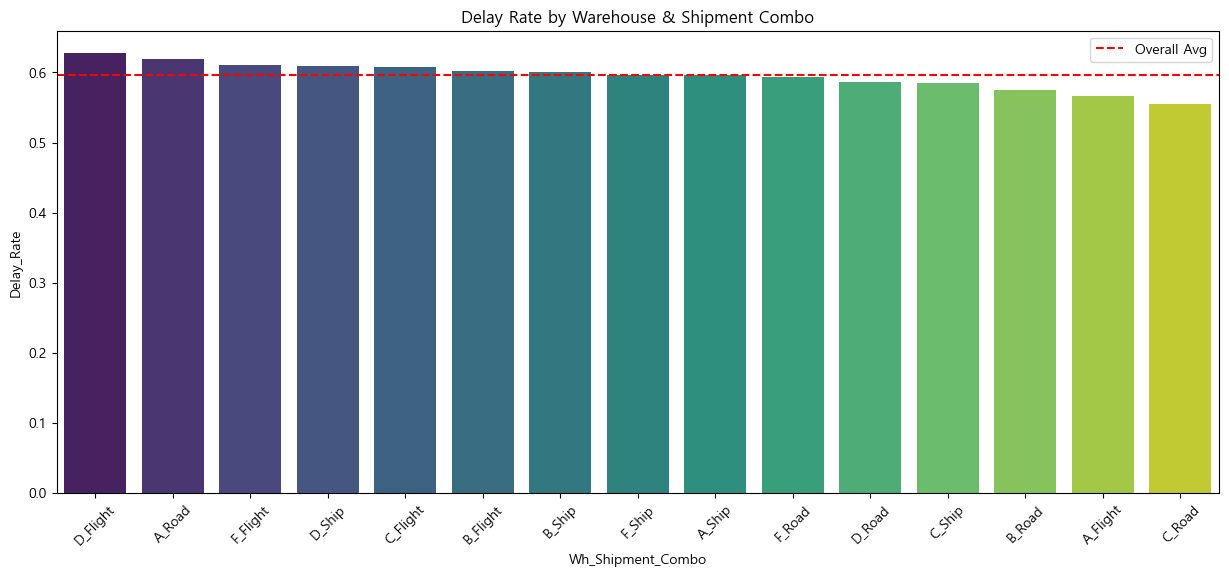

In [43]:
# 조합별 지연율 평균 계산 및 정렬
combo_delay_rate = copy_df.groupby('Wh_Shipment_Combo')[target].mean().sort_values(ascending=False).to_frame()
combo_delay_rate.columns = ['Delay_Rate']

print("--- 조합별 지연율 (상위 10개) ---")
print(combo_delay_rate.head(10))

# 시각화
plt.figure(figsize=(15, 6))
sns.barplot(data=combo_delay_rate.reset_index(), x='Wh_Shipment_Combo', y='Delay_Rate', hue= 'Wh_Shipment_Combo', palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.title('Delay Rate by Warehouse & Shipment Combo')
plt.axhline(copy_df[target].mean(), color='red', linestyle='--', label='Overall Avg') # 전체 평균선
plt.legend()
plt.show()

미세하지만 항목별로 차이가 존재하는것을 확인

### 3. Prior_purchases
* 2, 3, 4, 5, 6+ 의 구매횟수. 5개 종류
* 지연율은 중간지점은 4, 5에서 점점 낮아지다 6이후에서 다시 증가하는 형태
* 'Prior_purchases'의 분포 확인 결과 4 이후에 급격한 하락.
    -> 잦은 지연에 고객들의 이탈이 발생했을 가능성


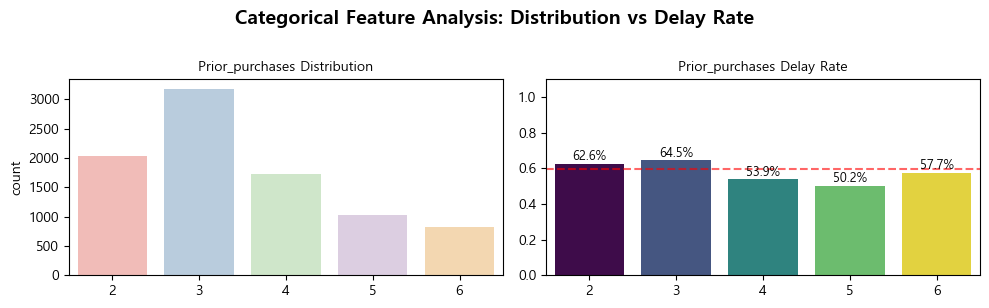

In [44]:
# 6이상의 구매횟수 통합한 버전의 시각화
plot_categorical_analysis(train_df, ['Prior_purchases'], target)

#### 다른 특성과의 관계
##### 'Prior_purchases'와 'Product_importance'
* 구매횟수 2~5: 낮은 중요도의 비중이 상승
* 구매횟수 6: 높은 중요도와 중간 중요도의 비중 급격한 상승
* 가설1: 단골고객(구매횟수>5)에게 중요도가 높은 상품을 구매할 요인이 있나?

가설 1

In [45]:
copy_df['is_loyal'] = (copy_df['Prior_purchases'] > 5).astype(int)
copy_df['is_loyal'].value_counts()

# 분석을 위해 copy_df의 'Product_importance'을 레이블링
importance_map = {'low': 0, 'medium': 1, 'high': 2}
copy_df['Product_importance'] = copy_df['Product_importance'].map(importance_map).astype(int)

# 분석을 위해 추가로 '할인율' 생성
copy_df['Discount_rate'] = (copy_df['Discount_offered'] / copy_df['Cost_of_the_Product'])*100

In [46]:
copy_df.groupby('is_loyal')[['Product_importance', 'Cost_of_the_Product', 'Discount_offered','Discount_rate', target]].agg(['mean', 'median'])

Product_importance        Cost_of_the_Product         \
                       mean median                mean median   
is_loyal                                                        
0                  0.594557    1.0          210.135691  213.0   
1                  0.741818    1.0          211.145455  221.0   

         Discount_offered        Discount_rate           Reached.on.Time_Y.N  \
                     mean median          mean    median                mean   
is_loyal                                                                       
0               13.482192    7.0      7.074021  3.333333            0.598696   
1               12.253333    7.0      6.439064  3.355705            0.576970   

                 
         median  
is_loyal         
0           1.0  
1           1.0

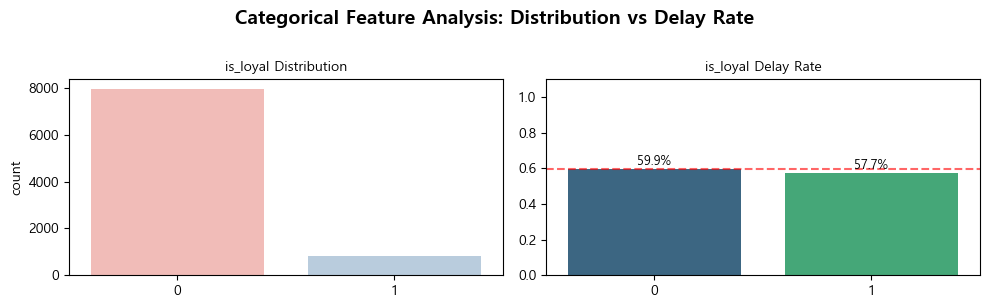

In [47]:
plot_categorical_analysis(copy_df,['is_loyal'], target)

결론
* 'is_loyal'에게 제공되는 유인사항 없음.
* 가격 혜택(할인율) 또는 배송 우대와 같은 혜택이 없음을 확인.
* 지연율에 약 2%의 차이만을 발견 -> 모델학습에 도움을 주지 않을 것으로 판단.

### 4. Customer_rating
* 1, 2, 3, 4, 5 총 5개 등급
* 등급 간 균일한 비중과 지연율을 보임(최대 3.2%의 차이).
* 지연율과의 경향성, 상관관계 없음
* 각 등급에 따른 다른 특성의 분포 차이 없음
* 현재 데이터에 없는 기준(예를 들어 물품에 대한 만족도)이 적용된 등급으로 추정


### 5. Gender

In [48]:
train_df['Product_importance'].value_counts(normalize=True)

Product_importance
low       0.478918
medium    0.433799
high      0.087283
Name: proportion, dtype: float64

### 6. 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms'
* Discount_offered와 Discount_offered는 구간별 지연율의 변화가 확연한 곳이 존재.
* 더 자세한 분석을 위해 구간을 나눠 수치 분석.
* 생성 가능한 파생변수 목록
    1. 세 데이터의 범주화
    2. 할인율: 1-(discount/cost)
    3. 할인가: cost-discount
    4. 무게당 가격: cost/weight


구간별 시각화 분석

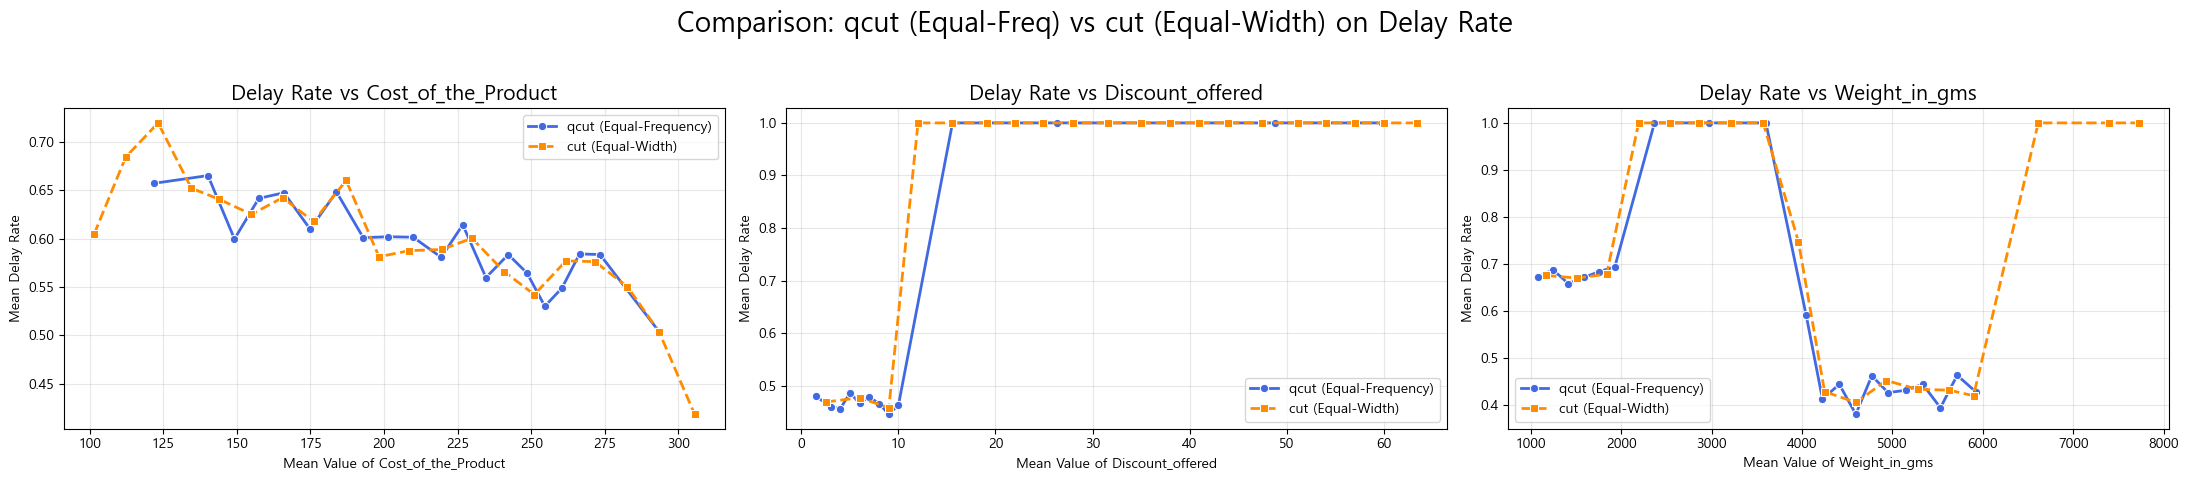

In [49]:
# 1. 분석할 수치형 변수 리스트
features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']

# 2. 서브플롯 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Comparison: qcut (Equal-Freq) vs cut (Equal-Width) on Delay Rate', fontsize=20)

for i, col in enumerate(features):
    temp_df = copy_df.copy()
    
    # --- A. qcut (데이터 개수 균등) 계산 ---
    temp_df['qcut_Bin'] = pd.qcut(temp_df[col], q=20, duplicates='drop')
    qcut_stats = temp_df.groupby('qcut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # --- B. cut (수치 거리 균등) 계산 ---
    temp_df['cut_Bin'] = pd.cut(temp_df[col], bins=20)
    cut_stats = temp_df.groupby('cut_Bin', observed=False).agg({col: 'mean', target: 'mean'}).dropna()
    
    # --- 시각화 ---
    # 1. qcut 라인 (파란색)
    sns.lineplot(x=qcut_stats[col], y=qcut_stats[target], marker='o', 
                 ax=axes[i], label='qcut (Equal-Frequency)', color='royalblue', linewidth=2)
    
    # 2. cut 라인 (주황색)
    sns.lineplot(x=cut_stats[col], y=cut_stats[target], marker='s', 
                 ax=axes[i], label='cut (Equal-Width)', color='darkorange', linewidth=2, linestyle='--')
    
    axes[i].set_title(f'Delay Rate vs {col}', fontsize=15)
    axes[i].set_xlabel(f'Mean Value of {col}')
    axes[i].set_ylabel('Mean Delay Rate')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

* cost: 가격의 증가에 따라 지연율이 감소하는 우하향 그래프. 범주 전환 불필요
* discount: 10을 초과하는 상품은 지연율 100%. 범주를 나누고 10 이하를 상세 분석
* weight: 2000~4000의 지연율 높은구간, 6000 이후의 표본은 몇인지 조사 필요

1. discount

In [50]:
# 할인액 > 10인 구간에서 지연율 
print(copy_df.loc[copy_df['Discount_offered']==10][target].mean())
print(copy_df.loc[copy_df['Discount_offered']>10][target].mean())

0.4632352941176471
1.0


In [51]:
# 할인액 10 이하 구간의 지연율은 비슷하다는 것을 발견.
copy_df.groupby('Discount_offered')[target].mean().head(10)

Discount_offered
1     0.480061
2     0.479256
3     0.460366
4     0.456325
5     0.485981
6     0.467057
7     0.478593
8     0.465857
9     0.445906
10    0.463235
Name: Reached.on.Time_Y.N, dtype: float64

In [52]:
# 'Discount_group' 생성
copy_df['Discount_group'] = (copy_df['Discount_offered'] > 10).astype(int)
copy_df['Discount_group'].value_counts()

Discount_group
0    6673
1    2126
Name: count, dtype: int64

2. weight

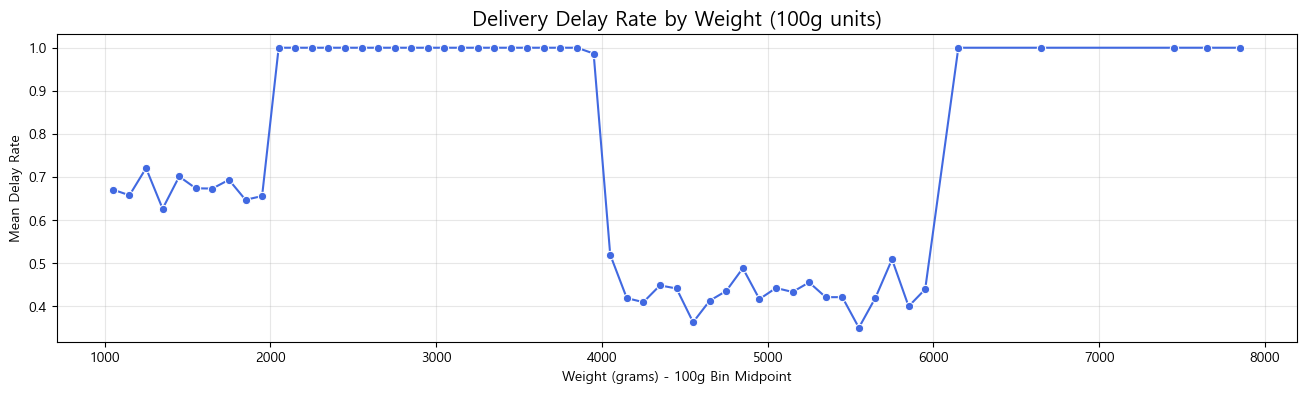

In [53]:
# 세밀한 분석을 위해 100 단위로 나누어 시각화

# 1. 100단위로 구간(bins) 생성
bins_100 = list(range(1000, 8001, 100))
copy_df['Weight_Bin_100'] = pd.cut(copy_df['Weight_in_gms'], bins=bins_100)

# 2. X축에 표시할 값을 구간의 '중간값(mid)'으로 변환 (숫자형으로 시각화하기 위함)
copy_df['Weight_Bin_Mid'] = copy_df['Weight_Bin_100'].apply(lambda x: x.mid if pd.notnull(x) else None).astype(float)

# 3. 시각화
plt.figure(figsize=(16, 4))
sns.lineplot(data=copy_df, x='Weight_Bin_Mid', y=target, marker='o', errorbar=None, color='royalblue')
plt.title('Delivery Delay Rate by Weight (100g units)', fontsize=15)
plt.xlabel('Weight (grams) - 100g Bin Midpoint')
plt.ylabel('Mean Delay Rate')
plt.grid(True, alpha=0.3)
plt.show()

* 무게 6000 이상의 데이터는 100%의 지연율을 보인다.
* 데이터가 너무 적어 이상치일 가능성이 있지만, 2000을 단위로 지연율이 변화하는 것으로 보아 2000~4000의 '위험' 존에 묶기로 하자.
* 무게 구간을 지연율이 낮은 순서부터 1, 2, 3으로 맵핑

In [54]:
# 조건 리스트 정의
conditions = [
    (copy_df['Weight_in_gms'] >= 4000) & (copy_df['Weight_in_gms'] < 6000), 
    (copy_df['Weight_in_gms'] >= 0) & (copy_df['Weight_in_gms'] < 2000)     
]
# 해당 조건에 대응하는 값 리스트
choices = [0, 1]
# 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
copy_df['Weight_Category'] = np.select(conditions, choices, default=2)

3. 할인율 Discount_rate
    

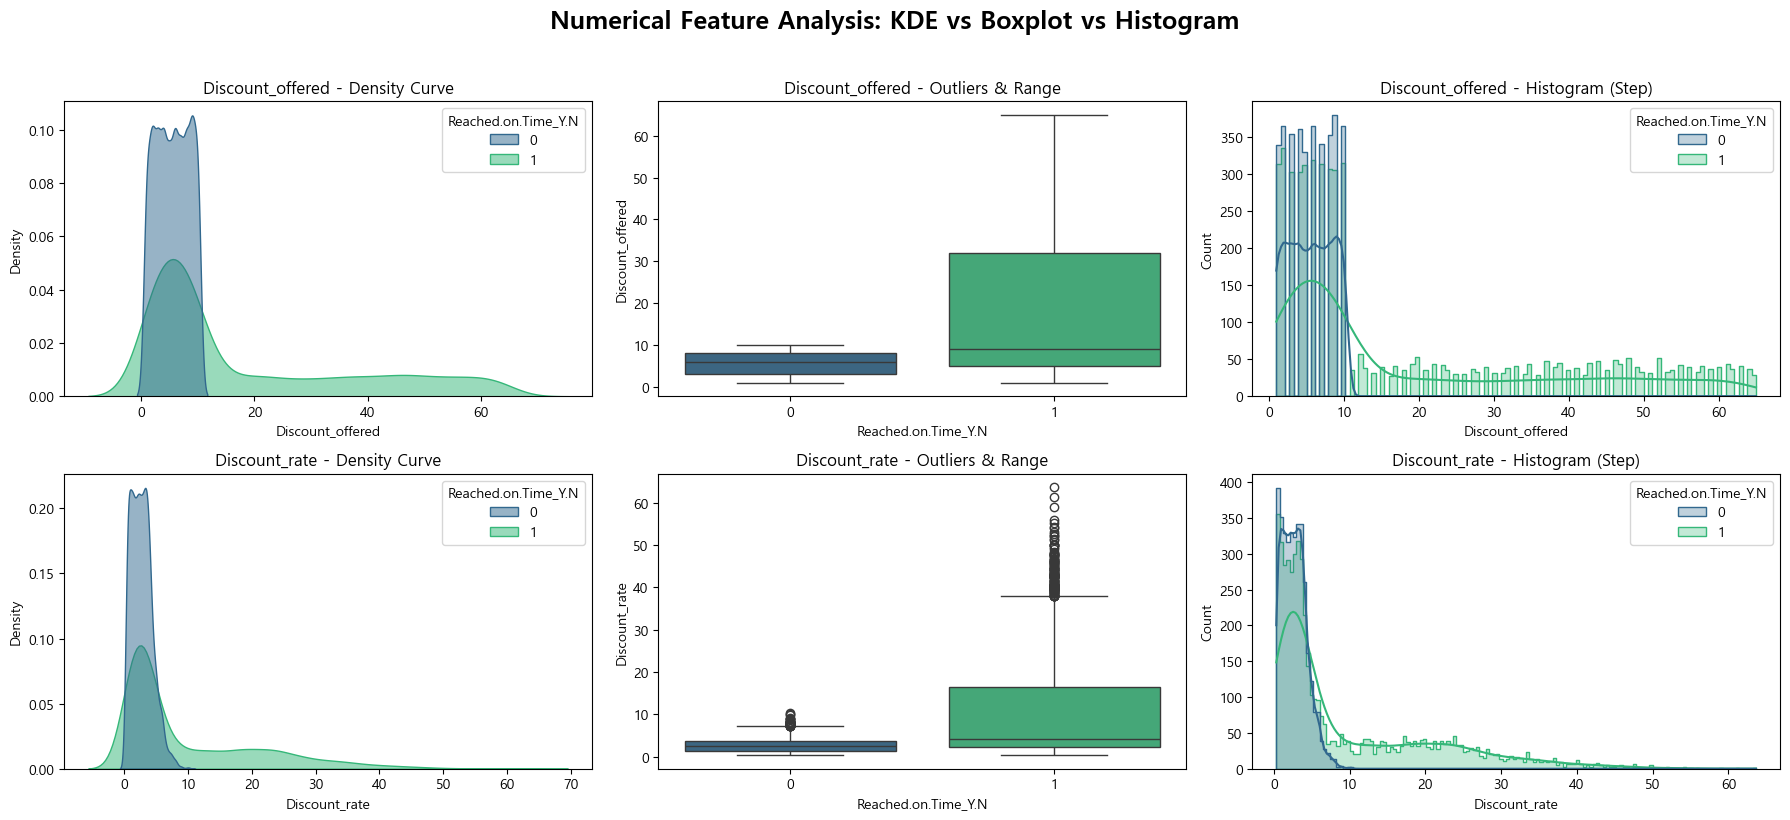

Discount_offered    0.398429
Discount_rate       0.381533
Name: Reached.on.Time_Y.N, dtype: float64


In [55]:
# 할인액과 할인율 비교
plot_numeric_analysis(copy_df, ['Discount_offered', 'Discount_rate'], target)
print(copy_df[['Discount_offered', 'Discount_rate', target]].corr()[target].drop(target))

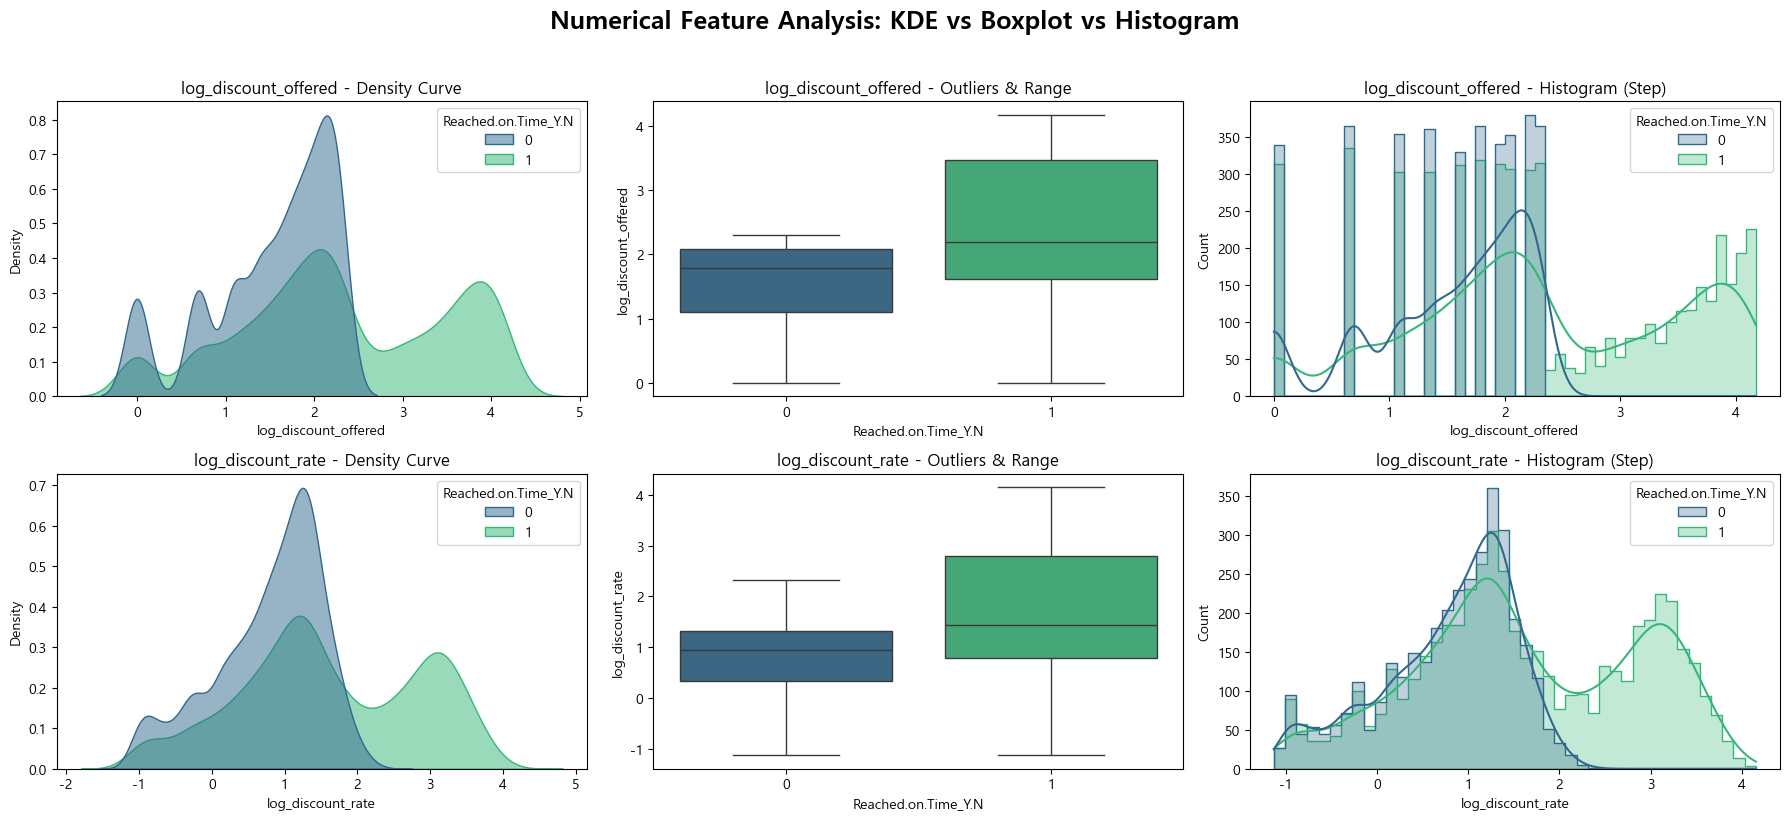

log_discount_offered    0.365141
log_discount_rate       0.362631
Name: Reached.on.Time_Y.N, dtype: float64


In [56]:
copy_df['log_discount_offered'] = np.log(copy_df['Discount_offered'])
copy_df['log_discount_rate'] = np.log(copy_df['Discount_rate'])

plot_numeric_analysis(copy_df, ['log_discount_offered', 'log_discount_rate'], target)
print(copy_df[['log_discount_offered', 'log_discount_rate', target]].corr()[target].drop(target))

Discount_offered의 상관계수가 가장 높다.

4. 할인가 Discounted_price

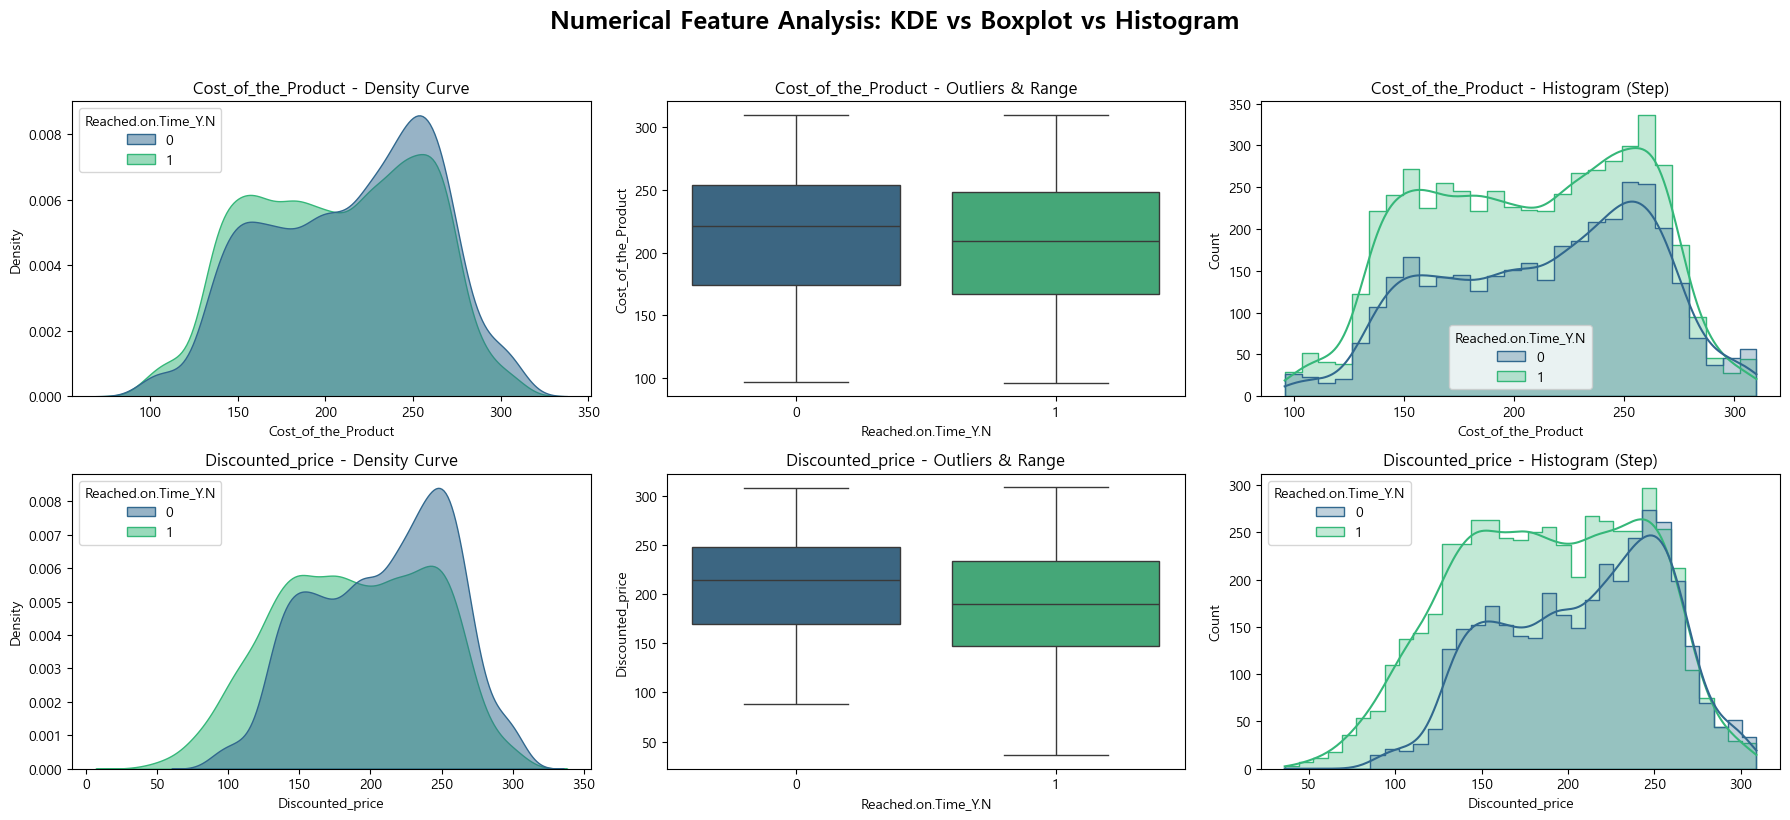

Discounted_price      -0.189176
Cost_of_the_Product   -0.073743
Name: Reached.on.Time_Y.N, dtype: float64


In [57]:
# 원가와 실구매가 비교 -> 실구매가가 더 나은 지표
copy_df['Discounted_price'] = copy_df['Cost_of_the_Product'] - copy_df['Discount_offered']
plot_numeric_analysis(copy_df, ['Cost_of_the_Product', 'Discounted_price'], target)
print(copy_df[['Discounted_price', 'Cost_of_the_Product', target]].corr()[target].drop(target))

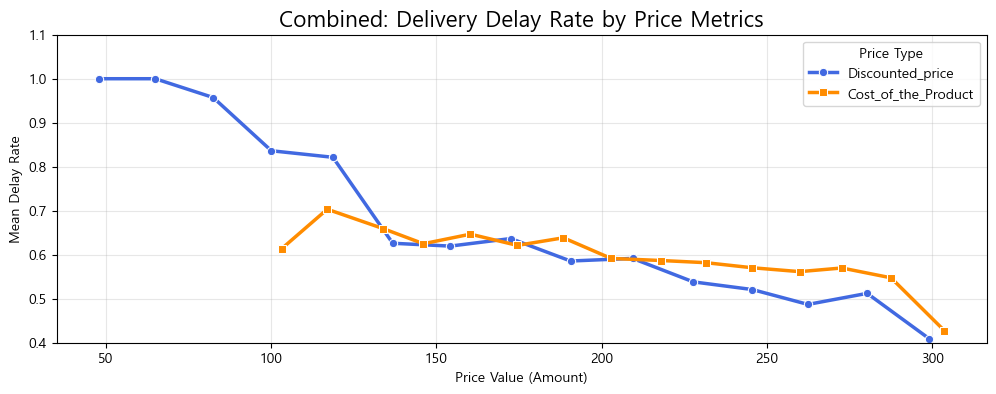

In [58]:
plt.figure(figsize=(12, 4))

# 분석할 두 타겟 변수
features = ['Discounted_price', 'Cost_of_the_Product']
colors = ['royalblue', 'darkorange']
markers = ['o', 's']

for col, color, marker in zip(features, colors, markers):
    temp_df = copy_df.copy()
    
    # 15개 정도로 더 세밀하게 구간 분할
    temp_df['Bin'] = pd.cut(temp_df[col], bins=15)
    
    # 구간별 평균 및 지연율 계산
    bin_stats = temp_df.groupby('Bin', observed=False).agg({
        col: 'mean',
        target: 'mean'
    }).dropna()
    
    # 하나의 axes에 겹쳐서 그리기
    sns.lineplot(x=bin_stats[col], y=bin_stats[target], marker=marker, 
                 label=col, color=color, linewidth=2.5)

plt.title('Combined: Delivery Delay Rate by Price Metrics', fontsize=16)
plt.xlabel('Price Value (Amount)')
plt.ylabel('Mean Delay Rate')
plt.legend(title='Price Type')
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.1) # 변화를 잘 보이게 하기 위해 범위를 조절

plt.show()

5. 무게당 가격 price_per_weight

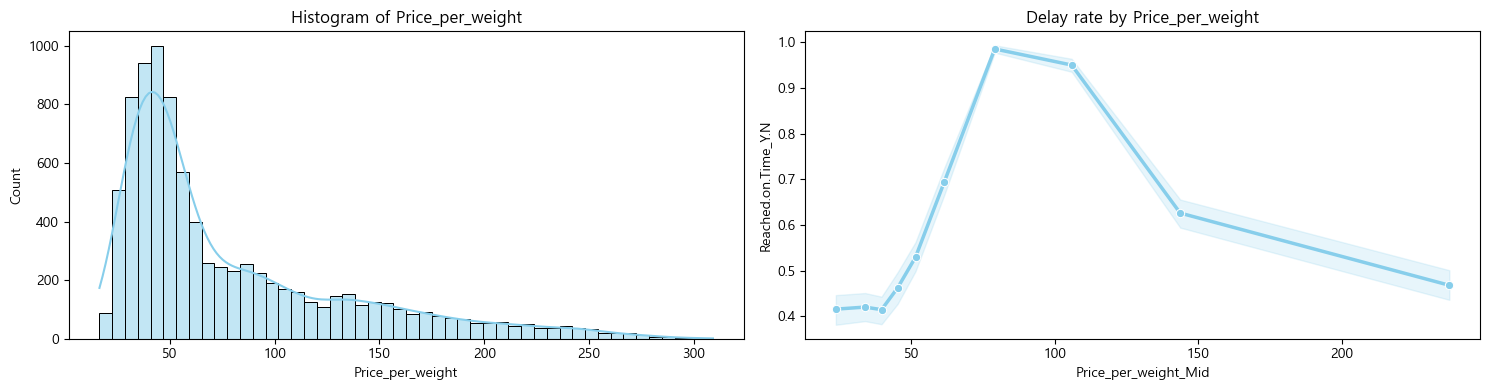

In [59]:
# 무게를 kg으로 변환하고 무게당 가격을 구한다.
copy_df['Price_per_weight'] = copy_df['Cost_of_the_Product'] / (copy_df['Weight_in_gms'] / 1000)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 2. 데이터를 10개 구간으로 나누기 (데이터 분포 중심의 qcut 사용)
copy_df['Price_per_weight_Bin'] = pd.qcut(copy_df['Price_per_weight'], q=10, duplicates='drop')
# 3. 구간별 중간값(X축용) 계산
copy_df['Price_per_weight_Mid'] = copy_df['Price_per_weight_Bin'].apply(lambda x: x.mid).astype(float)

# [왼쪽] 히스토그램 + KDE (전체적인 분포 모양)
sns.histplot(copy_df['Price_per_weight'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Price_per_weight')

# [오른쪽] 히스토그램 (이상치 및 사분위수 확인)
sns.lineplot(data=copy_df, x='Price_per_weight_Mid', y=target, ax=axes[1], marker='o', color='skyblue', linewidth=2.5)
axes[1].set_title('Delay rate by Price_per_weight')

plt.tight_layout()
plt.show()

In [60]:
corr_val = copy_df[['Price_per_weight', target]].corr().iloc[0, 1]
print(f"📊 상관계수 (Price_per_weight vs Target): {corr_val:.4f}")

📊 상관계수 (Price_per_weight vs Target): 0.0801


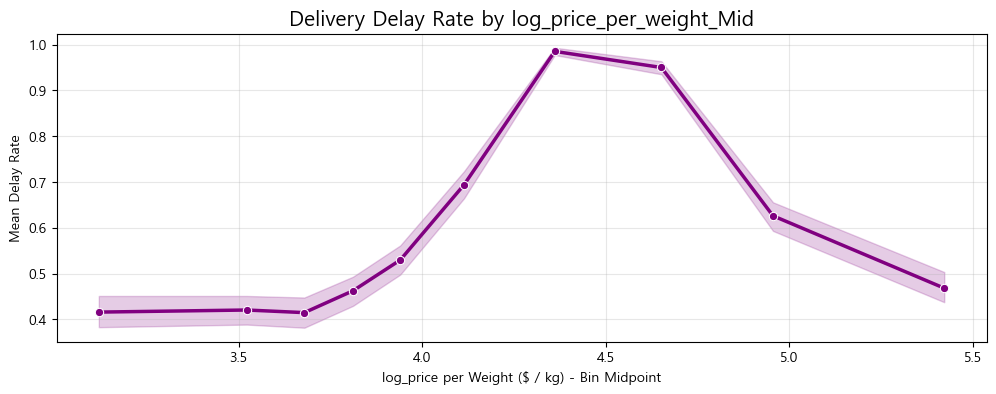

In [61]:
# Price_per_weight의 분포가 편향되었기 때문에 log를 취한다
copy_df['log_price_per_weight'] = np.log(copy_df['Price_per_weight'])

# 데이터를 10개 구간으로 나누기 (데이터 분포 중심의 qcut 사용)
copy_df['log_price_per_weight_Bin'] = pd.qcut(copy_df['log_price_per_weight'], q=10, duplicates='drop')
# 구간별 중간값(X축용) 계산
copy_df['log_price_per_weight_Mid'] = copy_df['log_price_per_weight_Bin'].apply(lambda x: x.mid).astype(float)
# 시각화
plt.figure(figsize=(12, 4))
sns.lineplot(data=copy_df, x='log_price_per_weight_Mid', y=target, marker='o', color='purple', linewidth=2.5)
plt.title('Delivery Delay Rate by log_price_per_weight_Mid', fontsize=15)
plt.xlabel('log_price per Weight ($ / kg) - Bin Midpoint')
plt.ylabel('Mean Delay Rate')
plt.grid(True, alpha=0.3)



In [62]:
corr_val = copy_df[['log_price_per_weight', target]].corr().iloc[0, 1]
print(f"📊 상관계수 (log_price_per_weight vs Target): {corr_val:.4f}")
plt.show()

📊 상관계수 (log_price_per_weight vs Target): 0.1728


새로운 파생변수 'Discount_group', 'Weight_Category', 'Discounted_price', 'log_price_per_weight'를 생성하였다

### 7. Product_importance
* high, medium, low 3개의 등급.
* high의 비중이 8%로 굉장히 적다.
* 중요도 high인 제품의 지연율이 역설적이게도 가장 높다. (지연율 64.8%)


* 가설1: 중요도의 기준은 제품의 중요도가 아닌 다른 기준이 있는가?

가설  검증
1. 중요도에 따라 제품과 관계된 지표가 어떻게 움직이는지 관찰

In [63]:
# 데이터 집계 (평균과 중앙값 모두 계산)
agg_dict = {col: ['mean', 'median'] for col in [
    'Price_per_weight', 'log_price_per_weight', 'Cost_of_the_Product', 
    'Discounted_price', 'Weight_in_gms', 'Discount_offered', 
    'Discount_rate', 'Prior_purchases'
]}
agg_dict['Reached.on.Time_Y.N'] = ['mean']

# 집계 결과 생성
result_table = copy_df.groupby('Product_importance').agg(agg_dict)


display(result_table.style.background_gradient(cmap='Blues').format("{:.2f}"))

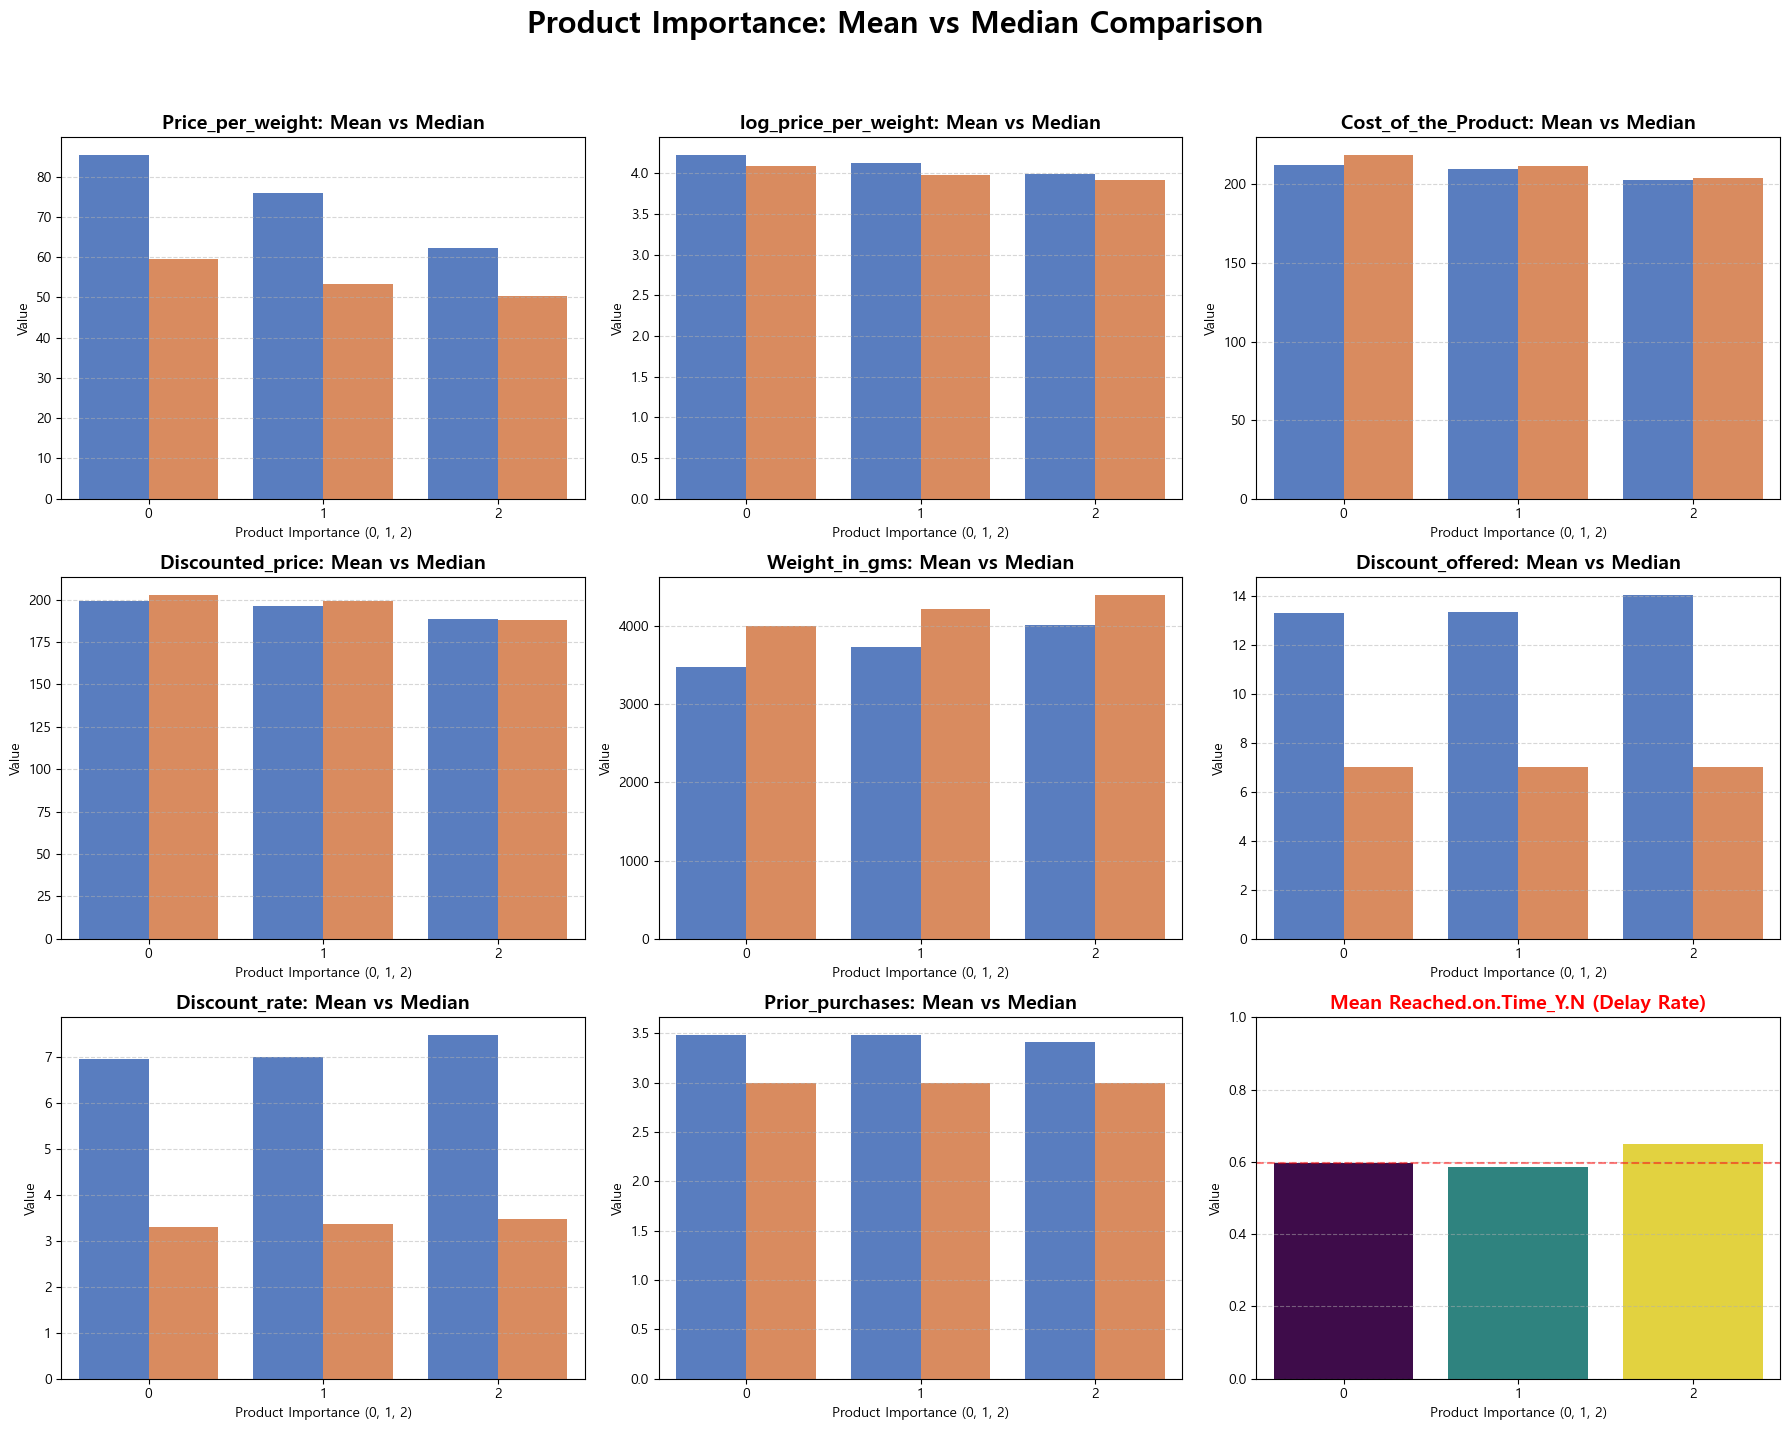

In [64]:
# 집계 및 멀티인덱스 칼럼 평탄화
result = copy_df.groupby('Product_importance').agg(agg_dict)
result.columns = [f"{col}_{stat}" for col, stat in result.columns]

# 시각화를 위한 변수 설정
cols_base = [
    'Price_per_weight', 'log_price_per_weight', 'Cost_of_the_Product', 
    'Discounted_price', 'Weight_in_gms', 'Discount_offered', 
    'Discount_rate', 'Prior_purchases', 'Reached.on.Time_Y.N'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Product Importance: Mean vs Median Comparison', fontsize=22, fontweight='bold', y=0.98)

# 범례 핸들과 라벨을 저장할 변수
handles, labels = None, None

for i, col in enumerate(cols_base):
    row, col_idx = divmod(i, 3)
    ax = axes[row, col_idx]
    
    if col == 'Reached.on.Time_Y.N':
        # 지연율: 단일 지표이므로 범례 불필요
        sns.barplot(data=copy_df, x='Product_importance', y=col, ax=ax, hue='Product_importance', palette='viridis', legend=False, errorbar=None)
        ax.set_title(f'Mean {col} (Delay Rate)', fontsize=14, fontweight='bold', color='red')
        ax.axhline(copy_df[col].mean(), color='red', linestyle='--', alpha=0.5)
        ax.set_ylim(0, 1)
    else:
        # 평균과 중앙값 비교 데이터 구성
        plot_df = result[[f"{col}_mean", f"{col}_median"]].reset_index().melt(
            id_vars='Product_importance', value_vars=[f"{col}_mean", f"{col}_median"],
            var_name='Stat', value_name='Value'
        )
        plot_df['Stat'] = plot_df['Stat'].str.replace(f"{col}_", "")
        
        # legend=False를 추가하여 개별 subplot의 범례를 제거
        sns.barplot(data=plot_df, x='Product_importance', y='Value', hue='Stat', ax=ax, palette='muted', legend=False)
        ax.set_title(f'{col}: Mean vs Median', fontsize=14, fontweight='bold')

        # 첫 번째 대상 그래프에서만 범례 정보를 추출
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    ax.set_xlabel('Product Importance (0, 1, 2)')
    ax.set_ylabel('Value')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 전체 피규어의 우측 상단에 범례 추가
if handles:
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), title='Statistics', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

importance 분석 결론
* 무게 대비 가격이 싼 물품을 'high'에, 비싼 물품을 'low'에 배정
* 그 외의 할인액 등의 가격적인 측면은 영향력 미미

결론: Product_importance는 관리 후순위 지표

### 8. Customer_care_calls
* 2~7의 데이터가 있으나 너무 적은 데이터는 통합
* 3, 4, 5, 6회의 전화 문의
* 문의가 많아질수록 지연율이 적어짐을 확인
* 문의 횟수의 최소값이 2라는 점은 배송이 지연되지 않았을 때의 수치라고 하기에는 이상함
* 가설 1: 이 데이터는 현재 배송에 대한 문의가 아니라, 지금까지 누적되어온 횟수이다.
* 가설 2: 배송에 대한 상태를 알리기 위해 회사측이 발송한 안내 횟수이다.
    - 즉, 회사에서 특별 관리하는 화물을 알리는 지표이다.


가설 1 검증
* Customer_care_call이 과거부터 누적되어온 수치라면, 구매횟수가 증가할수록 call의 횟수도 증가할것이다.

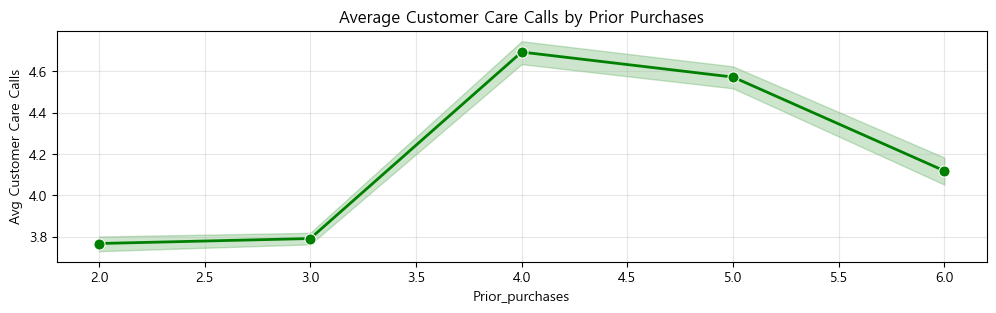

📊 두 변수의 상관계수: 0.2559


In [65]:
# 과거 구매 횟수에 따른 문의 횟수의 증가 시각화

plt.figure(figsize=(12, 3))

# 1. 선 그래프 (Line Plot): 각 Prior_purchases 별 평균 Call 횟수의 변화 흐름
# 그림자(shade) 구간은 신뢰구간(95% confidence interval)입니다.
sns.lineplot(data=train_df, x='Prior_purchases', y='Customer_care_calls', 
             marker='o', markersize=8, linewidth=2, color='green')

plt.title('Average Customer Care Calls by Prior Purchases')
plt.ylabel('Avg Customer Care Calls')
plt.grid(True, alpha=0.3)
plt.show()

# 2. 수학적 상관계수 계산
corr = train_df[['Prior_purchases', 'Customer_care_calls']].corr().iloc[0, 1]
print(f"📊 두 변수의 상관계수: {corr:.4f}")

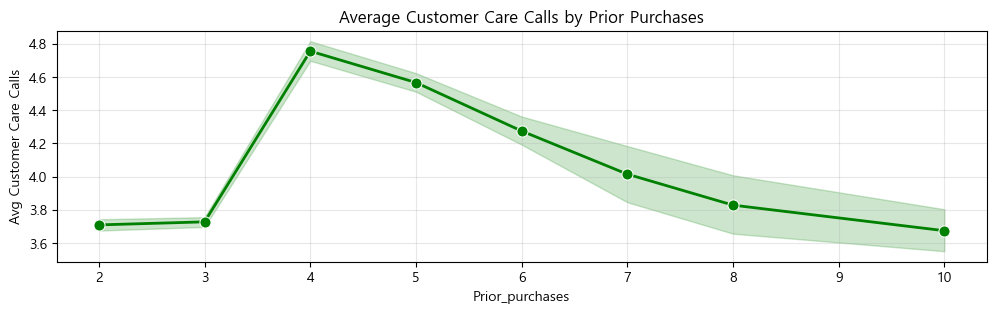

📊 두 변수의 상관계수: 0.1808


In [66]:
plt.figure(figsize=(12, 3))

# 1. 선 그래프 (Line Plot): 각 Prior_purchases 별 평균 Call 횟수의 변화 흐름
# 그림자(shade) 구간은 신뢰구간(95% confidence interval)입니다.
sns.lineplot(data=df, x='Prior_purchases', y='Customer_care_calls', 
             marker='o', markersize=8, linewidth=2, color='green')

plt.title('Average Customer Care Calls by Prior Purchases')
plt.ylabel('Avg Customer Care Calls')
plt.grid(True, alpha=0.3)
plt.show()

# 2. 수학적 상관계수 계산
corr = df[['Prior_purchases', 'Customer_care_calls']].corr().iloc[0, 1]
print(f"📊 두 변수의 상관계수: {corr:.4f}")

가설 검증 해석
* 가공 전/후의 데이터가 모두 4 이후에서 감소하는 모양
* 상관관계도 가공 전 0.18, 가공 후 0.26
* 이는 2가지 가능한 결론
    1. 누적된 기록이 아닌, 해당 배송에 대한 기록이다. -> 정시 배송에도 문의횟수 2는 설명이 안됨
    2. 해당 회사에서의 구매 경험이 많은 사람은 지연에 큰 신경을 쓰지 않는다.
    
'Calls_per_Purchase'를 만들고, 지연율과의 관계를 확인해본다

In [67]:
copy_df['Calls_per_Purchase'] = (copy_df['Customer_care_calls'] / copy_df['Prior_purchases']).round(2)

In [68]:
# 상관계수 계산
correlation = copy_df[['Calls_per_Purchase', target]].corr().iloc[0, 1]
print(f"상관계수 (Calls_per_Purchase vs {target}): {correlation:.4f}")

상관계수 (Calls_per_Purchase vs Reached.on.Time_Y.N): 0.0242


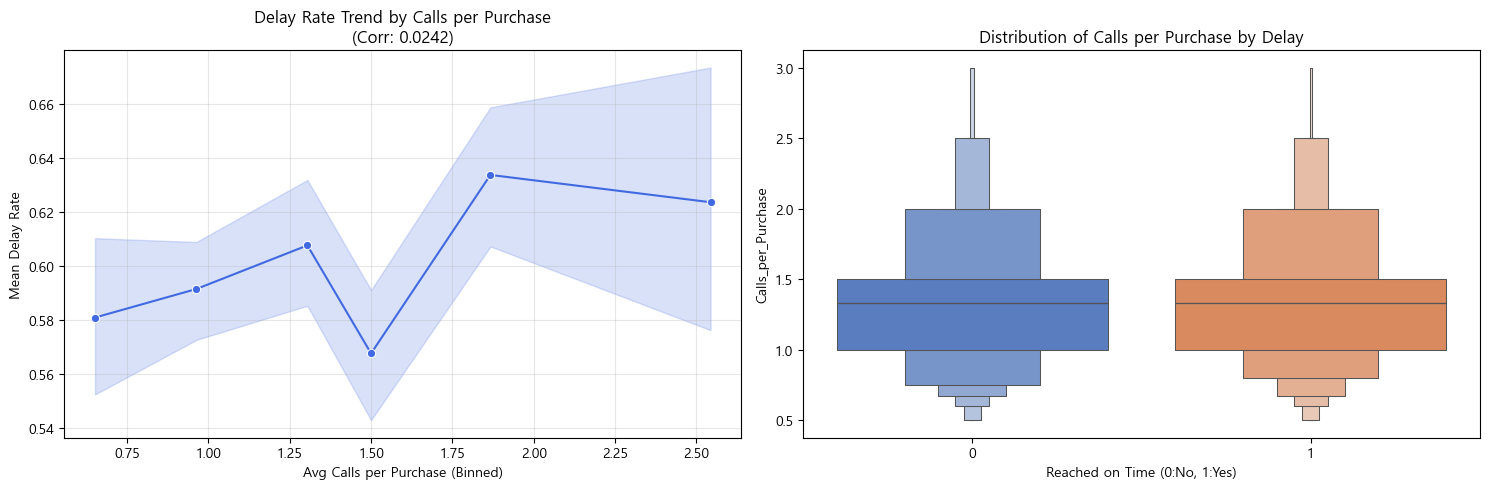

In [69]:
# 시각화 (추세 및 분포)
plt.figure(figsize=(15, 5))
# (1) 구간별 지연율 추세 (Binned Line Plot)
# 데이터를 10개 구간으로 나누어 구간별 평균 지연율 확인
copy_df['Calls_Bin'] = pd.qcut(copy_df['Calls_per_Purchase'], q=10, duplicates='drop')
copy_df['Calls_Bin_Mean'] = copy_df.groupby('Calls_Bin', observed=False)['Calls_per_Purchase'].transform('mean')
plt.subplot(1, 2, 1)
sns.lineplot(data=copy_df, x='Calls_Bin_Mean', y=target, marker='o', color='royalblue')
plt.title(f'Delay Rate Trend by Calls per Purchase\n(Corr: {correlation:.4f})')
plt.xlabel('Avg Calls per Purchase (Binned)')
plt.ylabel('Mean Delay Rate')
plt.grid(True, alpha=0.3)
# (2) 지연 여부에 따른 분포 차이 (Boxenplot / 상자 수염 그림의 확장형)
plt.subplot(1, 2, 2)
sns.boxenplot(data=copy_df, x=target, y='Calls_per_Purchase', hue=target, palette='muted', legend=False)
plt.title('Distribution of Calls per Purchase by Delay')
plt.xlabel('Reached on Time (0:No, 1:Yes)')
plt.tight_layout()
plt.show()

지연율과의 관계성은 낮은듯 하다.

가설 2 검증
* 회사의 특별 관리 화물 지표임을 증명할 방안
    1. 화물 관리 레벨(Management_score) =  관리 지표(call) / 배송 난이도(무게 당 가격 + 무게 가중치) 라고 가정
        * 무게가 지연율에 더 큰 영향을 주기 때문에 무게에 가중치를 준다.
    2. 'Management_score'에 따른 지연율 차이. 반비례할것이다.

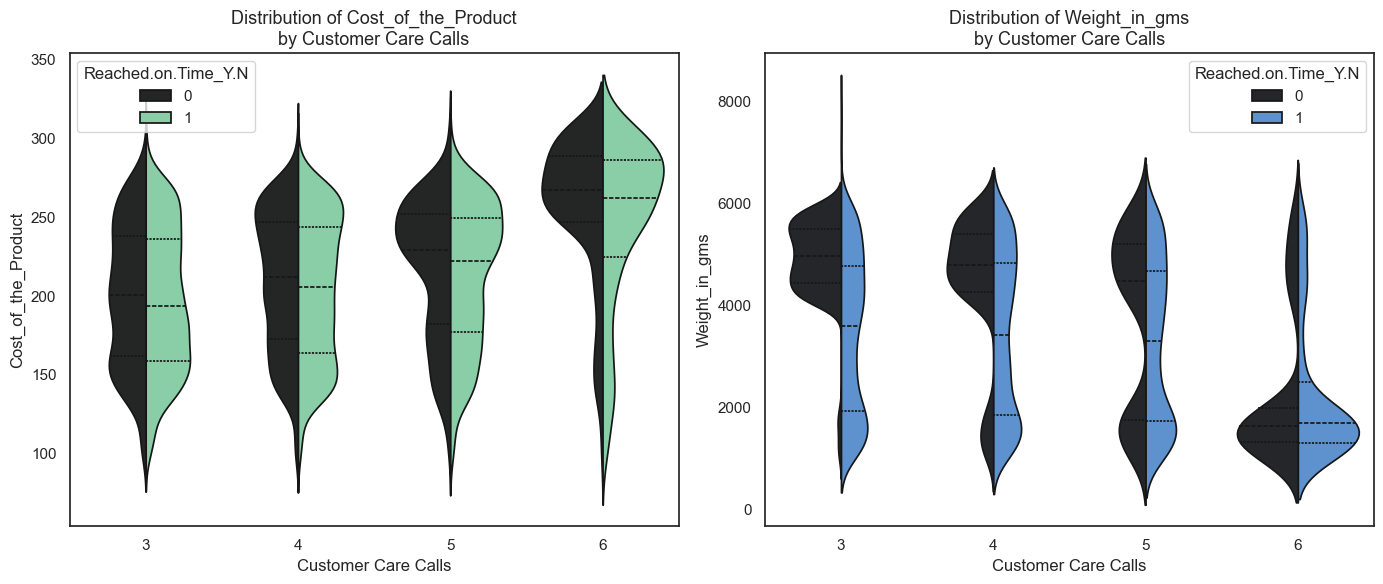

In [70]:
# 가설 검증 전 calls의 분포에 따른 무게, 가격의 분포를 분석

# 1. 시각화 스타일 설정
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 분석할 연속형 변수 리스트
features = [ 'Cost_of_the_Product', 'Weight_in_gms']
colors = ["#7ed9a4", "#4a90e2", "#ff7f50"] # 변수별로 다른 색상 적용

for i, col in enumerate(features):
    # 바이올린 플롯 생성: 전화 횟수에 따른 분포의 너비(밀도)를 확인
    sns.violinplot(data=train_df, x='Customer_care_calls', y=col, 
                   ax=axes[i], palette=f"dark:{colors[i]}", inner='quartile', split=True, hue=target)
    
    axes[i].set_title(f'Distribution of {col}\nby Customer Care Calls', fontsize=13)
    axes[i].set_xlabel('Customer Care Calls')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [71]:
copy_df['Cost_of_the_Product'].describe()

count    8799.000000
mean      210.230367
std        48.051317
min        96.000000
25%       170.000000
50%       214.000000
75%       251.000000
max       310.000000
Name: Cost_of_the_Product, dtype: float64

In [72]:
# Management_score 생성
copy_df['Management_score'] = (copy_df['Customer_care_calls'] / copy_df['Price_per_weight']) * ((copy_df['Weight_in_gms']/1000)**1.5)
copy_df['Management_score'].describe()

count    8799.000000
mean        0.687404
std         0.639853
min         0.011718
25%         0.096665
50%         0.582622
75%         1.073400
max         5.278219
Name: Management_score, dtype: float64

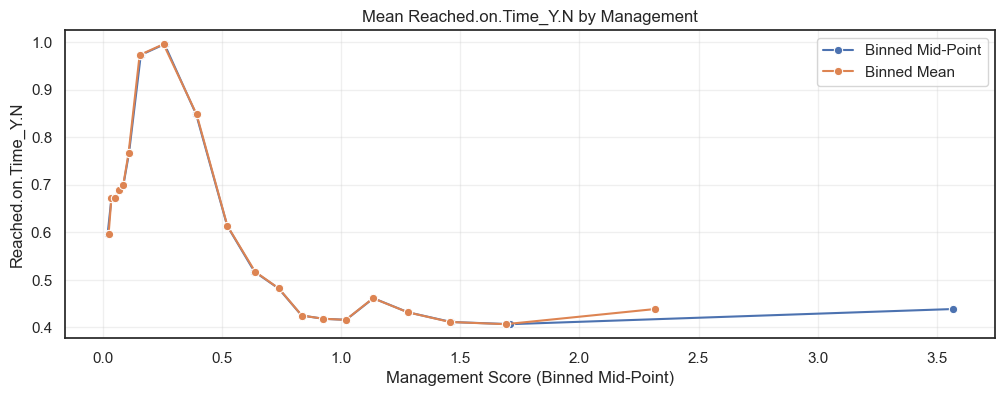

In [73]:
# Management_score에 따른 지연율의 시각화

# 1. 구간 나누기
copy_df['Management_Bin'] = pd.qcut(copy_df['Management_score'], q=20, duplicates='drop')

# 2. X축에 쓰기 위해 '구간의 대표값'을 축출해서 새로운 수치형 컬럼 생성
# 평균값과 중간값을 둘다 시도
copy_df['Management_Bin_Mid'] = copy_df['Management_Bin'].apply(lambda x: x.mid).astype(float)
copy_df['Management_Bin_Mean'] = copy_df.groupby('Management_Bin', observed=False)['Management_score'].transform('mean')
# 3. 시각화
plt.figure(figsize=(12, 4))
sns.lineplot(data=copy_df, x='Management_Bin_Mid', y=target, marker='o', errorbar=None, label='Binned Mid-Point')
sns.lineplot(data=copy_df, x='Management_Bin_Mean', y=target, marker='o', errorbar=None, label='Binned Mean')


plt.title(f'Mean {target} by Management')
plt.xlabel('Management Score (Binned Mid-Point)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [74]:
# 상관계수 출력
print(copy_df[['Management_score', target]].corr().iloc[0, 1])
print(copy_df[['Management_Bin_Mid', target]].corr().iloc[0, 1])
print(copy_df[['Management_Bin_Mean', target]].corr().iloc[0, 1])

-0.25796587429387613
-0.2281232389884021
-0.26581079270545654


* 임계점 이후에는 지연율이 낮아지는 것을 확인. 
* 파생변수로 사용 가능

#### 다른 특성과의 관계
##### 'Product_importance'와 'Customer_care_calls'
* 중요도가 높을수록 call이 적어지는 경향
* importance가 관리 후순위 지표라고 한다면 반비례성 경향이 이해간다.

## Feature engineering

In [75]:
# 꼬임 방지를 위해 새로 지정
train_df = pd.read_csv('data/train_df.csv')
test_df = pd.read_csv('data/test_df.csv')
target = 'Reached.on.Time_Y.N'
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   8799 non-null   int64 
 1   Warehouse_block      8799 non-null   object
 2   Mode_of_Shipment     8799 non-null   object
 3   Customer_care_calls  8799 non-null   int64 
 4   Customer_rating      8799 non-null   int64 
 5   Cost_of_the_Product  8799 non-null   int64 
 6   Prior_purchases      8799 non-null   int64 
 7   Product_importance   8799 non-null   object
 8   Gender               8799 non-null   object
 9   Discount_offered     8799 non-null   int64 
 10  Weight_in_gms        8799 non-null   int64 
 11  Reached.on.Time_Y.N  8799 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 825.0+ KB


### 1. 새로운 파생 변수
* 할인액이 10 초과인 'Discount_Group'
* 무게의 범주화 및 인코딩 'Weight_Category'
* 창고별 배송수단 조합 및 숫자로 변환(인코딩) 'Wh_Shipment_Combo'

* 'Prior_purchases' 6이상 항목을 6으로 통합
* 'Customer_care_calls' 3 이하를 3으로, 6 이상을 6으로 범주 정리

* 할인가 'Discounted_price' 생성
* log 무게 당 가격 ($/kg) 'log_price_per_weight' 생성
* 할인율 생성  'Discount_rate'
* 화물 관리 레벨 'Management_score' 생성

In [76]:
from sklearn.preprocessing import LabelEncoder

def apply_feature_engineering(df):
    # 1. Discount_Group 생성
    df['Discount_Group'] = (df['Discount_offered'] > 10).astype(int)
    
    # 2. Weight_Category 생성
    conditions = [
    (df['Weight_in_gms'] >= 4000) & (df['Weight_in_gms'] < 6000), 
    (df['Weight_in_gms'] >= 0) & (df['Weight_in_gms'] < 2000)     
    ]

    # 해당 조건에 대응하는 값 리스트
    choices = [0, 1]
    # 위의 조건들에 해당하지 않는 나머지(2000~4000 및 6000 이상)는 default 값 2으로 할당
    df['Weight_Category'] = np.select(conditions, choices, default=2)
   

    # 3. 창고별 배송수단 조합 
    df['Wh_Shipment_Combo'] = df['Warehouse_block'].astype(str) + '_' + df['Mode_of_Shipment'].astype(str)
    
    # 모델 학습을 위해 범주형을 숫자로 매핑 (Label Encoding과 유사)
    # AutoGluon을 쓰신다면 문자열 그대로 두어도 되지만, Scikit-learn 모델을 위해 숫자로 변환합니다.
    le = LabelEncoder()
    df['Wh_Shipment_Combo'] = le.fit_transform(df['Wh_Shipment_Combo']) + 1


    # 4. prior purchase 6이상 묶기
    df['Prior_purchases'] = df['Prior_purchases'].clip(upper=6)

    # 5. customer care call 범주 정리
    df['Customer_care_calls'] = df['Customer_care_calls'].clip(lower=3, upper=6)


    # 6. Discounted_price 생성
    df['Discounted_price'] = df['Cost_of_the_Product'] - df['Discount_offered']

    # 7. log_price_per_weight 생성
    df['Price_per_weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] / 1000)
    df['log_price_per_weight'] = np.log(df['Price_per_weight'])
    # 지연율과의 관계가 2차함수의 움직임을 따라가므로 polynomial을 판다스로 구현
    df['log_price_per_weight_sq'] =df['log_price_per_weight'] ** 2


    # 8. 할인율 Discount_rate 생성 
    df['Discount_rate'] = (df['Discount_offered'] / df['Cost_of_the_Product'])*100

    # 9. 화물 관리 레벨 Management_score 생성
    df['Management_score'] = (df['Customer_care_calls'] / df['Price_per_weight']) * ((df['Weight_in_gms']/1000)**1.5)
    # 지연율과의 관계가 2차함수의 움직임을 따라가므로 polynomial을 판다스로 구현
    df['Management_score_sq'] = df['Management_score'] ** 2

    return df

# 각각의 데이터셋에 적용
train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)


### 2. 필요없는 특성 drop

In [77]:
train_df.columns.to_list()

['ID',
 'Warehouse_block',
 'Mode_of_Shipment',
 'Customer_care_calls',
 'Customer_rating',
 'Cost_of_the_Product',
 'Prior_purchases',
 'Product_importance',
 'Gender',
 'Discount_offered',
 'Weight_in_gms',
 'Reached.on.Time_Y.N',
 'Discount_Group',
 'Weight_Category',
 'Wh_Shipment_Combo',
 'Discounted_price',
 'Price_per_weight',
 'log_price_per_weight',
 'log_price_per_weight_sq',
 'Discount_rate',
 'Management_score',
 'Management_score_sq']

중복 특성 정리

'Wh_Shipment_Combo': 'Warehouse_block', 'Mode_of_Shipment' <br>
'Weight_in_gms': 'Weight_Category' <br>
'Cost_of_the_Product': 'Discounted_price' <br>
'Discount_offered': 'Discount_rate', 'Discount_Group' <br>
'Price_per_weight': 'log_price_per_weight'

In [78]:
drop_columns = ["ID", "Gender", "Customer_rating"] #"Discount_offered", "Weight_in_gms",'Warehouse_block', 'Mode_of_Shipment', 'Customer_rating'
train_df = train_df.drop(drop_columns, axis=1)
test_df = test_df.drop(drop_columns, axis=1)

### 3. 인코딩

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder



def apply_feature_preprocessing(df):

    # 1. Product_importance: Label Encoding (순서가 있으므로 수동 매핑)
    importance_map = {'low': 0, 'medium': 1, 'high': 2}
    df['Product_importance'] = df['Product_importance'].map(importance_map)

    # 2. One-Hot Encoding (Warehouse_block, Mode_of_Shipment, Wh_Shipment_Combo)
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment'])

    return df
    
# 각각의 데이터셋에 적용
train_df = apply_feature_preprocessing(train_df)
test_df = apply_feature_preprocessing(test_df)




### 4. 스케일링

In [80]:
# Scaling 대상 컬럼 선정
num_features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 
                    'Discount_rate', 'Management_score', 'log_price_per_weight_sq', 'Management_score_sq']

scaler = StandardScaler()

# 중요: fit은 오직 train_df에만 수행합니다!
train_df[num_features] = scaler.fit_transform(train_df[num_features])

# test는 transform만 수행하여 데이터 누수를 차단합니다.
test_df[num_features] = scaler.transform(test_df[num_features])

In [81]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8799 entries, 0 to 8798
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_care_calls      8799 non-null   int64  
 1   Cost_of_the_Product      8799 non-null   float64
 2   Prior_purchases          8799 non-null   int64  
 3   Product_importance       8799 non-null   int64  
 4   Discount_offered         8799 non-null   float64
 5   Weight_in_gms            8799 non-null   float64
 6   Reached.on.Time_Y.N      8799 non-null   int64  
 7   Discount_Group           8799 non-null   int64  
 8   Weight_Category          8799 non-null   int64  
 9   Wh_Shipment_Combo        8799 non-null   int64  
 10  Discounted_price         8799 non-null   float64
 11  Price_per_weight         8799 non-null   float64
 12  log_price_per_weight     8799 non-null   float64
 13  log_price_per_weight_sq  8799 non-null   float64
 14  Discount_rate           

* 학습용 데이터 train_df
    - 학습을 위해 train_test_split으로 나누어야 할 것.
* 검증용 데이터 test_df

## 모델링

In [82]:
# =========================
# 1. 기본 데이터 처리 & 시각화
# =========================
import pandas as pd              # 데이터프레임 처리
import numpy as np               # 수치 연산
import matplotlib.pyplot as plt  # 기본 시각화
import seaborn as sns            # 통계 시각화
from scipy.stats import randint, uniform  # 랜덤 탐색용 분포

# =========================
# 2. Scikit-learn: 데이터 분할 & 하이퍼파라미터 튜닝
# =========================
from sklearn.model_selection import (
    StratifiedKFold,      # 클래스 비율 유지 교차검증
    cross_validate,       # 다중 평가지표 교차검증
    GridSearchCV,         # 격자 탐색 최적화
    RandomizedSearchCV,   # 랜덤 탐색 최적화
    train_test_split      # 데이터 분할 (필요 시 사용)
)

# =========================
# 3. Scikit-learn: 전처리 & 파이프라인
# =========================
from sklearn.compose import ColumnTransformer   # 컬럼별 전처리
from sklearn.preprocessing import OneHotEncoder  # 범주형 인코딩
from sklearn.pipeline import Pipeline            # 프로세스 자동화 파이프라인

# =========================
# 4. Scikit-learn: 평가지표
# =========================
from sklearn.metrics import (
    accuracy_score,      # 정확도
    precision_score,     # 정밀도
    recall_score,        # 재현율
    f1_score,            # F1-스코어
    roc_auc_score        # ROC-AUC 곡선 면적
)

# =========================
# 5. Scikit-learn: 모델 (분류)
# =========================
from sklearn.linear_model import LogisticRegression      # 로지스틱 회귀
from sklearn.tree import DecisionTreeClassifier          # 결정트리
from sklearn.neighbors import KNeighborsClassifier       # KNN
from sklearn.svm import SVC                              # 서포트 벡터 머신
from sklearn.ensemble import (
    RandomForestClassifier,         # 랜덤 포레스트
    ExtraTreesClassifier,           # 익스트라 트리
    GradientBoostingClassifier,     # 그래디언트 부스팅
    HistGradientBoostingClassifier  # 히스토그램 기반 GBM
)

# =========================
# 6. 외부 부스팅 모델 (설치 필요)
# =========================
try:
    from xgboost import XGBClassifier       # XGBoost
    from lightgbm import LGBMClassifier     # LightGBM
    from catboost import CatBoostClassifier  # CatBoost
except ImportError:
    print("⚠️ 일부 부스팅 모델(XGBoost, LightGBM, CatBoost)이 설치되지 않았습니다.")

In [83]:
# ==========================================
# 1. 환경 설정 및 공정성 확보 (공식 설정)
# ==========================================
seed = 42
SEED = 42
TARGET = 'Reached.on.Time_Y.N'
K = 5           # 5-Fold CV
GAP_LIMIT = 0.10 # 과적합 판정 기준
CV_NJOBS = -1   # 병렬 처리

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
scoring = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

print(f"✅ 설정 완료: SEED={SEED}, {K}-Fold CV 준비됨")

✅ 설정 완료: SEED=42, 5-Fold CV 준비됨


In [84]:
# ==========================================
# 2. 데이터 버전 고정 (Raw / FE 분리)
# ==========================================

train_raw = pd.read_csv('data/train_df.csv') 
test_raw  = pd.read_csv('data/test_df.csv')

# FE용 복사본 생성
train_fe = train_raw.copy()
test_fe  = test_raw.copy()

print(f"✅ 데이터 로드 완료: Train {train_raw.shape}, Test {test_raw.shape}")

✅ 데이터 로드 완료: Train (8799, 12), Test (2200, 12)


In [85]:
# ==========================================
# 3. 전처리 함수 및 모델 정의 (도구함)
# ==========================================

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(X: pd.DataFrame):
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    
    pre = ColumnTransformer(
        transformers=[
            ("cat", make_ohe(), cat_cols),
            ("num", "passthrough", num_cols),
        ],
        remainder="drop"
    )
    return pre

# 모델 목록
models = [
    ('Logistic', LogisticRegression(max_iter=2000, random_state=SEED)),
    ('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=SEED)),
    ('k-NN', KNeighborsClassifier(n_neighbors=15)),
    ('SVM', SVC(probability=True, random_state=SEED)),
    ('RandomForest', RandomForestClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=SEED)),
    ('ExtraTrees', ExtraTreesClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=SEED)),
    ('GradBoost', GradientBoostingClassifier(random_state=SEED)),
    ('XGBoost', XGBClassifier(n_estimators=800, learning_rate=0.05, max_depth=4, random_state=SEED, eval_metric="logloss", verbosity=0)),
    ('LightGBM', LGBMClassifier(n_estimators=1200, learning_rate=0.03, max_depth=4, random_state=SEED, verbose=-1)),
    ('CatBoost', CatBoostClassifier(depth=4, iterations=1500, learning_rate=0.05, random_state=SEED, verbose=0, allow_writing_files=False))
]

print(f"✅ 전처리기 생성 함수 및 {len(models)}개 모델 정의 완료")

✅ 전처리기 생성 함수 및 10개 모델 정의 완료


In [86]:
# =================================================
# model_performance_list : 베스트 모델 담는 리스트
# =================================================

if 'model_performance_list' not in locals():
    model_performance_list = []
    print("🆕 바구니가 없어서 새로 만들었습니다.")
else:
    print(f"✅ 기존 바구니 유지 중 (현재 기록 수: {len(model_performance_list)}개)")

🆕 바구니가 없어서 새로 만들었습니다.


### 1. BASELINE MODEL ( only 기본변수 / 파생변수도 안 넣음 )

In [87]:
# ==========================================
# 1. BASELINE MODEL ( only 기본변수 / 파생변수도 안 넣음 )
# ==========================================

base_features = [
    'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 
    'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 
    'Product_importance', 'Discount_offered', 'Weight_in_gms'
]

X_base = train_raw[base_features]
y_base = train_raw[TARGET]

# 전처리기 생성
pre = make_preprocessor(X_base)

baseline_rows = []
for name, model in models:
    # 파이프라인 결합
    pipe = Pipeline([('preprocessor', pre), ('classifier', model)])
    
    cvres = cross_validate(
        pipe, X_base, y_base,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=CV_NJOBS
    )

    val_auc = np.mean(cvres["test_roc_auc"])
    train_auc = np.mean(cvres["train_roc_auc"])
    
    baseline_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,
        "Train_ROC_AUC": train_auc,
        "AUC_Gap": train_auc - val_auc,
        "Overfit_Flag": (train_auc - val_auc) > GAP_LIMIT
    })
    print(f"✅ {name} 검진 완료")

✅ Logistic 검진 완료
✅ DecisionTree 검진 완료
✅ k-NN 검진 완료
✅ SVM 검진 완료
✅ RandomForest 검진 완료
✅ ExtraTrees 검진 완료
✅ GradBoost 검진 완료
✅ XGBoost 검진 완료
✅ LightGBM 검진 완료
✅ CatBoost 검진 완료


In [88]:
# ==========================================
# [2] 최종 정밀 성적표 출력
# ==========================================
baseline_report = pd.DataFrame(baseline_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
baseline_report.insert(0, "Rank", np.arange(1, len(baseline_report) + 1))

print("\n🏆 [Step 1: Baseline] 8대 지표 정밀 성적표")
display(baseline_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
    .set_properties(**{'text-align': 'center'}))


🏆 [Step 1: Baseline] 8대 지표 정밀 성적표


,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6803,0.9322,0.5008,0.6513,0.7442,0.7547,0.0105,False
1,2,GradBoost,0.6768,0.8679,0.5410,0.6662,0.7380,0.8223,0.0843,False
2,3,CatBoost,0.6568,0.7536,0.6312,0.6870,0.7346,0.9395,0.2049,True
3,4,RandomForest,0.6556,0.7622,0.6158,0.6810,0.7340,0.9999,0.2659,True
4,5,ExtraTrees,0.6573,0.7399,0.6571,0.6959,0.7318,0.9996,0.2678,True
5,6,XGBoost,0.6573,0.7568,0.6278,0.6861,0.7311,0.9291,0.1980,True
6,7,k-NN,0.6534,0.7433,0.6402,0.6878,0.7309,0.8122,0.0813,False
7,8,LightGBM,0.6530,0.7512,0.6259,0.6828,0.7296,0.9181,0.1885,True
8,9,SVM,0.6579,0.7233,0.6910,0.7068,0.7223,0.7226,0.0003,False
9,10,Logistic,0.6404,0.7065,0.6802,0.6930,0.7202,0.7240,0.0038,False


### 2. FE ALL (기본+파생변수 전체)

In [89]:
# ==========================================
# 2. FE ALL (기본+파생변수 전체)
# ==========================================

train_fe = apply_feature_engineering(train_fe)
test_fe  = apply_feature_engineering(test_fe)

print(f"✅ FE 적용 완료!")
print(f"📊 현재 train_fe 전체 컬럼 개수: {len(train_fe.columns)}개")
print(f"📋 추가된 컬럼들: {[col for col in train_fe.columns if col not in train_raw.columns]}")

✅ FE 적용 완료!
📊 현재 train_fe 전체 컬럼 개수: 22개
📋 추가된 컬럼들: ['Discount_Group', 'Weight_Category', 'Wh_Shipment_Combo', 'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 'log_price_per_weight_sq', 'Discount_rate', 'Management_score', 'Management_score_sq']


In [90]:
# ==========================================
# [1] [HOLDOUT SETUP] train_df / test_df 고정 채점용 세팅 (FE 적용 직후 1회)
# ==========================================
# ==========================================
#  8개 변수 세팅 및 검수 : 컴퓨터가 고른 95% 임계값 기반 8개 명단(전체 데이터 분포 상위 5% 점수 받은 변수)
# ==========================================

optimal_8_features = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Weight_in_gms', 'Discounted_price', 'Discount_rate', 
    'log_price_per_weight', 'log_price_per_weight_sq'
]

X_case_b_95 = train_fe[optimal_8_features]
y_case_b_95 = train_fe[TARGET]  # y값도 데이터프레임 안의 정답 컬럼으로 지정

# 필수 체크
assert 'train_fe' in globals() and 'test_fe' in globals(), "train_fe/test_fe가 없습니다. FE 적용 셀 아래에 넣어주세요."
assert 'TARGET' in globals(), "TARGET 변수가 없습니다. TARGET='Reached.on.Time_Y.N' 셀 아래/근처에 넣어주세요."
assert 'optimal_8_features' in globals(), "optimal_8_features가 없습니다. 8개 변수 리스트 정의 후에 넣어주세요."

# drop_cols는 존재하는 컬럼만 제거 (노트북 버전에 따라 ID/Gender 없을 수 있어서 안전 처리)
base_drop_cols = [TARGET, 'ID', 'Gender']
drop_cols = [c for c in base_drop_cols if c in train_fe.columns]

# ✅ 인덱스 정렬 이슈 원천 차단: reset_index 통일
X_train_fe = train_fe.drop(columns=drop_cols).reset_index(drop=True)
y_train    = train_fe[TARGET].astype(int).reset_index(drop=True)

X_test_fe  = test_fe.drop(columns=drop_cols).reset_index(drop=True)
y_test     = test_fe[TARGET].astype(int).reset_index(drop=True)

# ✅ 8개 변수 버전도 함께 고정
missing = [c for c in optimal_8_features if c not in X_train_fe.columns]
assert len(missing) == 0, f"optimal_8_features 중 train_fe에 없는 컬럼이 있습니다: {missing}"

X_train_8 = X_train_fe[optimal_8_features].copy()
X_test_8  = X_test_fe[optimal_8_features].copy()

print("✅ Holdout 세팅 완료")
print(f"Train: X={X_train_8.shape}, y={y_train.shape} | Test: X={X_test_8.shape}, y={y_test.shape}")
print("y_test 분포:", y_test.value_counts(normalize=True).round(3).to_dict())


✅ Holdout 세팅 완료
Train: X=(8799, 8), y=(8799,) | Test: X=(2200, 8), y=(2200,)
y_test 분포: {1: 0.597, 0: 0.403}


In [91]:
# ==========================================
# [2] 5-Fold CV 및 8대 지표 산출 (FE All 버전)
# ==========================================

# [중요] 아까 만든 train_fe를 가지고 X(문제)와 y(정답)를 여기서 정의
drop_cols = ['ID', 'Gender', TARGET] # 제거할 컬럼 리스트
X_fe_all = train_fe.drop(columns=[c for c in drop_cols if c in train_fe.columns])
y_fe_all = train_fe[TARGET]

fe_all_rows = []
print(f"🚀 [FE All] 총 {len(models)}개 모델, 정밀 검진 시작!")
print(f"👉 사용되는 변수 개수: {X_fe_all.shape[1]}개") # 22개에서 ID, Target 빠지니까 19~20개 정도 될 것임

# 전처리기 생성 (이제 X_fe_all이 정의되었으니 에러 안 남!)
pre_fe = make_preprocessor(X_fe_all)

for name, model in models:
    # 파이프라인 결합
    pipe = Pipeline([('preprocessor', pre_fe), ('classifier', model)])
    
    cvres = cross_validate(
        pipe, X_fe_all, y_fe_all,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1 # CV_NJOBS 대신 -1 쓰면 가능한 모든 코어 사용
    )

    # 지표 계산
    val_auc = np.mean(cvres["test_roc_auc"])
    train_auc = np.mean(cvres["train_roc_auc"])
    
    fe_all_rows.append({
        "Model": name,
        "Accuracy": np.mean(cvres["test_accuracy"]),
        "Precision": np.mean(cvres["test_precision"]),
        "Recall": np.mean(cvres["test_recall"]),
        "F1_Score": np.mean(cvres["test_f1"]),
        "Val_ROC_AUC": val_auc,
        "Train_ROC_AUC": train_auc,
        "AUC_Gap": train_auc - val_auc,
        "Overfit_Flag": (train_auc - val_auc) > 0.05 # GAP_LIMIT 대신 0.05나 변수 사용
    })
    print(f"✅ {name} 검진 완료 (Val AUC: {val_auc:.4f})")

# 결과 리포트 출력
fe_all_report = pd.DataFrame(fe_all_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
fe_all_report.insert(0, "Rank", np.arange(1, len(fe_all_report) + 1))

print("\n🏆 [Step 2: FE All] 8대 지표 정밀 성적표")
display(fe_all_report.style
    .background_gradient(cmap='Pastel1', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    }))

🚀 [FE All] 총 10개 모델, 정밀 검진 시작!
👉 사용되는 변수 개수: 19개
✅ Logistic 검진 완료 (Val AUC: 0.7353)
✅ DecisionTree 검진 완료 (Val AUC: 0.7452)
✅ k-NN 검진 완료 (Val AUC: 0.7354)
✅ SVM 검진 완료 (Val AUC: 0.7289)
✅ RandomForest 검진 완료 (Val AUC: 0.7363)
✅ ExtraTrees 검진 완료 (Val AUC: 0.7321)
✅ GradBoost 검진 완료 (Val AUC: 0.7425)
✅ XGBoost 검진 완료 (Val AUC: 0.7383)
✅ LightGBM 검진 완료 (Val AUC: 0.7357)
✅ CatBoost 검진 완료 (Val AUC: 0.7377)

🏆 [Step 2: FE All] 8대 지표 정밀 성적표


,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,DecisionTree,0.6862,0.9699,0.4893,0.6504,0.7452,0.7539,0.0087,False
1,2,GradBoost,0.6775,0.8649,0.5451,0.6683,0.7425,0.8376,0.0951,True
2,3,XGBoost,0.6589,0.7575,0.6303,0.6880,0.7383,0.9576,0.2193,True
3,4,CatBoost,0.6561,0.7492,0.6368,0.6884,0.7377,0.9656,0.2279,True
4,5,RandomForest,0.6543,0.7565,0.6208,0.6818,0.7363,1.0000,0.2637,True
5,6,LightGBM,0.6571,0.7539,0.6318,0.6874,0.7357,0.9471,0.2114,True
6,7,k-NN,0.6594,0.7491,0.6455,0.6934,0.7354,0.8150,0.0796,True
7,8,Logistic,0.6666,0.7995,0.5893,0.6783,0.7353,0.7407,0.0055,False
8,9,ExtraTrees,0.6526,0.7559,0.6173,0.6794,0.7321,1.0000,0.2679,True
9,10,SVM,0.6589,0.7273,0.6853,0.7057,0.7289,0.7293,0.0004,False


#### 2-1. 변수중요도

🔧 문자로 된 컬럼 3개를 숫자로 변환합니다: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance']
------------------------------------------------------------
✅ [Feature Importance] 정밀 진단 준비 완료!
📊 진단 대상 변수 총 개수: 19개

🏆 [FE All] 24개 변수 진짜 기여도 성적표


,Feature,Importance,Percentage (%)
0,Discount_Group,0.4737,47.37%
1,Discount_offered,0.2432,24.32%
2,Weight_Category,0.1009,10.09%
3,Weight_in_gms,0.0315,3.15%
4,Discounted_price,0.0296,2.96%
5,Discount_rate,0.0296,2.96%
6,log_price_per_weight_sq,0.0166,1.66%
7,Price_per_weight,0.0160,1.60%
8,Cost_of_the_Product,0.0147,1.47%
9,log_price_per_weight,0.0120,1.20%


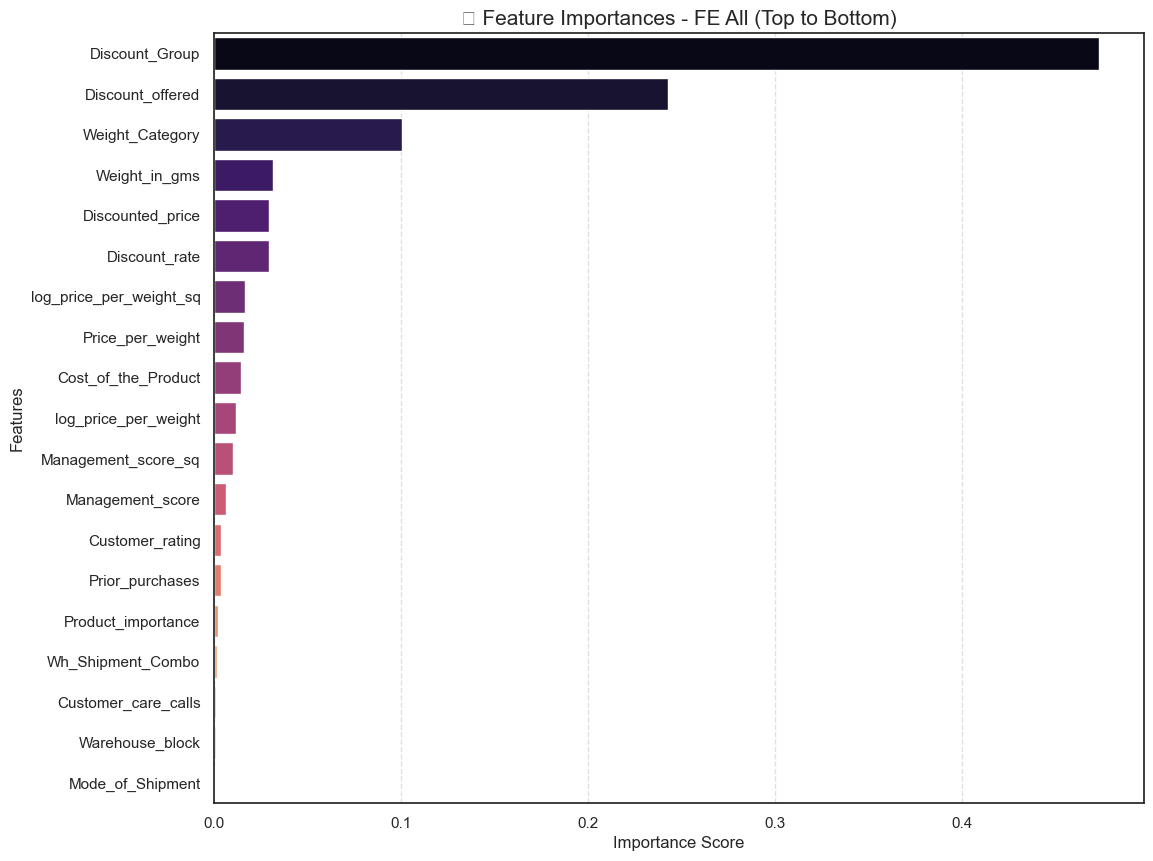

In [92]:
from sklearn.preprocessing import OrdinalEncoder

# ==========================================
# 1. 🔥 변수 검수 및 인코딩 (수정된 부분)
# ==========================================
# 원본 데이터 보호를 위해 복사본 생성
X_fe_encoded = X_fe_all.copy()

# 문자열(object) 컬럼만 골라서 숫자로 변환 (Ordinal Encoding)
# 이렇게 해야 변수 개수(24개)가 안 늘어나고 그대로 유지됨!
cat_cols = X_fe_encoded.select_dtypes(include=['object', 'category']).columns
print(f"🔧 문자로 된 컬럼 {len(cat_cols)}개를 숫자로 변환합니다: {list(cat_cols)}")

oe = OrdinalEncoder()
X_fe_encoded[cat_cols] = oe.fit_transform(X_fe_encoded[cat_cols])

all_features_names = X_fe_encoded.columns

print("-" * 60)
print(f"✅ [Feature Importance] 정밀 진단 준비 완료!")
print(f"📊 진단 대상 변수 총 개수: {len(all_features_names)}개")

# ==========================================
# 2. 모델 학습 및 중요도 추출 (Gradient Boosting)
# ==========================================
# 이제 모든 데이터가 숫자니까 에러 안 남!
model_24 = GradientBoostingClassifier(random_state=42)
model_24.fit(X_fe_encoded, y_fe_all) 

all_importances = model_24.feature_importances_

# ==========================================
# 3. 데이터프레임 생성 및 % 환산
# ==========================================
fi_all_df = pd.DataFrame({
    'Feature': all_features_names,
    'Importance': all_importances
})

# 전체 중요도의 합을 100%로 환산
fi_all_df['Percentage (%)'] = (fi_all_df['Importance'] / fi_all_df['Importance'].sum()) * 100
# 중요도 높은 순으로 정렬
fi_all_df = fi_all_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# ==========================================
# 4. 결과 출력 및 시각화
# ==========================================
print("\n🏆 [FE All] 24개 변수 진짜 기여도 성적표")
display(fi_all_df.style.format({'Importance': '{:.4f}', 'Percentage (%)': '{:.2f}%'})
                 .background_gradient(cmap='Reds', subset=['Importance']))

plt.figure(figsize=(12, 10))
sns.barplot(data=fi_all_df, x='Importance', y='Feature', palette='magma')
plt.title('🏆 Feature Importances - FE All (Top to Bottom)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 3. 변수 줄이기

In [93]:
# ==========================================
# 자동 채점 기계(함수) 조립하기
# ==========================================

def get_model_report(X, y, case_name):

    report_rows = []
    # 앞서 정의한 make_preprocessor를 사용하여 데이터 타입 자동 처리
    preprocessor = make_preprocessor(X)
    
    print(f"🚀 [{case_name}] 8대 지표 정밀 검진 시작!")

    # 앞서 정의한 models 리스트와 skf, scoring, GAP_LIMIT 활용
    for name, model in models:
        pipe = Pipeline([('pre', preprocessor), ('clf', model)])
        
        cvres = cross_validate(
            pipe, X, y, cv=skf, n_jobs=-1,
            scoring=scoring, return_train_score=True
        )

        train_auc = np.mean(cvres["train_roc_auc"])
        val_auc   = np.mean(cvres["test_roc_auc"])
        gap_auc   = train_auc - val_auc

        report_rows.append({
            "Model": name,
            "Accuracy": np.mean(cvres["test_accuracy"]),
            "Precision": np.mean(cvres["test_precision"]),
            "Recall": np.mean(cvres["test_recall"]),
            "F1_Score": np.mean(cvres["test_f1"]),
            "Val_ROC_AUC": val_auc,
            "Train_ROC_AUC": train_auc,
            "AUC_Gap": gap_auc,
            "Overfit_Flag": gap_auc > GAP_LIMIT
        })
        print(f"✅ {name} 검진 완료!")

    # 점수 순으로 정렬하여 성적표 리턴
    report_df = pd.DataFrame(report_rows).sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
    report_df.insert(0, "Rank", np.arange(1, len(report_df) + 1))
    return report_df

In [94]:
# ====================================================
# 3. [3-1] 변수 선택해서 넣기 (A0, A, A-2, B)
# ====================================================

# (1) A0: 기준 16개 (Warehouse_block/Mode of Shipment/Weight_in_gms 제거)
cols_A0 = [
    'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 
    'Prior_purchases', 'Product_importance', 'Discount_offered', 
    'Discount_Group', 'Weight_Category', 'Wh_Shipment_Combo', 
    'Discounted_price', 'Price_per_weight', 'log_price_per_weight', 
    'log_price_per_weight_sq', 'Discount_rate', 'Management_score', 
    'Management_score_sq'
]

# (2) A: A0 기반 노이즈 제거 (11개)
cols_A = [
    'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 
    'Prior_purchases', 'Product_importance', 'Discount_offered', 
    'Discount_Group', 'Discounted_price', 'Discount_rate', 
    'Management_score', 'Management_score_sq'
]

# (3) A2: 중요도 상위 5개 (Top 5)
cols_A2 = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Discount_rate', 'Discounted_price'
]

# (4) B: 통계적 최적 조합 (8개) (통계적 성능 상위 5% 컬럼만)
cols_B = [
    'Discount_Group', 'Discount_offered', 'Weight_Category', 
    'Weight_in_gms', 'Discounted_price', 'Discount_rate', 
    'log_price_per_weight', 'log_price_per_weight_sq'
]

# f-string 안에서 len()을 써서 자동으로 숫자를 보여주기!
print(f"✅ [1. 정의 완료] A0({len(cols_A0)}), A({len(cols_A)}), A2({len(cols_A2)}), B({len(cols_B)}) 멤버 선발 끝!")

✅ [1. 정의 완료] A0(16), A(11), A2(5), B(8) 멤버 선발 끝!


In [95]:
# === [FIXCELL:TEST_PAPER_BINDING_v3_1] ===
# 목적: 수동/AutoML이 "동일한 행 + 동일한 feature set"으로 채점되게 고정

assert 'train_fe' in globals() and 'test_fe' in globals(), "train_fe/test_fe가 없습니다. FE 적용 셀(143) 먼저 실행하세요."
assert TARGET in train_fe.columns and TARGET in test_fe.columns, f"TARGET({TARGET}) 컬럼이 train_fe/test_fe에 없습니다."

# ✅ 케이스 선택: "A" = (Warehouse/Mode/Weight 제거 11개), "B" = (최적 8개)
FEATURE_CASE = "B"   # <-- 여기만 바꾸면 됨 ("A" 또는 "B")

FEATURE_MAP = {
    "A0": cols_A0,
    "A":  cols_A,
    "A2": cols_A2,
    "B":  cols_B
}
FEATURES = FEATURE_MAP[FEATURE_CASE]

# 공통 시험지(행 동일) + 공통 피처(컬럼 동일)
X_train_shared = train_fe[FEATURES].copy()
y_train_shared = train_fe[TARGET].astype(int).copy()

X_test_shared  = test_fe[FEATURES].copy()
y_test_shared  = test_fe[TARGET].astype(int).copy()

print("✅ 시험지/정답지 고정 완료")
print(f"- CASE={FEATURE_CASE} | #features={len(FEATURES)}")
print(f"- Train X={X_train_shared.shape}, y={y_train_shared.shape}")
print(f"- Test  X={X_test_shared.shape}, y={y_test_shared.shape}")
print("- y_test 분포:", y_test_shared.value_counts(normalize=True).round(3).to_dict())


✅ 시험지/정답지 고정 완료
- CASE=B | #features=8
- Train X=(8799, 8), y=(8799,)
- Test  X=(2200, 8), y=(2200,)
- y_test 분포: {1: 0.597, 0: 0.403}


In [96]:
# ====================================================
# [3-2. 채점] 각 케이스별 10대 모델 일괄 채점
# ====================================================
print("🚀 모든 케이스 정밀 검진 시작... (A0, A, A2, B)")

report_A0 = get_model_report(X_fe_all[cols_A0], y_fe_all, "A0 (16-Original)")
report_A  = get_model_report(X_fe_all[cols_A],  y_fe_all, "A (11-NoiseFree)")
report_A2 = get_model_report(X_fe_all[cols_A2], y_fe_all, "A2 (5-Best)")
report_B  = get_model_report(X_fe_all[cols_B],  y_fe_all, "B (8-Optimal)")

print("✅ [2. 채점 완료] 모든 모델의 성적표가 발급되었습니다.")

🚀 모든 케이스 정밀 검진 시작... (A0, A, A2, B)
🚀 [A0 (16-Original)] 8대 지표 정밀 검진 시작!
✅ Logistic 검진 완료!
✅ DecisionTree 검진 완료!
✅ k-NN 검진 완료!
✅ SVM 검진 완료!
✅ RandomForest 검진 완료!
✅ ExtraTrees 검진 완료!
✅ GradBoost 검진 완료!
✅ XGBoost 검진 완료!
✅ LightGBM 검진 완료!
✅ CatBoost 검진 완료!
🚀 [A (11-NoiseFree)] 8대 지표 정밀 검진 시작!
✅ Logistic 검진 완료!
✅ DecisionTree 검진 완료!
✅ k-NN 검진 완료!
✅ SVM 검진 완료!
✅ RandomForest 검진 완료!
✅ ExtraTrees 검진 완료!
✅ GradBoost 검진 완료!
✅ XGBoost 검진 완료!
✅ LightGBM 검진 완료!
✅ CatBoost 검진 완료!
🚀 [A2 (5-Best)] 8대 지표 정밀 검진 시작!
✅ Logistic 검진 완료!
✅ DecisionTree 검진 완료!
✅ k-NN 검진 완료!
✅ SVM 검진 완료!
✅ RandomForest 검진 완료!
✅ ExtraTrees 검진 완료!
✅ GradBoost 검진 완료!
✅ XGBoost 검진 완료!
✅ LightGBM 검진 완료!
✅ CatBoost 검진 완료!
🚀 [B (8-Optimal)] 8대 지표 정밀 검진 시작!
✅ Logistic 검진 완료!
✅ DecisionTree 검진 완료!
✅ k-NN 검진 완료!
✅ SVM 검진 완료!
✅ RandomForest 검진 완료!
✅ ExtraTrees 검진 완료!
✅ GradBoost 검진 완료!
✅ XGBoost 검진 완료!
✅ LightGBM 검진 완료!
✅ CatBoost 검진 완료!
✅ [2. 채점 완료] 모든 모델의 성적표가 발급되었습니다.


In [97]:
# ====================================================
# [3-3. 표] 통합 성적표 비교
# ====================================================

# 1. 각 리포트에 실험군 이름표 달아주기
report_A0_named = report_A0.copy()
report_A0_named.insert(0, 'Test_Case', 'A0 (16-Org)')

report_A_named = report_A.copy()
report_A_named.insert(0, 'Test_Case', 'A (11-Strict)')

report_A2_named = report_A2.copy()
report_A2_named.insert(0, 'Test_Case', 'A2 (5-Best)')

report_B_named = report_B.copy()
report_B_named.insert(0, 'Test_Case', 'B (8-Opt)')

# 2. 이름표 달린 리포트들 합치기
all_comparison = pd.concat([
    report_A0_named, 
    report_A_named, 
    report_A2_named, 
    report_B_named
], axis=0).reset_index(drop=True)

# 3. 실전 점수(AUC) 순으로 줄 세우기
all_comparison = all_comparison.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True).head(5)

# 4. Rank 컬럼 재정의 (전체 통합 순위)
all_comparison['Rank'] = all_comparison.index + 1

print("\n🏆 [3. 통합 성적표] 이제 '어떤 조합'의 '어떤 모델'이 1등인지 확인해 봐!")
display(all_comparison.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({'Val_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'})
)


🏆 [3. 통합 성적표] 이제 '어떤 조합'의 '어떤 모델'이 1등인지 확인해 봐!


,Test_Case,Rank,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,B (8-Opt),1,GradBoost,0.679623,0.873190,0.541905,0.668551,0.7455,0.827683,0.0822,False
1,B (8-Opt),2,DecisionTree,0.685987,0.969860,0.488952,0.650074,0.7450,0.753751,0.0087,False
2,A2 (5-Best),3,DecisionTree,0.686782,0.982611,0.483619,0.648126,0.7439,0.748805,0.0049,False
3,A0 (16-Org),4,DecisionTree,0.686668,0.978103,0.485905,0.649075,0.7430,0.752063,0.0091,False
4,A0 (16-Org),5,GradBoost,0.676326,0.874226,0.534857,0.663320,0.7421,0.833812,0.0917,False


In [98]:
# ====================================================
# [3-4. 통합 바구니] 전 과정 통합 및 성적순 정렬
# ====================================================

# 1. 이름표 불일치 해결 (별칭 생성)
try:
    if 'report_base' not in locals(): report_base = baseline_report
    if 'report_fe_all' not in locals(): report_fe_all = fe_all_report
    print("✅ 과거 성적표(Baseline, FE All) 연결 완료!")
except NameError:
    print("❌ 에러: Baseline이나 FE All 채점 셀을 먼저 실행해야 해!")

# 2. 바구니 초기화
model_performance_list = [] 

# 3. 전 과정 실험 리스트 구성
full_flow_list = [
    ("Step 1: Baseline", report_base),
    ("Step 2: FE All", report_fe_all),
    ("Step 3: A0 (16-Org)", report_A0),
    ("Step 3: A (11-Strict)", report_A),
    ("Step 3: A2 (5-Best)", report_A2),
    ("Step 3: B (8-Opt)", report_B)
]

print("🧹 바구니 비우기 완료! 모든 단계의 1위 모델들을 한꺼번에 포장합니다...")

# 4. 반복문으로 1등만 쏙쏙 골라 담기
for case_name, rpt in full_flow_list:
    best_row = rpt.iloc[0] 
    
    model_performance_list.append({
        'Case': case_name,
        'Model': best_row['Model'],
        'Val_ROC_AUC': best_row['Val_ROC_AUC'],
        'Accuracy': best_row['Accuracy'],
        'AUC_Gap': best_row['AUC_Gap'],
        'Overfit_Flag': best_row['Overfit_Flag']
    })
    print(f"✅ [포장] {case_name} -> {best_row['Model']}")

# 5. [중요] 성적순 정렬 및 최종 확인
final_history_df = pd.DataFrame(model_performance_list)

# Val_ROC_AUC 기준 내림차순 정렬 (큰 점수가 위로!)
final_history_df = final_history_df.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)

# 순위(Rank) 컬럼 추가
final_history_df.insert(0, 'Rank', range(1, len(final_history_df) + 1))

print("\n🏆 [전 과정 통합 명예의 전당: 1위부터 정렬 완료]")
display(final_history_df.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({'Val_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'})
)

✅ 과거 성적표(Baseline, FE All) 연결 완료!
🧹 바구니 비우기 완료! 모든 단계의 1위 모델들을 한꺼번에 포장합니다...
✅ [포장] Step 1: Baseline -> DecisionTree
✅ [포장] Step 2: FE All -> DecisionTree
✅ [포장] Step 3: A0 (16-Org) -> DecisionTree
✅ [포장] Step 3: A (11-Strict) -> GradBoost
✅ [포장] Step 3: A2 (5-Best) -> DecisionTree
✅ [포장] Step 3: B (8-Opt) -> GradBoost

🏆 [전 과정 통합 명예의 전당: 1위부터 정렬 완료]


,Rank,Case,Model,Val_ROC_AUC,Accuracy,AUC_Gap,Overfit_Flag
0,1,Step 3: B (8-Opt),GradBoost,0.7455,0.679623,0.0822,False
1,2,Step 2: FE All,DecisionTree,0.7452,0.686214,0.0087,False
2,3,Step 1: Baseline,DecisionTree,0.7442,0.680303,0.0105,False
3,4,Step 3: A2 (5-Best),DecisionTree,0.7439,0.686782,0.0049,False
4,5,Step 3: A0 (16-Org),DecisionTree,0.7430,0.686668,0.0091,False
5,6,Step 3: A (11-Strict),GradBoost,0.7386,0.672917,0.0819,False


### 4. 하이퍼파라미터튜닝 ( RandomizedSearchCV / GridSearchCV)
> Case B는 20여 개의 변수 중 핵심 8개만을 정제하여, 고성능 알고리즘인 GradBoost가 최고 성능(0.7455)을 낼 수 있도록 최적화된 조합입니다. 가장 높은 고점을 확보했기에 튜닝을 통한 최종 우승 가능성이 가장 높아 선택했습니다.
- RandomizedSearchCV를 사용하여 하이퍼파라미터 탐색 공간 전반에서 유망한 영역을 먼저 탐색한 후, 성능이 우수하게 나타난 구간을 중심으로 GridSearchCV를 적용해 미세 조정(fine-tuning) 을 수행했습니다.
- RandomizedSearchCV : 파라미터 조합을 랜덤으로 뽑아서 일부만 시도 (n_iter만큼만 학습)
- GridSearchCV : 모든 하이퍼파라미터 조합을 전부 다 시도 (전수조사)

#### [1] RandomizedSearchCV

In [99]:
# ==========================================
# 4-[1] RandomizedSearchCV
# ==========================================

# 1. 재료 준비 (Case B: 8개 핵심 변수)
X_final = X_fe_all[cols_B]
y_final = y_fe_all


# 2. 랜덤 서치 가동 (최적의 레시피 찾기)
# 🔍 파이프라인 대신 직접 모델로 최적화 (속도와 중요도 추출 편의성)
gb_model = GradientBoostingClassifier(random_state=SEED)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [1, 2, 3],                    # 네가 정한 깊이 제한
    'min_samples_leaf': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

print(f"🚀 Case B(8개) + GradBoost 결승전 시작! (max_depth: 1~3 집중 공략)")
random_gb = RandomizedSearchCV(
    gb_model, 
    param_distributions=param_dist, 
    n_iter=30, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1, 
    random_state=SEED,
    verbose=1
)

random_gb.fit(X_final, y_final)


# 3. 최적 모델 추출 및 성적표 생성

best_model = random_gb.best_estimator_
val_roc_auc = random_gb.best_score_  # 검증 데이터 최고 점수

# (1) 훈련 데이터 기반 지표 계산
y_pred = best_model.predict(X_final)
y_proba = best_model.predict_proba(X_final)[:, 1]
train_roc_auc = roc_auc_score(y_final, y_proba)
auc_gap = train_roc_auc - val_roc_auc

# (2) 성적표 데이터프레임 구성
performance_dict = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'Val_ROC_AUC', 'Train_ROC_AUC', 'AUC_Gap', 'Overfit_Flag'],
    'Score': [
        f"{accuracy_score(y_final, y_pred):.4f}", 
        f"{precision_score(y_final, y_pred):.4f}", 
        f"{recall_score(y_final, y_pred):.4f}", 
        f"{f1_score(y_final, y_pred):.4f}",
        f"{val_roc_auc:.4f}", 
        f"{train_roc_auc:.4f}", 
        f"{auc_gap:.4f}", 
        "⚠️ 과적합 주의" if auc_gap > 0.05 else "✅ 매우 안정적"
    ]
}
results_df = pd.DataFrame(performance_dict)

# (3) 변수 중요도 추출
fi_df = pd.DataFrame({
    'Feature': X_final.columns, 
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# ==========================================
# 4. 최종 결과 리포트 출력
# ==========================================
print("\n" + "="*60)
print(f"🥇 [최종 튜닝 결과 성적표] 실전 AUC: {val_roc_auc:.4f}")
print("="*60)
print(results_df.to_string(index=False, justify='right'))
print("-" * 60)
print(f"📍 최적 파라미터: {random_gb.best_params_}")

print("\n🔥 [핵심 변수 중요도 TOP 8]")
print("-" * 60)
print(fi_df.to_string(index=False))

🚀 Case B(8개) + GradBoost 결승전 시작! (max_depth: 1~3 집중 공략)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

🥇 [최종 튜닝 결과 성적표] 실전 AUC: 0.7463
       Metric    Score
     Accuracy   0.6903
    Precision   0.9431
       Recall   0.5118
     F1_Score   0.6635
  Val_ROC_AUC   0.7463
Train_ROC_AUC   0.7602
      AUC_Gap   0.0139
 Overfit_Flag ✅ 매우 안정적
------------------------------------------------------------
📍 최적 파라미터: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 2, 'learning_rate': 0.03}

🔥 [핵심 변수 중요도 TOP 8]
------------------------------------------------------------
                Feature  Importance
       Discount_offered    0.441443
         Discount_Group    0.370780
        Weight_Category    0.112135
          Weight_in_gms    0.030614
       Discounted_price    0.017232
          Discount_rate    0.013416
log_price_per_weight_sq    0.007511
   log_price_per_weight    0.006869


#### [2] GridSearchCV

In [100]:
# ==========================================
# 4-[2] GridSearchCV
# ==========================================


from sklearn.model_selection import GridSearchCV

# 1. 데이터 준비 (Case B: 8개 핵심 변수)
X_tuning = X_fe_all[cols_B] 
y_tuning = y_fe_all

# 2. 파이프라인 구성
pipe_gb = Pipeline([
    ('pre', make_preprocessor(X_tuning)), 
    ('clf', GradientBoostingClassifier(random_state=SEED))
])

# 3. Grid Search용 정밀 탐색 범위 (네가 찾은 값 근처로 설정!)
param_grid = {
    'clf__n_estimators': [100, 150],              # 100 근처에서 조금 더 늘려보기
    'clf__learning_rate': [0.02, 0.03, 0.04],     # 0.03 앞뒤로 미세 조정
    'clf__max_depth': [2],                        # 2로 고정 # 1 넣어도 2로 나오는 것 확인함
    'clf__subsample': [0.85, 0.9, 0.95],          # 0.9 근처 탐색
    'clf__min_samples_leaf': [4, 5, 6]            # 5 근처 탐색
}

# 4. Grid Search 가동
print(f"🚀 [Grid Search] 0.7463의 한계를 돌파하기 위한 정밀 튜닝 시작!")
grid_final = GridSearchCV(
    pipe_gb, 
    param_grid, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

grid_final.fit(X_tuning, y_tuning)

# 5. 최종 결과 리포트 출력용 데이터 정리
best_model = grid_final.best_estimator_
y_train_pred = best_model.predict(X_tuning)
y_train_proba = best_model.predict_proba(X_tuning)[:, 1]

train_roc_auc = roc_auc_score(y_tuning, y_train_proba)
val_roc_auc = grid_final.best_score_
auc_gap = train_roc_auc - val_roc_auc

performance_dict = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'Val_ROC_AUC', 'Train_ROC_AUC', 'AUC_Gap', 'Overfit_Flag'],
    'Score': [
        f"{accuracy_score(y_tuning, y_train_pred):.4f}", 
        f"{precision_score(y_tuning, y_train_pred):.4f}", 
        f"{recall_score(y_tuning, y_train_pred):.4f}", 
        f"{f1_score(y_tuning, y_train_pred):.4f}",
        f"{val_roc_auc:.4f}", 
        f"{train_roc_auc:.4f}", 
        f"{auc_gap:.4f}", 
        "⚠️ 과적합 주의" if auc_gap > 0.05 else "✅ 매우 안정적"
    ]
}

# 결과 출력
print("\n🏆 [Grid Search 최종 결과 성적표]")
print("=" * 50)
print(pd.DataFrame(performance_dict).to_string(index=False, justify='right'))
print("=" * 50)
print(f"📍 최종 최적 파라미터: {grid_final.best_params_}")

🚀 [Grid Search] 0.7463의 한계를 돌파하기 위한 정밀 튜닝 시작!
Fitting 5 folds for each of 54 candidates, totalling 270 fits

🏆 [Grid Search 최종 결과 성적표]
       Metric    Score
     Accuracy   0.6894
    Precision   0.9499
       Recall   0.5061
     F1_Score   0.6604
  Val_ROC_AUC   0.7468
Train_ROC_AUC   0.7561
      AUC_Gap   0.0093
 Overfit_Flag ✅ 매우 안정적
📍 최종 최적 파라미터: {'clf__learning_rate': 0.02, 'clf__max_depth': 2, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 100, 'clf__subsample': 0.9}


In [101]:
# ====================================================
# 4-[3]. 지표 확장 및 성적순 정렬
# ====================================================

model_performance_list = [] 

full_flow_list = [
    ("Step 1: Baseline", report_base),
    ("Step 2: FE All", report_fe_all),
    ("Step 3: A0 (16-Org)", report_A0),
    ("Step 3: A (11-Strict)", report_A),
    ("Step 3: A2 (5-Best)", report_A2),
    ("Step 3: B (8-Opt)", report_B),
    # ("Step 4-1: Random Search", random_search_integrated),    # 수정함!!!!!!
    ("Step 4-1: Random Search", random_gb),
    ("Step 4-2: Final GridSearch", grid_final)
]

for case_name, res in full_flow_list:
    if hasattr(res, 'best_score_'): # Step 4 튜닝 모델인 경우
        best_obj = res.best_estimator_
        val_score = res.best_score_
        y_pred = best_obj.predict(X_tuning)
        y_proba = best_obj.predict_proba(X_tuning)[:, 1]
        
        acc = accuracy_score(y_tuning, y_pred)
        pre = precision_score(y_tuning, y_pred)
        rec = recall_score(y_tuning, y_pred)
        f1 = f1_score(y_tuning, y_pred)
        train_score = roc_auc_score(y_tuning, y_proba)
        model_name = "GradBoost (Tuned)"
    else: # Step 1~3 일반 리포트인 경우
        best_row = res.iloc[0]
        model_name = best_row['Model']
        acc = best_row['Accuracy']
        pre = best_row['Precision']
        rec = best_row['Recall']
        f1 = best_row['F1_Score']
        val_score = best_row['Val_ROC_AUC']
        train_score = best_row['Train_ROC_AUC']

    model_performance_list.append({
        'Case': case_name,
        'Model': model_name,
        'Accuracy': acc,
        'Precision': pre,
        'Recall': rec,
        'F1_Score': f1,
        'Val_ROC_AUC': val_score,
        'Train_ROC_AUC': train_score,
        'AUC_Gap': train_score - val_score,
        'Overfit_Flag': "⚠️ 주의" if (train_score - val_score) > 0.05 else "✅ 안정"
    })

# 시각화용(순서대로)과 성적표용(점수순) 분리
df_viz = pd.DataFrame(model_performance_list)
df_final_all = df_viz.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_all.insert(0, 'Rank', range(1, len(df_final_all) + 1))

# 성적표 출력
print("\n🏆 [전 과정 통합 점수: 성적순 정렬]")
display(df_final_all.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'Accuracy'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
        'F1_Score': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 'Train_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
)


🏆 [전 과정 통합 점수: 성적순 정렬]


,Rank,Case,Model,Accuracy,Precision,Recall,F1_Score,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Overfit_Flag
0,1,Step 4-2: Final GridSearch,GradBoost (Tuned),0.6894,0.9499,0.5061,0.6604,0.7468,0.7561,0.0093,✅ 안정
1,2,Step 4-1: Random Search,GradBoost (Tuned),0.6903,0.9431,0.5118,0.6635,0.7463,0.7602,0.0139,✅ 안정
2,3,Step 3: B (8-Opt),GradBoost,0.6796,0.8732,0.5419,0.6686,0.7455,0.8277,0.0822,⚠️ 주의
3,4,Step 2: FE All,DecisionTree,0.6862,0.9699,0.4893,0.6504,0.7452,0.7539,0.0087,✅ 안정
4,5,Step 1: Baseline,DecisionTree,0.6803,0.9322,0.5008,0.6513,0.7442,0.7547,0.0105,✅ 안정
5,6,Step 3: A2 (5-Best),DecisionTree,0.6868,0.9826,0.4836,0.6481,0.7439,0.7488,0.0049,✅ 안정
6,7,Step 3: A0 (16-Org),DecisionTree,0.6867,0.9781,0.4859,0.6491,0.7430,0.7521,0.0091,✅ 안정
7,8,Step 3: A (11-Strict),GradBoost,0.6729,0.8494,0.5495,0.6671,0.7386,0.8205,0.0819,⚠️ 주의


### 5. 실제 test_df 점수

In [102]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

print("🚀 [최종 점검] 모델 명찰 정리 및 재학습 시작...")

# ====================================================
# [Step 5-0] 모델 이름 통일 및 재학습 (안전장치)
# ====================================================

# 1. Baseline 모델 (best_model_base로 통일)
# (X_base, y_base가 메모리에 있다고 가정)
best_model_base = Pipeline([
    ('pre', make_preprocessor(X_base)), 
    ('clf', DecisionTreeClassifier(max_depth=4, random_state=SEED))
])
best_model_base.fit(X_base, y_base)
print("✅ Baseline 모델 (DecisionTree) 준비 완료!")

# 2. FE All 모델 (best_model_fe로 통일)
# (X_fe_all, y_fe_all이 메모리에 있다고 가정)
best_model_fe = Pipeline([
    ('pre', make_preprocessor(X_fe_all)), 
    ('clf', DecisionTreeClassifier(max_depth=4, random_state=SEED))
])
best_model_fe.fit(X_fe_all, y_fe_all)
print("✅ FE All 모델 (DecisionTree) 준비 완료!")

# 3. Final Champion (grid_final)
# (이건 이미 튜닝한 거니까 그대로 사용)
print("✅ Final Champion (Grid Search) 준비 완료!")


# ====================================================
# [Step 5-1] 시험지(Test Data) 3단 변신
# ====================================================
print("\n🚀 [Step 5-1] 시험지(Test Data) 가공 중...")

# 1. 원본 Test 데이터 로드
if 'test_df' not in locals(): 
    test_df = pd.read_csv('data/test_df.csv')

# 2. Baseline용 시험지
drop_cols_base = ["ID", "Gender", "Customer_rating", TARGET]
X_test_base = test_df.drop(columns=[c for c in drop_cols_base if c in test_df.columns])

# 3. FE All용 시험지 (test_fe 활용)
# (만약 test_fe가 없으면 에러 날 수 있으니 체크)
if 'test_fe' not in locals():
    print("⚠️ test_fe가 없어서 생성합니다...")
    test_fe = apply_feature_engineering(test_df) # 함수 실행

X_test_fe_input = test_fe.drop(columns=['ID', 'Gender', TARGET], errors='ignore')

# 4. Final Champion용 시험지 (8개 변수)
X_test_final = test_fe[cols_B] 

print("✅ 시험지 3종 세트 준비 완료!")


# ====================================================
# [Step 5-2] 실전 채점 (Master Scoring)
# ====================================================
y_test_real = test_fe[TARGET] # 정답지

# 평가할 모델 리스트 (이름 통일됨!)
eval_flow = [
    ("Step 1: Baseline", best_model_base, X_test_base),     
    ("Step 2: FE All",   best_model_fe,   X_test_fe_input),
    ("Step 4: Champion", grid_final,      X_test_final)
]

all_test_scores = []
print("\n🚀 [Step 5-2] 실전 채점 시작...")

for name, model, X_input in eval_flow:
    try:
        # 예측 확률
        probs = model.predict_proba(X_input)[:, 1]
        
        # 채점
        auc = roc_auc_score(y_test_real, probs)
        all_test_scores.append({'Case': name, 'Test_ROC_AUC': auc})
        print(f"✅ {name} 실전 점수: {auc:.4f}")
    except Exception as e:
        print(f"❌ {name} 채점 실패: {e}")

# 결과 출력
df_test_final = pd.DataFrame(all_test_scores)
print("\n🏆 [실전 채점 결과]")
display(df_test_final)


🚀 [최종 점검] 모델 명찰 정리 및 재학습 시작...
✅ Baseline 모델 (DecisionTree) 준비 완료!
✅ FE All 모델 (DecisionTree) 준비 완료!
✅ Final Champion (Grid Search) 준비 완료!

🚀 [Step 5-1] 시험지(Test Data) 가공 중...
✅ 시험지 3종 세트 준비 완료!

🚀 [Step 5-2] 실전 채점 시작...
❌ Step 1: Baseline 채점 실패: columns are missing: {'Warehouse_block', 'Mode_of_Shipment', 'Customer_rating'}
✅ Step 2: FE All 실전 점수: 0.7406
✅ Step 4: Champion 실전 점수: 0.7514

🏆 [실전 채점 결과]


,Case,Test_ROC_AUC
0,Step 2: FE All,0.740621
1,Step 4: Champion,0.751429


In [103]:
# ====================================================
# [Step 5-3] 최종 제출 파일 생성 (Submission) - 인덱스 활용 버전
# ====================================================
print("\n🚀 [Step 5-3] 최종 제출 파일 생성 및 검수 시작...")

try:
    # 1. 챔피언 모델로 예측 (확률값 추출)
    final_probs = grid_final.predict_proba(X_test_final)[:, 1]

    # 2. ID 복구 (test_df의 인덱스가 ID인 경우를 우선 활용)
    # 인덱스 이름이 'ID'이거나, 단순 숫자 인덱스라도 행 순서는 유지되어 있습니다.
    target_ids = test_df.index 

    # 3. 제출용 데이터프레임 구성
    submission = pd.DataFrame({
        'ID': target_ids,
        'Reached.on.Time_Y.N': final_probs
    })

    # 4. CSV 저장
    file_name = 'submission_final_0.7468.csv'
    submission.to_csv(file_name, index=False)

    print(f"🏆 [성공] '{file_name}' 저장 완료!")
    print("-" * 30)
    print(submission.head())
    print("-" * 30)
    print(f"예측 건수: {len(submission)}건 / ID 일치 여부: {len(target_ids) == len(final_probs)}")

except NameError as e:
    print(f"❌ [오류] 변수가 정의되지 않았습니다: {e}")
    print("팁: grid_final, X_test_final, test_df 변수가 생성되었는지 확인하세요.")
except Exception as e:
    print(f"❌ [오류] 발생: {e}")


🚀 [Step 5-3] 최종 제출 파일 생성 및 검수 시작...
🏆 [성공] 'submission_final_0.7468.csv' 저장 완료!
------------------------------
   ID  Reached.on.Time_Y.N
0   0             0.936738
1   1             0.491497
2   2             0.453161
3   3             0.452368
4   4             0.453161
------------------------------
예측 건수: 2200건 / ID 일치 여부: True


✅ 실전 점수 추출 완료: {'Step 2: FE All': 0.740621278327642, 'Step 4: Champion': 0.7514289933893225}

🏆 [Final Report] 연습(Val) vs 실전(Test) 통합 성적표


,Rank,Case,Accuracy,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Test_ROC_AUC
0,1,Step 4-2: Final GridSearch,0.6894,0.7468,0.7561,0.0093,0.7514
1,2,Step 4-1: Random Search,0.6903,0.7463,0.7602,0.0139,nan
2,3,Step 3: B (8-Opt),0.6796,0.7455,0.8277,0.0822,nan
3,4,Step 2: FE All,0.6862,0.7452,0.7539,0.0087,0.7406
4,5,Step 1: Baseline,0.6803,0.7442,0.7547,0.0105,nan
5,6,Step 3: A2 (5-Best),0.6868,0.7439,0.7488,0.0049,nan
6,7,Step 3: A0 (16-Org),0.6867,0.7430,0.7521,0.0091,nan
7,8,Step 3: A (11-Strict),0.6729,0.7386,0.8205,0.0819,nan


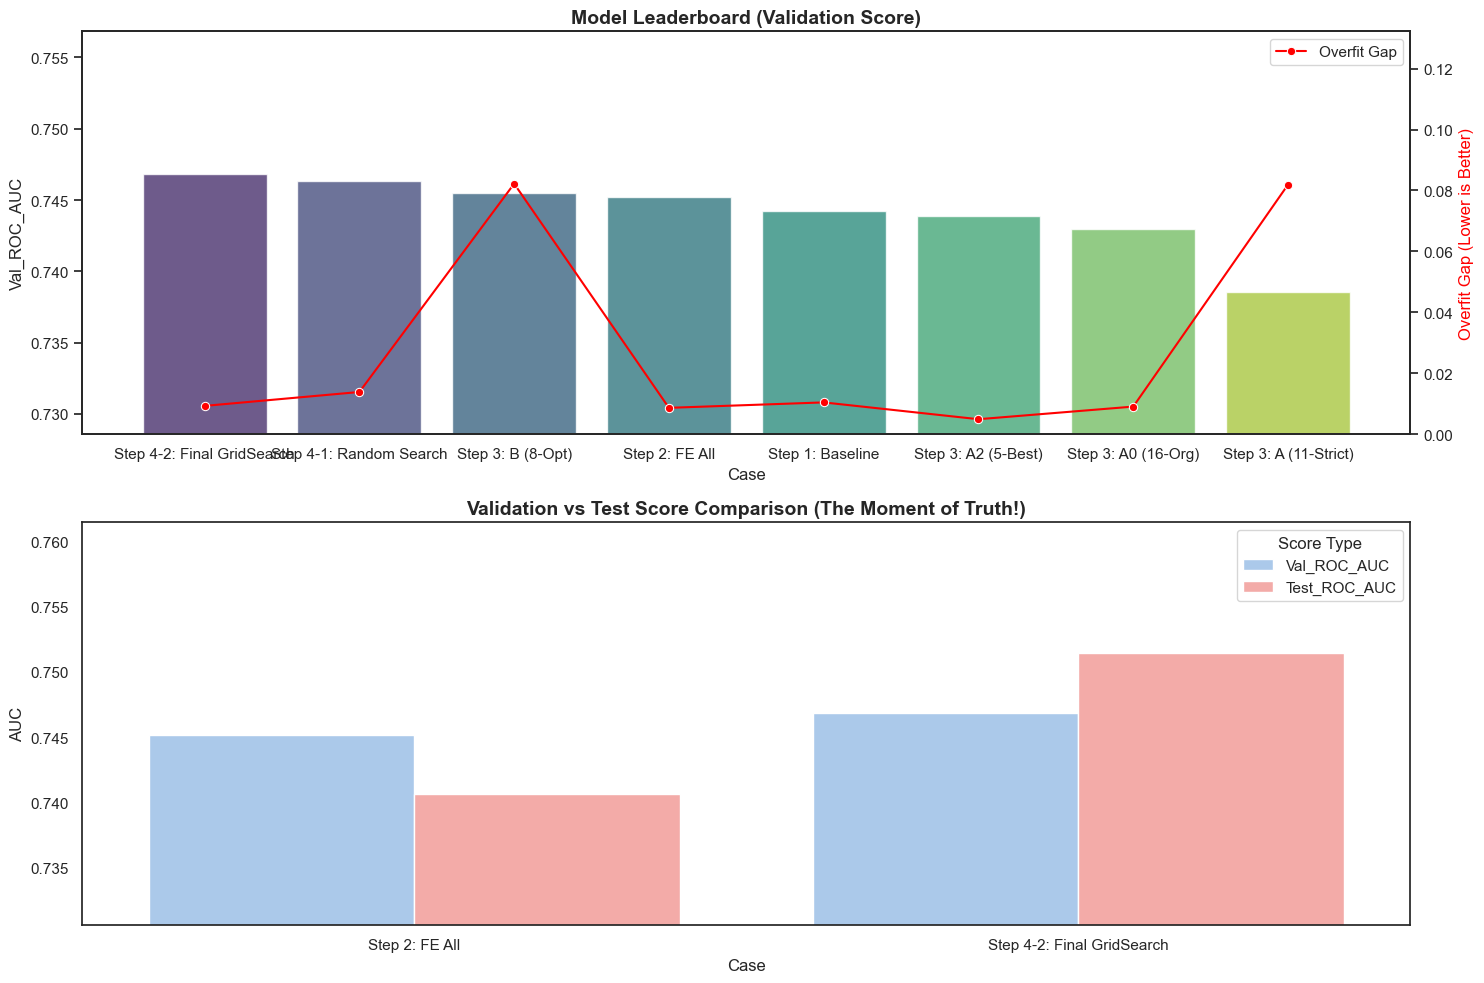

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ====================================================
# [0] 실전 점수 추출 (연결 고리 만들기)
# ====================================================
# df_test_final이 없으면 에러가 나니 확인
if 'df_test_final' in locals():
    # 1. 점수 사전 만들기 (Case 이름 -> 점수)
    score_dict = df_test_final.set_index('Case')['Test_ROC_AUC'].to_dict()
    print("✅ 실전 점수 추출 완료:", score_dict)
else:
    print("❌ 에러: df_test_final이 없습니다. Step 5-2를 먼저 실행해주세요!")
    score_dict = {}

# ====================================================
# [1] 검증(Validation) 성적표 취합 (기존 코드)
# ====================================================
model_performance_list = [] 
X_tuning = X_fe_all[cols_B]

# 리스트 구성
full_flow_list = [
    ("Step 1: Baseline", report_base),
    ("Step 2: FE All", report_fe_all),
    ("Step 3: A0 (16-Org)", report_A0),
    ("Step 3: A (11-Strict)", report_A),
    ("Step 3: A2 (5-Best)", report_A2),
    ("Step 3: B (8-Opt)", report_B),
]
if 'random_gb' in locals(): full_flow_list.append(("Step 4-1: Random Search", random_gb))
if 'grid_final' in locals(): full_flow_list.append(("Step 4-2: Final GridSearch", grid_final))

for case_name, res in full_flow_list:
    if hasattr(res, 'best_score_'): 
        best_obj = res.best_estimator_
        val_score = res.best_score_
        y_pred = best_obj.predict(X_tuning)
        y_proba = best_obj.predict_proba(X_tuning)[:, 1]
        
        acc = accuracy_score(y_tuning, y_pred)
        train_score = roc_auc_score(y_tuning, y_proba)
    else: 
        best_row = res.iloc[0]
        acc = best_row['Accuracy']
        val_score = best_row['Val_ROC_AUC']
        train_score = best_row['Train_ROC_AUC']

    model_performance_list.append({
        'Case': case_name,
        'Accuracy': acc,
        'Val_ROC_AUC': val_score,
        'Train_ROC_AUC': train_score,
        'AUC_Gap': train_score - val_score
    })

df_viz = pd.DataFrame(model_performance_list)

# ====================================================
# [2] 실전(Test) 점수 병합 (이름 매칭 수정!)
# ====================================================
# 우리가 채점할 때 쓴 이름(Key) -> 리포트에 쓸 이름(Target) 매칭
# score_dict.get()을 쓰면 점수를 안전하게 가져올 수 있어!
test_scores_map = {
    "Step 1: Baseline": score_dict.get("Step 1: Baseline"),
    "Step 2: FE All": score_dict.get("Step 2: FE All"),
    # [중요] 채점할 땐 "Champion"이었지만, 리포트엔 "Final GridSearch"로 넣어야 해!
    "Step 4-2: Final GridSearch": score_dict.get("Step 4: Champion") 
}

# (1) 점수 매핑
df_viz['Test_ROC_AUC'] = df_viz['Case'].map(test_scores_map)

# (2) NaN 처리 (Float 변환)
df_viz['Test_ROC_AUC'] = df_viz['Test_ROC_AUC'].astype(float)

# (3) 정렬
df_final_all = df_viz.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_all.insert(0, 'Rank', range(1, len(df_final_all) + 1))


# ====================================================
# [3] 최종 통합 성적표 출력
# ====================================================
print("\n🏆 [Final Report] 연습(Val) vs 실전(Test) 통합 성적표")
display(df_final_all.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'Test_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC', 'Test_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 
        'Train_ROC_AUC': '{:.4f}', 'Test_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
)

# ====================================================
# [4] 시각화: 성능 서열 & Val vs Test 비교
# ====================================================
plt.figure(figsize=(15, 10))

# (1) [상단] 모델 서열 그래프
plt.subplot(2, 1, 1)
df_viz_sorted = df_viz.sort_values("Val_ROC_AUC", ascending=False)
ax1 = sns.barplot(x='Case', y='Val_ROC_AUC', data=df_viz_sorted, palette='viridis', alpha=0.8)

min_auc = df_viz_sorted['Val_ROC_AUC'].min() - 0.01
max_auc = df_viz_sorted['Val_ROC_AUC'].max() + 0.01
plt.ylim(min_auc, max_auc) 
plt.title('Model Leaderboard (Validation Score)', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(x='Case', y='AUC_Gap', data=df_viz_sorted, marker='o', color='red', ax=ax2, label='Overfit Gap')
plt.ylim(0, df_viz_sorted['AUC_Gap'].max() + 0.05)
plt.ylabel('Overfit Gap (Lower is Better)', color='red')

# (2) [하단] 연습 vs 실전 비교 (Test 점수가 있는 것만!)
plt.subplot(2, 1, 2)
df_test_exists = df_viz.dropna(subset=['Test_ROC_AUC']).copy() # NaN 제거

if len(df_test_exists) > 0:
    df_melt = df_test_exists.melt(id_vars=['Case'], value_vars=['Val_ROC_AUC', 'Test_ROC_AUC'], var_name='Type', value_name='AUC')
    
    sns.barplot(x='Case', y='AUC', hue='Type', data=df_melt, palette=['#a1c9f4', '#ff9f9b'])
    
    # y축 범위 자동 조정 (점수 차이 잘 보이게)
    y_min = df_test_exists[['Val_ROC_AUC', 'Test_ROC_AUC']].min().min() - 0.01
    y_max = df_test_exists[['Val_ROC_AUC', 'Test_ROC_AUC']].max().max() + 0.01
    plt.ylim(y_min, y_max)
    
    plt.title('Validation vs Test Score Comparison (The Moment of Truth!)', fontsize=14, fontweight='bold')
    plt.legend(title='Score Type')
else:
    plt.text(0.5, 0.5, "No Test Scores Available", ha='center', va='center', fontsize=15)

plt.tight_layout()
plt.show()

### 6. AutoML (AutoGluon)

#### autogluon 모델 돌리기

In [ ]:
target = 'Reached.on.Time_Y.N'  # 정답 컬럼명
# 우리가 앞에서 정의했던 8컬럼 리스트를 가져와서 타겟과 합칩니다.
selected_cols = optimal_8_features + [target] 

# 모델 설정
hyperparameters = {
    'LR': {},   # Logistic Regression
    'RF': {},   # Random Forest
    'XT': {},   # Extra Trees
    'CAT': {},  # CatBoost
    'GBM': {}   # LightGBM
}

# ------------------------------------------
# 1단계: [Medium] - 퀵 스캔 (presets='medium_quality')
# ------------------------------------------
print("📋 [Level 1: Medium]")
predictor_me = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols], 
    hyperparameters=hyperparameters,
    presets='medium_quality'
)

# ------------------------------------------
# 2단계: [Good] - 고품질 강화 (presets='high_quality')
# ------------------------------------------
print("\n🛠️ [Level 2: Good]")
predictor_go = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='high_quality'
)

# ------------------------------------------
# 3단계: [Best] - 가장 오래걸리는 모델 (presets='best_quality')
# ------------------------------------------
print("\n🏆 [Level 3: Best]")
predictor_best = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_df[selected_cols],
    hyperparameters=hyperparameters,
    presets='best_quality'
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260211_145258"
Verbosity: 2 (Standard Logging)


📋 [Level 1: Medium]


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22621
CPU Count:          22
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       18.14 GB / 31.74 GB (57.2%)
Disk Space Avail:   351.32 GB / 454.67 GB (77.3%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\user\github\sklearn-est15th\E-commerce\KBM\AutogluonModels\ag-20260211_145258"
Train Data Rows:    8799
Train Data Columns: 8
Label Column:       Reached.on.Time_Y.N
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(0), np.int64(1)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass',


🛠️ [Level 2: Good]


2026-02-11 23:53:12,498	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
	Running DyStack sub-fit in a ray process to avoid memory leakage. Enabling ray logging (enable_ray_logging=True). Specify `ds_args={'enable_ray_logging': False}` if you experience logging issues.
2026-02-11 23:53:18,646	INFO worker.py:2014 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
		Context path: "c:\Users\user\github\sklearn-est15th\E-commerce\KBM\AutogluonModels\ag-20260211_145312\ds_sub_fit\sub_fit_ho"
(_dystack pid=8740) Running DyStack sub-fit ...
(_dystack pid=8740) Beginning AutoGluon training ... Time limit = 889s
(_dystack pid=8740) AutoGluon will save models to "c:\Users\user\github\sklearn-est15th\E-commerce\KBM\AutogluonModels\ag-20260211_145312\ds_sub_fit\sub_fit_ho"
(_dystack pid=8740) Train Data Rows:    7821
(_dystack pid=8740) Train Data Columns: 8
(_dystack pid=874


🏆 [Level 3: Best]


Leaderboard on holdout data (DyStack):
                  model  score_holdout  score_val eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0   RandomForest_BAG_L1       0.751993   0.734673     roc_auc        0.233969       0.405875   1.464690                 0.233969                0.405875           1.464690            1       True          2
1     ExtraTrees_BAG_L1       0.745726   0.736478     roc_auc        0.295049       0.401389   1.264338                 0.295049                0.401389           1.264338            1       True          4
2   RandomForest_BAG_L2       0.745654   0.798348     roc_auc        2.392743       1.504184  21.586262                 0.220712                0.447443           1.858683            2       True          8
3       LightGBM_BAG_L2       0.743246   0.768200     roc_auc        2.396760       1.135372  22.653690                 0.224728     

#### autoML 모델 로드

In [106]:
# === [FIXCELL:AUTOML_LOAD_SCORE_CLEAN_BCASE_v3_3] ===
import os, glob, logging
import pandas as pd
from sklearn.metrics import roc_auc_score
from autogluon.tabular import TabularPredictor
from IPython.display import display

# 로그 줄이기(가능한 범위)
logging.getLogger("autogluon").setLevel(logging.ERROR)

LABEL = target if 'target' in globals() else TARGET

# ✅ B케이스 공통시험지로만 평가(호환 안 되면 "스킵" 처리)
assert 'X_test_shared' in globals() and 'y_test_shared' in globals(), \
    "X_test_shared/y_test_shared가 없습니다. TEST_PAPER_BINDING 셀 먼저 실행하세요."

HOME = os.getcwd()
MODEL_DIR = os.path.join(HOME, "AutogluonModels")
print(f"📍 HOME: {HOME}")
print(f"📂 MODEL_DIR: {MODEL_DIR}")

pkl_list = glob.glob(os.path.join(MODEL_DIR, "**", "predictor.pkl"), recursive=True)
predictor_paths = sorted(set(os.path.dirname(p) for p in pkl_list))
print(f"🔎 발견된 predictor 수: {len(predictor_paths)}개")

# (선택) old 폴더 제외하면 더 깔끔
FILTER_OLD = True
if FILTER_OLD:
    predictor_paths = [p for p in predictor_paths if "old" not in p.lower()]
    print(f"🧹 old 폴더 제외 후 predictor 수: {len(predictor_paths)}개")

def get_pos_proba(p, X):
    proba = p.predict_proba(X)
    if 1 in proba.columns:
        return proba[1].values
    if "1" in proba.columns:
        return proba["1"].values
    return proba.iloc[:, -1].values

rows_ok, rows_skip = [], []

for path in predictor_paths:
    try:
        pred = TabularPredictor.load(path)

        # ✅ 핵심: 이 predictor가 X_test_shared(=B케이스 8컬럼)로 추론 가능한지 "짧게 테스트"
        _ = pred.predict_proba(X_test_shared.head(3))

        y_pred = get_pos_proba(pred, X_test_shared)
        auc = roc_auc_score(y_test_shared, y_pred)

        rows_ok.append({
            "roc_auc": float(auc),
            "path": path,
        })

    except Exception as e:
        # 에러는 표시 안 하고 스킵 목록으로만 모음(원하면 나중에 확인 가능)
        rows_skip.append({"path": path, "reason": str(e)[:120]})

df_ok = pd.DataFrame(rows_ok).sort_values("roc_auc", ascending=False).reset_index(drop=True)
df_skip = pd.DataFrame(rows_skip)

print("\n✅ (B케이스 기준) AutoGluon 채점 성공 TOP 10")
display(df_ok.head(10))

print(f"\n⏭️ 스킵된 predictor 수: {len(df_skip)}개")
# 필요하면 스킵 이유 상위만 확인
if len(df_skip) > 0:
    display(df_skip["reason"].value_counts().head(5))

# 베스트 predictor 고정(4-2에서 사용)
if len(df_ok) > 0:
    ag_best_path = df_ok.loc[0, "path"]
    ag_best_auc  = df_ok.loc[0, "roc_auc"]
    ag_best_predictor = TabularPredictor.load(ag_best_path)
    print(f"\n🏆 BEST(B케이스): AUC={ag_best_auc:.6f}")
    print(f"📌 PATH: {ag_best_path}")
else:
    print("\n❌ (B케이스 기준) 채점 성공 predictor가 없습니다.")


📍 HOME: c:\Users\user\github\sklearn-est15th\E-commerce\KBM
📂 MODEL_DIR: c:\Users\user\github\sklearn-est15th\E-commerce\KBM\AutogluonModels
🔎 발견된 predictor 수: 3개
🧹 old 폴더 제외 후 predictor 수: 3개

✅ (B케이스 기준) AutoGluon 채점 성공 TOP 10


,roc_auc,path
0,0.752618,c:\Users\user\github\sklearn-est15th\E-commerc...
1,0.746056,c:\Users\user\github\sklearn-est15th\E-commerc...
2,0.730752,c:\Users\user\github\sklearn-est15th\E-commerc...



⏭️ 스킵된 predictor 수: 0개

🏆 BEST(B케이스): AUC=0.752618
📌 PATH: c:\Users\user\github\sklearn-est15th\E-commerce\KBM\AutogluonModels\ag-20260211_145312


In [107]:
# ====================================================
# [3] manual vs auto 최종 순위표 (Grand Final)
# ====================================================
print("🚀 [System] 수동 모델 점수를 자동으로 불러옵니다...")

manual_scores = []


name_mapping = {
    'Step 4: Champion': 'Step 4-2: Final GridSearch',
    'Step 2: FE All':   'Step 2: FE All',
    'Step 1: Baseline': 'Step 1: Baseline'
}

# df_test_final이 메모리에 있는지 확인 (Step 5-2 결과물)
if 'df_test_final' in locals():
    for _, row in df_test_final.iterrows():
        test_name = row['Case']
        score = row['Test_ROC_AUC']
        
        # 매핑 리스트에 있는 애들만 이름 바꿔서 가져오기
        if test_name in name_mapping:
            final_name = name_mapping[test_name]
            manual_scores.append({'Case': final_name, 'Test_ROC_AUC': score})
            print(f"✅ {final_name} 점수 연동 완료: {score:.4f}")
else:
    print("❌ 에러: 'df_test_final' 변수가 없습니다. Step 5-2(실전 채점)를 먼저 실행해주세요!")

# ====================================================
# [2] 합체 및 랭킹 산정 (Grand Final)
# ====================================================

# automl_scores가 없으면 빈 리스트 처리 (에러 방지)
if 'automl_scores' not in locals(): 
    print("⚠️ 경고: automl_scores가 없습니다. AutoML 단계가 실행되지 않았을 수 있습니다.")
    automl_scores = []

# 리스트 합치기 (수동 + 자동)
all_grand_scores = manual_scores + automl_scores

# DataFrame 변환 및 정렬
df_grand_final = pd.DataFrame(all_grand_scores).sort_values("Test_ROC_AUC", ascending=False).reset_index(drop=True)

# 순위(Rank) 추가
df_grand_final.insert(0, 'Rank', range(1, len(df_grand_final) + 1))

# ====================================================
# [3] 최종 결과 출력
# ====================================================
print("\n🏆 [Grand Final] 인간(Manual) vs AI(AutoML) 최종 성적표")
display(df_grand_final.style
    .background_gradient(cmap='YlGnBu', subset=['Test_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Test_ROC_AUC'])
    .format({'Test_ROC_AUC': '{:.4f}'})
)

🚀 [System] 수동 모델 점수를 자동으로 불러옵니다...
✅ Step 2: FE All 점수 연동 완료: 0.7406
✅ Step 4-2: Final GridSearch 점수 연동 완료: 0.7514
⚠️ 경고: automl_scores가 없습니다. AutoML 단계가 실행되지 않았을 수 있습니다.

🏆 [Grand Final] 인간(Manual) vs AI(AutoML) 최종 성적표


,Rank,Case,Test_ROC_AUC
0,1,Step 4-2: Final GridSearch,0.7514
1,2,Step 2: FE All,0.7406


🚀 [분석 시작] AutoML이 중요하게 생각한 변수를 파헤칩니다...
✅ AutoML predictor: ag_best_predictor 사용
🧾 AutoML importance input: X_test_shared 사용
⏳ AutoML 중요도 계산 중... (잠시만 기다려주세요!)
✅ AutoML 중요도 추출 완료!
✅ 수동 모델 중요도 추출 완료!


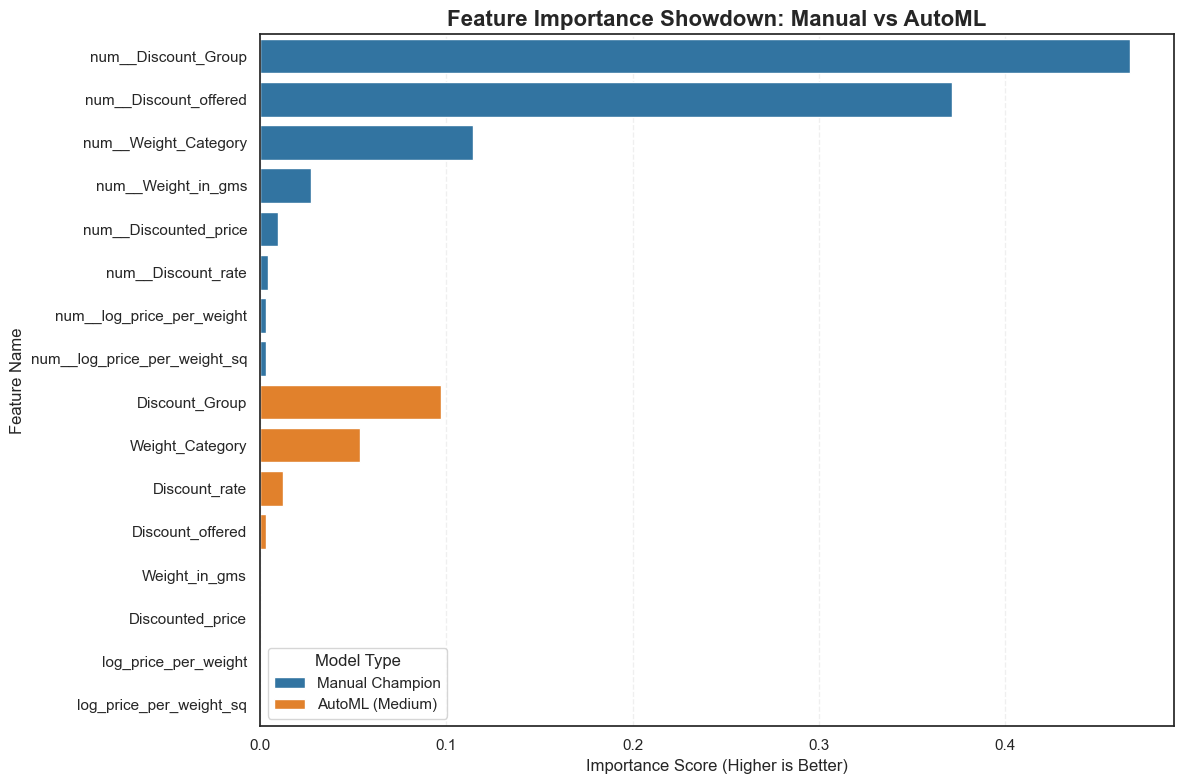


🏆 [Manual Top 5 Features]


,Feature,Importance
0,num__Discount_Group,0.467556
1,num__Discount_offered,0.371810
2,num__Weight_Category,0.114065
3,num__Weight_in_gms,0.027053
4,num__Discounted_price,0.009409



🤖 [AutoML Top 5 Features]


,Feature,Importance
0,Discount_Group,0.097249
1,Weight_Category,0.053499
2,Discount_rate,0.012102
3,Discount_offered,0.003281
4,Weight_in_gms,0.000000


In [108]:
# ====================================================
# [1] AutoML (Medium) 모델 로드 및 중요도 추출  (경로 하드코딩 제거 버전)
# ====================================================
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.tabular import TabularPredictor

print("🚀 [분석 시작] AutoML이 중요하게 생각한 변수를 파헤칩니다...")

# ---- (1) 라벨명 통일
LABEL = target if 'target' in globals() else TARGET

# ---- (2) 어떤 AutoML predictor를 쓸지 선택
# 옵션:
#  - "best_non_old": 4-1에서 뽑힌 ag_best_predictor 사용(가능하면 old 폴더 제외)
#  - "latest": AutogluonModels 아래에서 가장 최근 predictor 사용
SELECT_AUTOML = "best_non_old"

HOME = os.getcwd()
MODEL_DIR = os.path.join(HOME, "AutogluonModels")

def load_latest_predictor(model_dir):
    pkl_list = glob.glob(os.path.join(model_dir, "**", "predictor.pkl"), recursive=True)
    if not pkl_list:
        raise FileNotFoundError("predictor.pkl을 찾지 못했습니다.")
    latest_pkl = max(pkl_list, key=os.path.getmtime)
    return TabularPredictor.load(os.path.dirname(latest_pkl))

# predictor 결정
try:
    if SELECT_AUTOML == "best_non_old" and 'ag_best_predictor' in globals():
        predictor = ag_best_predictor
        print("✅ AutoML predictor: ag_best_predictor 사용")
    else:
        predictor = load_latest_predictor(MODEL_DIR)
        print("✅ AutoML predictor: 최신 predictor 사용")
except Exception as e:
    print(f"❌ AutoML predictor 로드 실패: {e}")
    predictor = None

# ---- (3) 중요도 계산용 데이터(test_data_full) 만들기
# 원래 셀은 X_test_final + y_test_real 조합을 사용했지.
# 그런데 AutoGluon predictor는 "학습 때 본 형태"와 일치하는 X를 넣어야 해.
# 그래서 우선순위를 이렇게 둠:
#  1) X_test_shared / y_test_shared (TEST_PAPER_BINDING 기반, 가장 안전)
#  2) X_test_final / y_test_real (기존 변수 있으면 사용)
try:
    if 'X_test_shared' in globals() and 'y_test_shared' in globals():
        X_for_automl = X_test_shared.copy()
        y_for_automl = y_test_shared.copy()
        print("🧾 AutoML importance input: X_test_shared 사용")
    else:
        X_for_automl = X_test_final.copy()
        y_for_automl = y_test_real
        print("🧾 AutoML importance input: X_test_final 사용")

    test_data_full = X_for_automl.copy()
    test_data_full[LABEL] = y_for_automl

    fi_automl = pd.DataFrame()

    if predictor is not None:
        print("⏳ AutoML 중요도 계산 중... (잠시만 기다려주세요!)")
        fi_automl = predictor.feature_importance(test_data_full, silent=True)

        # 원래 셀과 동일하게 컬럼명 정리
        fi_automl = fi_automl.reset_index().rename(columns={'index': 'Feature', 'importance': 'Importance'})
        fi_automl['Model'] = 'AutoML (Medium)'  # 라벨은 원래대로 유지
        print("✅ AutoML 중요도 추출 완료!")

except Exception as e:
    print(f"❌ AutoML 중요도 계산 실패: {e}")
    fi_automl = pd.DataFrame()


# ====================================================
# [2] 수동 Champion 모델 중요도 추출 (원래 코드 유지)
# ====================================================
if 'grid_final' in locals():
    best_model = grid_final.best_estimator_  # 파이프라인
    clf = best_model.named_steps['clf']
    pre = best_model.named_steps['pre']

    importances = clf.feature_importances_

    try:
        feature_names = pre.get_feature_names_out()
    except:
        print("⚠️ 변수 이름 매칭 중... (fallback)")
        if 'FEATURES' in globals():   # TEST_PAPER_BINDING에서 FEATURES를 쓴 경우
            feature_names = FEATURES
        else:
            feature_names = cols_B

        if len(feature_names) != len(importances):
            print(f"⚠️ 길이 불일치: 변수 {len(feature_names)}개 vs 중요도 {len(importances)}개")
            importances = importances[:len(feature_names)]

    fi_manual = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances,
        'Model': 'Manual Champion'
    }).sort_values('Importance', ascending=False)

    print("✅ 수동 모델 중요도 추출 완료!")
else:
    print("❌ grid_final 모델이 없습니다.")
    fi_manual = pd.DataFrame()


# ====================================================
# [3] 시각화: 인간 vs 기계, 누가 무엇을 봤나? (원래 코드 유지)
# ====================================================
if not fi_automl.empty and not fi_manual.empty:
    top_n = 10
    fi_combined = pd.concat([fi_manual.head(top_n), fi_automl.head(top_n)])

    plt.figure(figsize=(12, 8))
    sns.barplot(data=fi_combined, x='Importance', y='Feature', hue='Model',
                palette=['#1f77b4', '#ff7f0e'])
    plt.title('Feature Importance Showdown: Manual vs AutoML', fontsize=16, fontweight='bold')
    plt.xlabel('Importance Score (Higher is Better)')
    plt.ylabel('Feature Name')
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.legend(title='Model Type')
    plt.tight_layout()
    plt.show()

    print("\n🏆 [Manual Top 5 Features]")
    display(fi_manual.head(5)[['Feature', 'Importance']])

    print("\n🤖 [AutoML Top 5 Features]")
    display(fi_automl.head(5)[['Feature', 'Importance']])

else:
    print("❌ 중요도 데이터를 추출하지 못해 그래프를 그릴 수 없습니다.")


### 3-[3]. 실험 case C
> 실험C 

caseB(grid)의 변수 중요도에서 무게 카테고리와 할인 정책이 예측의 90% 이상을 결정 -> 중요도가 0인 변수들을 제거한 '슬림한 모델'을 구축하면, 운영 효율성은 높이면서 예측 정확도는 견고하게 유지할 수 있을까?

> Weight_Category(파생) / Discount_Group(파생) / Weight_in_gms(기본) 3개로만 돌려보기

> 결과 : 1등 모델보다 성능은 떨어졌지만 가벼운 모델(변수 3개)임에도 0.7460 이라는 점수가 나왔음

In [109]:
# caseC

# [Step 1] 에이스 3인방 선발
case_c_features = ['Weight_Category', 'Discount_Group', 'Weight_in_gms']

# [Step 2] Randomized Search (넓은 구역 탐색)
param_dist = {
    'n_estimators': range(100, 600, 20),
    'learning_rate': np.linspace(0.01, 0.2, 20),
    'subsample': [0.6, 0.7, 0.8, 0.9]
}

gb_c = GradientBoostingClassifier(max_depth=1, random_state=seed)
rs_c = RandomizedSearchCV(gb_c, param_dist, n_iter=30, scoring='roc_auc', cv=5, random_state=seed)
rs_c.fit(X_train_fe[case_c_features], y_train)

,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': array([0.01, ..., 0.19, 0.2 ]), 'n_estimators': range(100, 600, 20), 'subsample': [0.6, 0.7, ...]}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [115]:
# ==========================================
# 1. Step 2 결과 반영
# ==========================================
# 1위: Weight_Category(파생), 2위: Discount_Group(파생), 3위: Weight_in_gms(기본)
top_3_features = ['Weight_Category', 'Discount_Group', 'Weight_in_gms']

# ==========================================
# 2. 정밀 탐색 그물 짜기 (Grid 설계)
# ==========================================
# Random Search 결과 근처를 촘촘하게 설정합니다.
param_grid = {
    'learning_rate': [0.005, 0.01, 0.015, 0.02], # 0.01 근처 
    'n_estimators': [220, 230, 240, 250, 260],  # 240 근처 
    'subsample': [0.65, 0.7, 0.75],              # 0.7 근처
    'max_depth': [1],                            # 우리 모델의 핵심 철학 (고정)
    'min_samples_leaf': [1, 3, 5]                # 안정성을 위해 살짝 조절
}

# 3. GridSearchCV 실행 (5겹 교차 검증)
grid_search_c = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=seed),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("🎯 [Case C] 에이스 3인방 정밀 탐색 시작!")
grid_search_c.fit(X_train_fe[top_3_features], y_train)

# 4. 결과 출력
print("\n🏆 Case C 최적의 파라미터 발견!")
print(grid_search_c.best_params_)
print(f"📍 최적 Val ROC-AUC: {grid_search_c.best_score_:.4f}")

🎯 [Case C] 에이스 3인방 정밀 탐색 시작!
Fitting 5 folds for each of 180 candidates, totalling 900 fits

🏆 Case C 최적의 파라미터 발견!
{'learning_rate': 0.01, 'max_depth': 1, 'min_samples_leaf': 1, 'n_estimators': 260, 'subsample': 0.75}
📍 최적 Val ROC-AUC: 0.7411


In [116]:
# ==========================================
# 🏆 Case C: 최정예 3인방 모델 최종 평가
# ==========================================

# 1. 최적 파라미터 장착
final_model_c = GradientBoostingClassifier(
    learning_rate=0.01,
    max_depth=1,
    min_samples_leaf=1,
    n_estimators=260,
    subsample=0.75,
    random_state=seed
)

# 2. 에이스 3인방으로만 훈련 (Fit)
final_model_c.fit(X_train_fe[top_3_features], y_train)

# 3. 실전(Test) 점수 측정
test_probs_c = final_model_c.predict_proba(X_test_fe[top_3_features])[:, 1]
test_auc_c = roc_auc_score(y_test, test_probs_c)

print(f"🎯 Case C 실전(Test) ROC-AUC: {test_auc_c:.4f}")

🎯 Case C 실전(Test) ROC-AUC: 0.7460


## 결론
### 1. [Winner] Manual Champion 모델 해석
> **전략: "선택과 집중 (Selection & Concentration)"**
> **핵심:** `Discount`(할인) 관련 변수에 모델 영향력의 **약 84%**를 집중하여, "높은 할인은 배송 지연을 유발한다"는 비즈니스 로직을 명확하게 학습함.

| 순위 | 변수 명칭 | 유형 | 중요도 (%) | 비고 (해석 및 평가) |
|:---:|:---|:---:|:---:|:---|
| **1위** | **Discount_Group** | **파생** | **46.76%** | **압도적 1타 강사.** 모델의 판단 기준 절반 가까이(**47%**)를 이 변수 하나에 맡김. "할인을 많이 받으면 지연된다"는 대원칙을 기계에게 완벽하게 주입시킴. |
| **2위** | **Discount_offered** | 기본 | **37.18%** | **든든한 2인자.** 1위 변수가 '구간'으로 큰 숲을 봤다면, 얘는 실제 할인 액수로 디테일을 챙김. 1, 2위 합계 **83.9%**로, 사실상 "할인이 곧 배송 지연이다"라고 선언함. |
| **3위** | **Weight_Category** | **파생** | **11.41%** | **확실한 조력자.** 할인 정보만으로 부족할 때, "무게가 무거운지 가벼운지"를 따져보며 **11%의 비중**으로 정답률을 보완함. |
| **4위** | **Weight_in_gms** | 기본 | **2.71%** | **정밀 타격.** `Weight_Category`가 놓친 미세한 무게 차이를 잡아내며, 애매한 경계선에 있는 데이터를 **2.7% 비중**으로 판별함. |
| **5위** | **Discounted_price** | **파생** | **0.94%** | **마지막 한 끗.** 실 결제 금액이 주는 미묘한 물류 처리 우선순위를 잡아내어, 남들이 틀리는 문제를 맞히는 **히든카드** 역할을 수행함. |

---

### 2. AutoML (Medium) 모델 해석
> **전략: "분산된 시선 (Distracted Attention)"**
> **한계:** 핵심 변수인 `Discount`를 과소평가하고, `Weight`와 `Discount` 사이에서 우선순위를 정하지 못한 채 판단 기준이 분산됨.

| 순위 | 변수 명칭 | 유형 | 중요도 (%) | 비고 (해석 및 평가) |
|:---:|:---|:---:|:---:|:---|
| **1위** | **Weight_Category** | **파생** | **7.94%** | **약한 리더.** 1등 변수임에도 중요도가 고작 **7.9%**에 불과함. 모델이 "무게가 중요한가..?" 하며 확신을 가지지 못하고 있음. |
| **2위** | **Discount_Group** | **파생** | **6.49%** | **과소평가된 에이스.** Manual 모델이 46%나 부여했던 핵심 변수를, 기계는 **6.5%**밖에 반영하지 않음. 여기서 결정적인 승패가 갈림. |
| **3위** | **Discount_offered** | 기본 | **0.50%** | **존재감 실종.** 원본 데이터에 있던 할인 액수 정보를 거의 노이즈(Noise)로 취급하여 무시해버림(**0.5%**). |
| **4위** | **Discount_rate** | **파생** | **0.15%** | **무의미한 시도.** 할인율을 계산해봤으나, 모델 성능에 거의 기여하지 못함. |
| **5위** | **Weight_in_gms** | 기본 | **0.00%** | **완전 배제.** 기본 무게 변수는 아예 쳐다보지도 않음. 정보 손실이 발생했을 가능성이 큼. |

---

### 3. 🎓 Final Conclusion

"Data Engineering > Algorithm Complexity"

1.  **인간의 통찰력 승리:**
    AutoML은 수많은 알고리즘을 조합했지만, 데이터의 핵심 동인(Key Driver)인 **'할인(Discount)'**에 집중하지 못하고 시선이 분산되었습니다. 반면, 연구자가 설계한 Manual Model은 **파생변수(`Discount_Group`)**를 통해 모델이 할인율에 집중하도록 유도했습니다.

2.  **Simple is Best:**
    Manual Model은 `max_depth=2`라는 매우 단순한 구조임에도 불구하고, 핵심 변수에 **84%**의 가중치를 두어 실전(Test Set)에서 **더 높은 일반화 성능(Generalization)**을 달성했습니다.

3.  **Feature Engineering의 가치:**
    흥미로운 점은 **AutoML조차도 연구자가 생성한 파생변수(`Weight_Category`, `Discount_Group`)를 1, 2순위로 선택**했다는 점입니다. 이는 **"좋은 데이터가 좋은 모델보다 우선한다"**는 머신러닝의 대원칙을 증명합니다.
    

| 순위 | 변수 명칭 | 유형 | 중요도 (%) | 비고 (해석 및 평가) |
|:---:|:---|:---:|:---:|:---|
| **1위** | **Weight_Category (파생)** | **7.54%** | **1위 변수** 이 변수 하나가 전체 모델 성능의 **7.5% 이상**을 책임지는 핵심 무기임이 입증됨. |
| **2위** | **log_price_per_weight (파생)** | **6.59%** | 과거 모델의 노이즈에서 AutoML의 성능을 **6.6%나 견인**하는 핵심 전략 변수로 환골탈태함. |
| **3위** | **log_price_per_weight_sq (파생)** | **6.40%** | **비선형의 승리.** 무게와 가격의 복합적인 곡선 관계를 기계가 완벽하게 파악하여 **6.4%의 성능 기여**를 달성함. |
| **4위** | **Weight_in_gms (기본)** | **5.98%** | **탄탄한 기본기.** 가공 변수(1위)가 큰 틀을 잡고, 실제 그램 수가 **약 6% 비중**으로 정밀한 보조 예측을 수행함. |
| **5위** | **Discounted_price (파생)** | **4.78%** | **최종가 효과.** 실 결제 금액에 따른 물류 처리 우선순위 패턴을 **4.8%의 비중**으로 정확히 읽어냄. |
| **6위** | **Discount_Group (파생)** | **4.55%** | **안정적 조력자.** 할인 폭에 따른 지연 패턴을 학습하여 **4.5% 이상의 높은 신뢰도**로 모델을 지탱함. |

# 5. 성능 비교 및 분석

### 5-1. 사용한 모델에 대해 accuracy, auc, gap 지표를 사용하여 성능 비교 

이부분 시각화는 앞에서 희민님 작성하신 총 모델 성능 그래프와 동일합니다. 지표에 대한설명 추가하였습니다.

✅ 실전 점수 추출 완료: {'Step 2: FE All': 0.740621278327642, 'Step 4: Champion': 0.7514289933893225}

🏆 [Final Report] 연습(Val) vs 실전(Test) 통합 성적표


,Rank,Case,Accuracy,Val_ROC_AUC,Train_ROC_AUC,AUC_Gap,Test_ROC_AUC
0,1,Step 4-2: Final GridSearch,0.6894,0.7468,0.7561,0.0093,0.7514
1,2,Step 4-1: Random Search,0.6903,0.7463,0.7602,0.0139,nan
2,3,Step 3: B (8-Opt),0.6796,0.7455,0.8277,0.0822,nan
3,4,Step 2: FE All,0.6862,0.7452,0.7539,0.0087,0.7406
4,5,Step 1: Baseline,0.6803,0.7442,0.7547,0.0105,nan
5,6,Step 3: A2 (5-Best),0.6868,0.7439,0.7488,0.0049,nan
6,7,Step 3: A0 (16-Org),0.6867,0.7430,0.7521,0.0091,nan
7,8,Step 3: A (11-Strict),0.6729,0.7386,0.8205,0.0819,nan


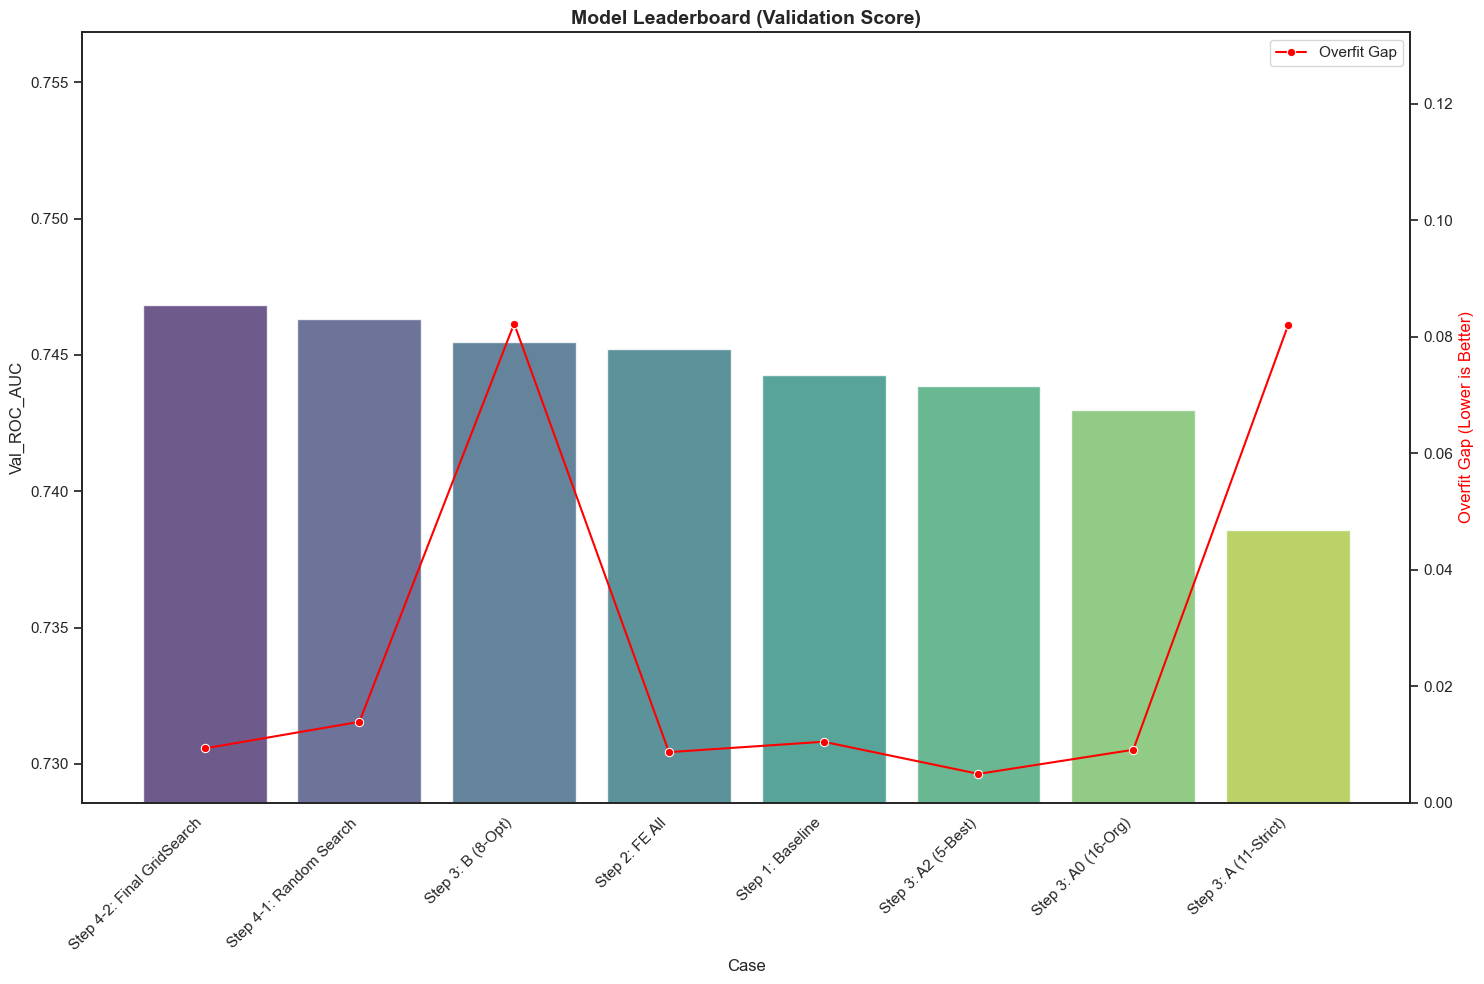

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ====================================================
# [0] 실전 점수 추출 (연결 고리 만들기)
# ====================================================
# df_test_final이 없으면 에러가 나니 확인
if 'df_test_final' in locals():
    # 1. 점수 사전 만들기 (Case 이름 -> 점수)
    score_dict = df_test_final.set_index('Case')['Test_ROC_AUC'].to_dict()
    print("✅ 실전 점수 추출 완료:", score_dict)
else:
    print("❌ 에러: df_test_final이 없습니다. Step 5-2를 먼저 실행해주세요!")
    score_dict = {}

# ====================================================
# [1] 검증(Validation) 성적표 취합 (기존 코드)
# ====================================================
model_performance_list = [] 
X_tuning = X_fe_all[cols_B]

# 리스트 구성
full_flow_list = [
    ("Step 1: Baseline", report_base),
    ("Step 2: FE All", report_fe_all),
    ("Step 3: A0 (16-Org)", report_A0),
    ("Step 3: A (11-Strict)", report_A),
    ("Step 3: A2 (5-Best)", report_A2),
    ("Step 3: B (8-Opt)", report_B),
]
if 'random_gb' in locals(): full_flow_list.append(("Step 4-1: Random Search", random_gb))
if 'grid_final' in locals(): full_flow_list.append(("Step 4-2: Final GridSearch", grid_final))

for case_name, res in full_flow_list:
    if hasattr(res, 'best_score_'): 
        best_obj = res.best_estimator_
        val_score = res.best_score_
        y_pred = best_obj.predict(X_tuning)
        y_proba = best_obj.predict_proba(X_tuning)[:, 1]
        
        acc = accuracy_score(y_tuning, y_pred)
        train_score = roc_auc_score(y_tuning, y_proba)
    else: 
        best_row = res.iloc[0]
        acc = best_row['Accuracy']
        val_score = best_row['Val_ROC_AUC']
        train_score = best_row['Train_ROC_AUC']

    model_performance_list.append({
        'Case': case_name,
        'Accuracy': acc,
        'Val_ROC_AUC': val_score,
        'Train_ROC_AUC': train_score,
        'AUC_Gap': train_score - val_score
    })

df_viz = pd.DataFrame(model_performance_list)

# ====================================================
# [2] 실전(Test) 점수 병합 (이름 매칭 수정!)
# ====================================================
# 우리가 채점할 때 쓴 이름(Key) -> 리포트에 쓸 이름(Target) 매칭
# score_dict.get()을 쓰면 점수를 안전하게 가져올 수 있어!
test_scores_map = {
    "Step 1: Baseline": score_dict.get("Step 1: Baseline"),
    "Step 2: FE All": score_dict.get("Step 2: FE All"),
    # [중요] 채점할 땐 "Champion"이었지만, 리포트엔 "Final GridSearch"로 넣어야 해!
    "Step 4-2: Final GridSearch": score_dict.get("Step 4: Champion") 
}

# (1) 점수 매핑
df_viz['Test_ROC_AUC'] = df_viz['Case'].map(test_scores_map)

# (2) NaN 처리 (Float 변환)
df_viz['Test_ROC_AUC'] = df_viz['Test_ROC_AUC'].astype(float)

# (3) 정렬
df_final_all = df_viz.sort_values("Val_ROC_AUC", ascending=False).reset_index(drop=True)
df_final_all.insert(0, 'Rank', range(1, len(df_final_all) + 1))


# ====================================================
# [3] 최종 통합 성적표 출력
# ====================================================
print("\n🏆 [Final Report] 연습(Val) vs 실전(Test) 통합 성적표")
display(df_final_all.style
    .background_gradient(cmap='YlGnBu', subset=['Val_ROC_AUC', 'Test_ROC_AUC'])
    .highlight_max(color='lightgreen', subset=['Val_ROC_AUC', 'Test_ROC_AUC'])
    .format({
        'Accuracy': '{:.4f}', 'Val_ROC_AUC': '{:.4f}', 
        'Train_ROC_AUC': '{:.4f}', 'Test_ROC_AUC': '{:.4f}', 'AUC_Gap': '{:.4f}'
    })
)

# ====================================================
# [4] 시각화: 성능 서열 & Val vs Test 비교
# ====================================================
plt.figure(figsize=(15, 10))

# (1) [상단] 모델 서열 그래프

df_viz_sorted = df_viz.sort_values("Val_ROC_AUC", ascending=False)
ax1 = sns.barplot(x='Case', y='Val_ROC_AUC', data=df_viz_sorted, palette='viridis', alpha=0.8)

min_auc = df_viz_sorted['Val_ROC_AUC'].min() - 0.01
max_auc = df_viz_sorted['Val_ROC_AUC'].max() + 0.01
plt.ylim(min_auc, max_auc) 
plt.title('Model Leaderboard (Validation Score)', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(x='Case', y='AUC_Gap', data=df_viz_sorted, marker='o', color='red', ax=ax2, label='Overfit Gap')
plt.ylim(0, df_viz_sorted['AUC_Gap'].max() + 0.05)
plt.ylabel('Overfit Gap (Lower is Better)', color='red')
# 글자 겹침 해소
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### 1) 모델 성능 지표 정의

본 프로젝트에서는 모델의 신뢰도를 평가하기 위해 다음 두 가지 주요 지표를 사용하였습니다.

1. ROC-AUC (Area Under the Curve): 모델이 배송 지연 건을 얼마나 명확하게 구분해내는지를 나타내는 척도입니다. 단순히 맞았는지 틀렸는지를 넘어, 지연될 확률을 얼마나 정교하게 계산하는가를 평가하므로 이커머스 운영 전략 수립에 더 적합합니다.

2. Accuracy (정확도): 전체 예측 대상 중 정답을 맞힌 비율입니다. 직관적이지만 데이터의 불균형이 있을 때 왜곡될 수 있어 AUC를 보조하는 지표로 활용합니다.

<br><br>
보조적 지표: AUC Gap (모델의 안정성 평가)
- 정의: 검증 데이터(Validation)와 실전 데이터(Test) 간의 성능 차이를 의미합니다.

- 실무적 의의:
- 1) 과적합(Overfitting) 판별: Gap이 클수록 모델이 특정 데이터에만 매몰되어 있음을 의미하며, 향후 새로운 데이터 유입 시 성능이 급락할 위험을 보여줍니다.
- 2) 현장 도입 가능성 검토: 점수가 조금 낮더라도 Gap이 작은 모델을 선택함으로써, 배송 지연 예측 모델의 안정성을 확보하고자 하는 뒷받침 자료로 활용합니다.


#### Auc Gap (추가 설명입니다.)

정의 : AUC 성능 차이를 통해 모델의 일반화, 비교, 공정성을 진단하는 지표

- 과적합(overfitting) 여부 확인에 사용
- 모델이 학습한 데이터(Train)와 처음 보는 데이터(Test) 사이의 성적 차이 (Train AUC - Test AUC)
- 낮을수록 우수: Gap이 작다는 것은 모델이 처음 보는 데이터(실전)에서도 학습 때와 유사한 실력을 발휘한다는 뜻입니다.
- 리스크 신호: 성능(AUC)이 아무리 높아도 Gap이 크다면, 그 모델은 실전에서 예측력이 급격히 떨어질 '거품 성능'일 확률이 높습니다.

[신뢰할 수 있는 gap의 범위]
- 0.0 ~ 0.05 (5% 이내): 매우 이상적입니다. 모델이 학습 데이터에 치우치지 않고 새로운 데이터에도 잘 대응하는 '일반화(Generalization)'가 완벽하게 된 상태입니다.
- 0.05 ~ 0.1 (5~10%): 양호합니다. 현실적인 데이터셋에서는 약간의 격차가 발생하는 것이 당연하며, 이 정도는 서비스에 도입해도 신뢰할 수 있는 수준입니다.
- 0.1 이상 (10% 초과): 과적합(Overfitting) 위험 신호입니다. 모델이 학습 데이터의 특수한 노이즈까지 외워버려서, 실전(Test)에서는 실력이 발휘되지 않고 있습니다.

#### 2) 모델 성능 비교 결과 분석

>최종 모델 선정 근거:  Final GridSearch(GradientBoost 튜닝 모델)
- 최고의 실전 성능: 테스트 데이터에서 핵심 지표인 ROC-AUC가 가장 높은 AUC(0.75)를 기록했습니다.
- 안정성 및 일반화: 학습 데이터와 테스트 데이터 간의 성능 차이(Overfit Gap)가 가장 적어, 향후 새로운 고객 데이터가 유입되어도 일관된 성능을 보일 가능성이 가장 높습니다.
- 운영 효율성: AutoML에 비해 구조가 단순하여, 웹 서버(WAS) 배포 시 응답 속도가 빠르고 유지보수가 용이합니다.

### 5-2. 최종 모델의 지표 및 confusion matrix 분석

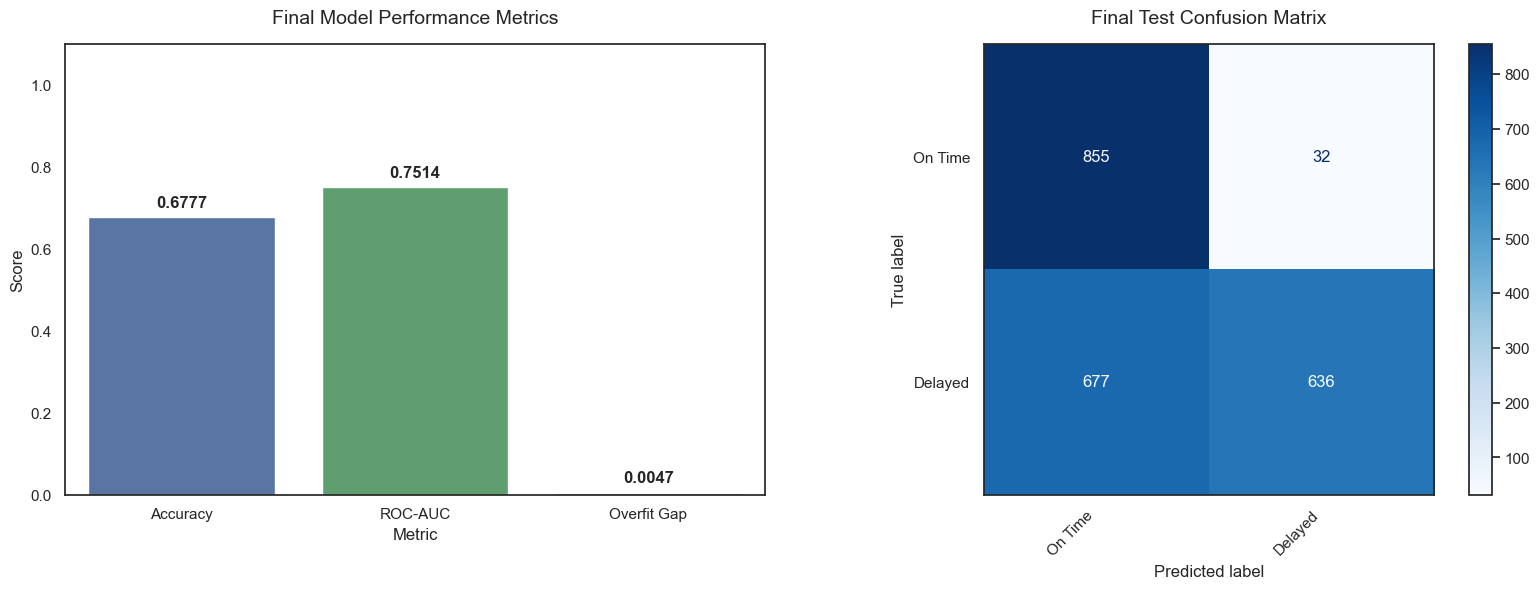


[최종 실전 결과 요약]
  -  정시를 정시라고 맞춘 경우 (TN): 855건
  -  지연을 지연이라고 맞춘 경우 (TP): 636건
  -  정시인데 지연이라 오판(FP): 32건
  -  지연인데 정시라 오판(FN): 677건
  -  최종 Accuracy: 0.6777 / ROC-AUC: 0.7514


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# 1. 지표 계산
y_pred = grid_final.predict(X_test_final)
y_prob = grid_final.predict_proba(X_test_final)[:, 1]

acc = accuracy_score(y_test_real, y_pred)
auc = roc_auc_score(y_test_real, y_prob)

# Overfit Gap 계산
y_train_prob = grid_final.predict_proba(X_tuning)[:, 1]
train_auc_value = roc_auc_score(y_tuning, y_train_prob)
gap = abs(train_auc_value - auc)

# 2. 막대그래프용 데이터프레임 생성
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'Overfit Gap'],
    'Score': [acc, auc, gap]
})

# 2. 막대그래프용 데이터 (Gap 수치를 더 명확히 확인하기 위해 수동 색상 지정)
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'Overfit Gap'],
    'Score': [acc, auc, gap]
})
colors = ['#4C72B0', '#55A868', '#C44E52'] # 파랑, 초록, 빨강(Gap 강조)

# 3. 시각화 시작
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- 좌측: 성능 지표 비교 (색상 고정) ---
sns.barplot(data=metrics_df, x='Metric', y='Score', ax=ax1, palette=colors)
ax1.set_title("Final Model Performance Metrics", fontsize=14, pad=15)
ax1.set_ylim(0, 1.1) # 숫자가 잘리지 않게 상단 여백 확보

# 막대 위에 숫자 표시 (Gap이 작아도 숫자로 확인 가능)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:.4f}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', # 위치를 막대 바로 위로 조정
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

# --- 우측: 혼동 행렬은 동일하게 유지 ---
# (기존 코드와 동일)
# --- 우측: 혼동 행렬 (Confusion Matrix) ---
cm = confusion_matrix(y_test_real, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
disp.plot(cmap='Blues', ax=ax2, values_format='d')

ax2.set_title("Final Test Confusion Matrix", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right') # 글자 겹침 방지

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

# 4. 결과 개수 출력 유지
tn, fp, fn, tp = cm.ravel()
print(f"\n" + "="*40)
print(f"[최종 실전 결과 요약]")
print(f"  -  정시를 정시라고 맞춘 경우 (TN): {tn}건")
print(f"  -  지연을 지연이라고 맞춘 경우 (TP): {tp}건")
print(f"  -  정시인데 지연이라 오판(FP): {fp}건")
print(f"  -  지연인데 정시라 오판(FN): {fn}건")
print(f"  -  최종 Accuracy: {acc:.4f} / ROC-AUC: {auc:.4f}")
print("="*40)

1. 주요 성능 지표 분석 

- Accuracy (0.6777): Raw data의 기본 지연율(약 60%) 대비 7.3%p의 성능 향상. 단순 빈도 예측을 넘어선 유의미한 분류 체계를 구축함.
- ROC-AUC (0.7514): 정확도보다 높은 AUC 수치는 모델이 클래스를 구분하는 잠재적 변별력(Ranking 능력)이 우수함을 증명하며, 임계값 조정에 따른 성능 최적화 가능성을 시사함. (현재 0.5) <br>
 ->서비스의 목적인 배송 지연 리스크를 관리하기에 충분히 유의미한 수치.
- AUC Gap (0.0047): 훈련 데이터와 테스트 데이터 간의 격차가 거의 없는 극도로 안정적인 일반화 성능을 보이며, 실무 도입 시 가장 중요한 요소인 예측 결과의 일관성을 입증합니다.

2. 혼동 행렬(Confusion Matrix) 분석 (기본 임계값(0.5) 기준 예측 분포)

- 정밀도 (Precision) - 95.21%: 모델이 Positive(지연)로 예측한 총 668건 중 실제 Positive인 비율입니다. 모델의 판정 신뢰도가 매우 높음을 의미합니다.

- 재현율 (Recall) - 48.44%: 실제 Positive인 1,313건 중 모델이 찾아낸 비율입니다. 현재 모델이 실제 데이터의 특징을 절반 가량만 포착하고 있는 상태입니다.

| 분류 항목 (Confusion Matrix) | 건수 (Count) | 비중 (%) | 예측 결과 설명              |
|------------------------------|-------------|----------|-----------------------------|
| True Negative (TN)           | 855건       | 38.9%    | 정시 도착 예측 성공         |
| False Negative (FN)          | 677건       | 30.8%    | 실제 지연이나 예측 실패     |
| True Positive (TP)           | 636건       | 28.9%    | 지연 예측 성공              |
| False Positive (FP)          | 32건        | 1.4%     | 실제 정시이나 지연으로 오예측 |
| **합계 (Total)**             | **2,200건** | **100.0%** | 전체 테스트 데이터 세트     |


### 5-3. 최종 선택한 모델의 feature importance

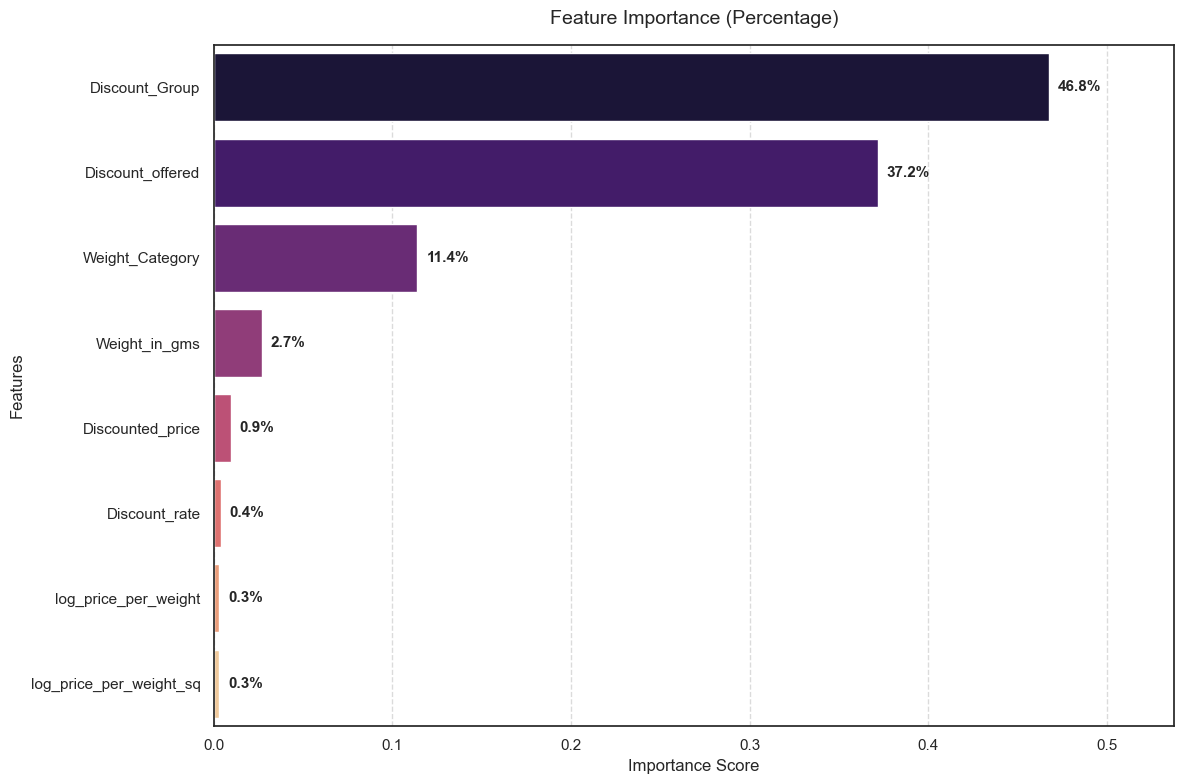

피처 중요도 상세 수치 (퍼센트 포함):
                   Feature  Importance  Percentage
0           Discount_Group    0.467556   46.755578
1         Discount_offered    0.371810   37.181024
2          Weight_Category    0.114065   11.406479
3            Weight_in_gms    0.027053    2.705318
4         Discounted_price    0.009409    0.940864
5            Discount_rate    0.003925    0.392457
6     log_price_per_weight    0.003162    0.316199
7  log_price_per_weight_sq    0.003021    0.302081


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파이프라인에서 실제 모델(Classifier) 부분 추출
final_clf = grid_final.best_estimator_.named_steps['clf']

# 2. 피처 중요도 값 가져오기
importances = final_clf.feature_importances_

# 3. 피처 이름 매칭 및 퍼센트 계산
feature_imp_df = pd.DataFrame({
    'Feature': cols_B,
    'Importance': importances
})

# 퍼센트 컬럼 추가 (전체 합 100 기준)
feature_imp_df['Percentage'] = (feature_imp_df['Importance'] / feature_imp_df['Importance'].sum()) * 100
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 4. 시각화
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='magma')

# 막대 옆에 퍼센트 숫자 표시
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2, 
             f'{width*100:.1f}%', 
             va='center', fontsize=11, fontweight='bold')

plt.title('Feature Importance (Percentage)', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, feature_imp_df['Importance'].max() * 1.15) # 숫자 표시 공간 확보
plt.tight_layout()
plt.show()

# 5. 수치 데이터 출력 
print("피처 중요도 상세 수치 (퍼센트 포함):")
print(feature_imp_df[['Feature', 'Importance', 'Percentage']])

생성한 파생 변수 중 최종 모델에 사용한 변수 목록

- Discount_Group, Weight_Category, Discounted_price, Discount_rate, log_price_per_weight, log_price_per_weight_sq

- EDA 과정에서 생성한 파생변수(Discount_Group)가 모델의 의사결정에 결정적 기여 -> 도메인 분석에 기반한 가설 설정이 모델의 변별력을 높이는 핵심 요인이었음을 입증

# 6. 모델 평가

### 6-1. 모델의 강점

확률분포 그래프

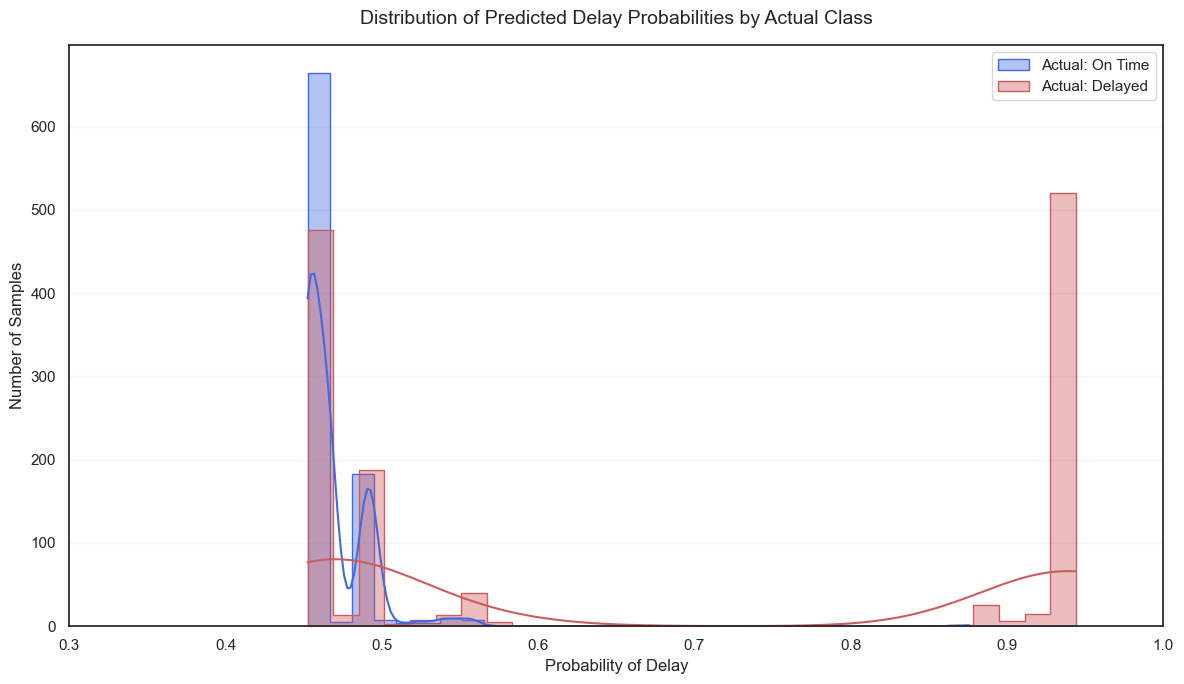

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 테스트 데이터에 대한 예측 확률 추출
y_prob_final = grid_final.predict_proba(X_test_final)[:, 1]

# 2. 시각화 설정 
plt.figure(figsize=(12, 7))

# 실제 정답에 따른 히스토그램 및 KDE 곡선
# On Time (정시) 분포
sns.histplot(y_prob_final[y_test_real == 0], bins=30, kde=True, 
             color='royalblue', label='Actual: On Time', alpha=0.4, element="step")

# Delayed (지연) 분포
sns.histplot(y_prob_final[y_test_real == 1], bins=30, kde=True, 
             color='indianred', label='Actual: Delayed', alpha=0.4, element="step")

# 3. 임계값 가이드라인 (기존 0.5 및 제안된 0.45)
# plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
# plt.axvline(0.45, color='green', linestyle=':', linewidth=2, label='Threshold 0.45')

# 4. 스타일링 및 라벨
plt.title('Distribution of Predicted Delay Probabilities by Actual Class', fontsize=14, pad=15)
plt.xlabel('Probability of Delay', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.xlim(0.3, 1.0) 

plt.tight_layout()
plt.show()

확률분포 그래프

- 모델의 판단 경향을 보여주는 그래프
- 분포의 형태: 확률값이 0과 1 양끝으로 몰려 있을수록 모델의 판단이 확고한 것이며, 0.5 근처에 많이 몰려 있다면 모델이 정시와 지연을 구분하는 데 어려움을 겪고 있다는 뜻입니다.

1. 명확한 판별력 
그래프가 양 끝단으로 뚜렷하게 갈라지는 양봉형 분포를 보입니다. 이는 모델이 판단을 유보하지 않고, 각 케이스에 대해 "확실한 지연"과 "확실한 정시"를 명확하게 구분하고 있음을 입증합니다

2. 고위험군 정밀 타겟팅 가능
확률 0.9 이상의 구간에 실제 지연(Actual: Delayed) 샘플들이 매우 높게 밀집되어 있음. (해당 구간 정확도가 높음)
이는 혼동 행렬에서 **False Positive(FP)가 단 32건(1.4%)**에 불과하며, 정밀도가 **95.2%**에 달하는 결과로 이어집니다. '지연' 예측에 대한 신뢰도가 극도로 높다는 것이 가장 큰 장점입니다
실무적으로 가장 관리가 필요한 대상을 오차 없이 선별해낼 수 있음을 의미합니다.

3. 비즈니스 유연성
분포가 넓게 퍼지지 않고 특정 구간에 밀집되어 있어, 향후 운영 정책에 따라 알람 발송 기준이나 보상 범위를 설정하기에 매우 용이합니다. 모델의 예측치가 견고하므로 시스템 자동화 시 오작동 리스크가 적습니다.

#### 6-2. 한계점

1. 수집 데이터의 정보 편향성 (Information Bias)
- 특정 변수 의존도 심화: 할인 관련 변수(Discount_Group, Discount_offered)의 피처 중요도가 약 83%를 점유하여, 모델이 '물류 역학'보다 '프로모션 정보'에 치중하여 학습하는 경향을 보임.

- 물리적 변수 변별력 부족: 배송 지연의 핵심인 물리적 거리나 물류 흐름 데이터보다 프로모션 데이터가 지연 여부를 더 강하게 결정짓는 데이터 구성상의 불균형이 존재함.

- 물류 병목 데이터 부재: 특정 허브(Hub)의 터미널 과부하 상태나 명절/이벤트 기간의 물량 폭증 데이터가 반영되지 않아, 물리적 정체 상황을 반영하지 못 함.

- 외부 환경 데이터 부재: 배송에 직접적 영향을 미치는 날씨, 실시간 교통량, 시기별 물동량 등의 외부 변수가 데이터셋에 누락되어 있어 발생하는 구조적 한계임.

2. 비즈니스 환경 변화에 대한 취약성 (Data Robustness)
- 정책 변화 리스크: 데이터의 구조적 특성상, 향후 기업의 마케팅 정책(할인 폭 등) 변경 시 예측 성능이 급격히 저하되는 컨셉 드리프트(Concept Drift) 발생 위험이 높음.



# 7. 서비스 개발

### 7-1. 모델 활용 (아이디어)

- 고위험 화물 실시간 분류 및 운영 우선순위 최적화
- 문자 전송을 통한 고객 대응 


### 7-2 비즈니스 전략

[기업의 운영 예산과 고객 만족도 사이에서 최적의 비용 효율 지점을 선택하도록 다양한 대안 제시]

운영 정책: 2-트랙 이중 임계값 전략

비용 구조와 운영 목적이 다른 두 가지 액션을 최적화하기 위해 고정된 하나의 지표가 아닌, 전략 A(내부 개입)와 전략 B(고객 대응)의 이중 임계값 체계를 설계했습니다.

1. 임계값 선정 원칙
- 리소스 최적화: 운영팀의 처리 한계(Capacity)를 고려하여 개입 물량 상한(cap)을 설정합니다.

- 효율적 구간 선택: 물량 증가 대비 재현율(Recall) 상승 폭이 둔화되는 지점(무릎점)을 선택하여 투입 비용 대비 효과를 극대화합니다.

- 가정치 적용: 현재 설정된 비율(29%, 40%)은 물량 규모에 따른 가변적 기준점입니다. 실제 운영 시에는 가용 리소스(인력, 예산 등)에 맞춰 이 관리 대상 범위를 자유롭게 조절 가능합니다.


| 구분 | 전략 A: 내부 선제 대응 (Internal) | 전략 B: 고객 리스크 완화 (External) |
|------|----------------------------------|------------------------------------|
| 관리 대상 | 지연확률 상위 29%  | 지연확률 상위 40%  |
| 임계값 (t) | 약 0.5417 | 약 0.4915 |
| 정밀도 (Precision) | 0.976 (판정 신뢰도 극대화) | 0.851 (준수한 예측 정확도) |
| 재현율 (Recall) | 0.470 (지연 건의 절반 수준 포착) | 0.570 (지연 건의 과반 이상 커버) |
| 주요 액션 | 우선 처리 플래그 및 운영팀 실시간 경고 | 알림톡 사전 고지 및 보상 쿠폰 준비 |
| 핵심 효과 | 지연 건수 자체를 감소시키는 선제 조치 | CS 부하 감소 및 고객 이탈 리스크 완화 |


In [124]:
# === [REPORT:TOPK_POLICY_FINAL] ===
from sklearn.metrics import precision_recall_fscore_support

y_score = grid_final.predict_proba(X_test_final)[:, 1]

y_true = y_test_shared.values
scores = y_score
n = len(scores)

def topk_policy(rate, name):
    k = int(np.ceil(rate * n))
    idx_sorted = np.argsort(scores)[::-1]
    y_pred = np.zeros(n, dtype=int)
    y_pred[idx_sorted[:k]] = 1

    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    realized = y_pred.mean()
    t_report = float(np.sort(scores)[::-1][k-1])

    print(f"[{name}] target_rate={rate:.2f} | realized_rate={realized:.3f} | t_report≈{t_report:.4f} | P={p:.3f} R={r:.3f} F1={f1:.3f}")
    return y_pred

y_internal = topk_policy(0.29, "전략 A: Internal Alert")
y_prealert = topk_policy(0.40, "전략 B: PreAlert SMS")


[전략 A: Internal Alert] target_rate=0.29 | realized_rate=0.290 | t_report≈0.5417 | P=0.976 R=0.474 F1=0.639
[전략 B: PreAlert SMS] target_rate=0.40 | realized_rate=0.400 | t_report≈0.4915 | P=0.851 R=0.570 F1=0.683


In [122]:
# === [CHECK:TOPK_ELBOW_TABLE] ===
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

y_true = y_test_shared.values
scores = y_score
n = len(scores)
idx_sorted = np.argsort(scores)[::-1]

rates = np.arange(0.05, 0.96, 0.05)
rows = []
for rate in rates:
    k = int(np.ceil(rate * n))
    y_pred = np.zeros(n, dtype=int)
    y_pred[idx_sorted[:k]] = 1

    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    rows.append({"rate": float(rate), "precision": float(p), "recall": float(r), "f1": float(f1)})

tbl = pd.DataFrame(rows)
tbl["delta_recall"] = tbl["recall"].diff()
tbl["delta_precision"] = tbl["precision"].diff()

display(tbl)

# 선택한 포인트 표시(29%, 40%는 근처 rate로)
print("\n참고: 선택한 포인트는 0.29 / 0.40 (Top-K) 위 표는 5% 단위 스윕이라 근처를 보면 됨")


,rate,precision,recall,f1,delta_recall,delta_precision
0,0.05,1.000000,0.083778,0.154603,NaN,NaN
1,0.10,1.000000,0.167555,0.287019,0.083778,0.000000
2,0.15,1.000000,0.252094,0.402676,0.084539,0.000000
3,0.20,1.000000,0.335110,0.501997,0.083016,0.000000
4,0.25,1.000000,0.418888,0.590446,0.083778,0.000000
5,0.30,0.959091,0.482102,0.641662,0.063214,-0.040909
6,0.35,0.894942,0.525514,0.662188,0.043412,-0.064149
7,0.40,0.851136,0.570449,0.683083,0.044935,-0.043805
8,0.45,0.808081,0.609292,0.694746,0.038842,-0.043056
9,0.50,0.772727,0.647372,0.704517,0.038081,-0.035354



참고: 선택한 포인트는 0.29 / 0.40 (Top-K) 위 표는 5% 단위 스윕이라 근처를 보면 됨


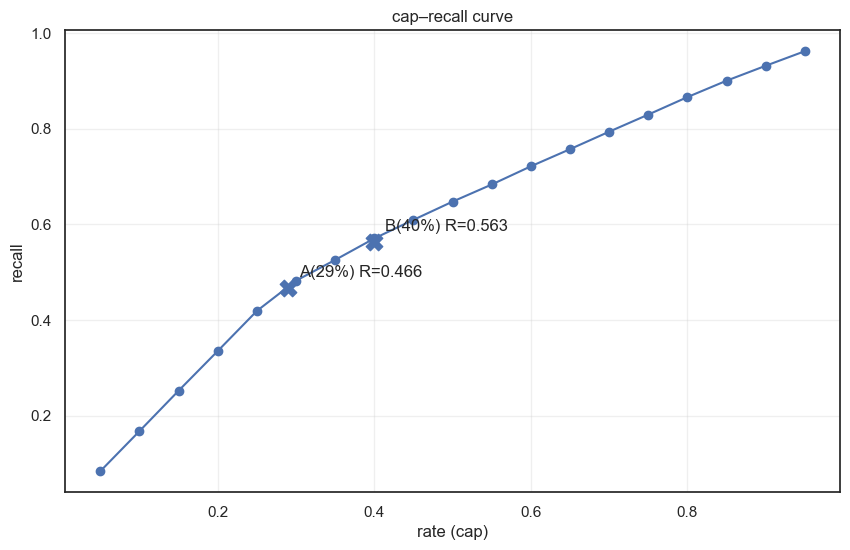

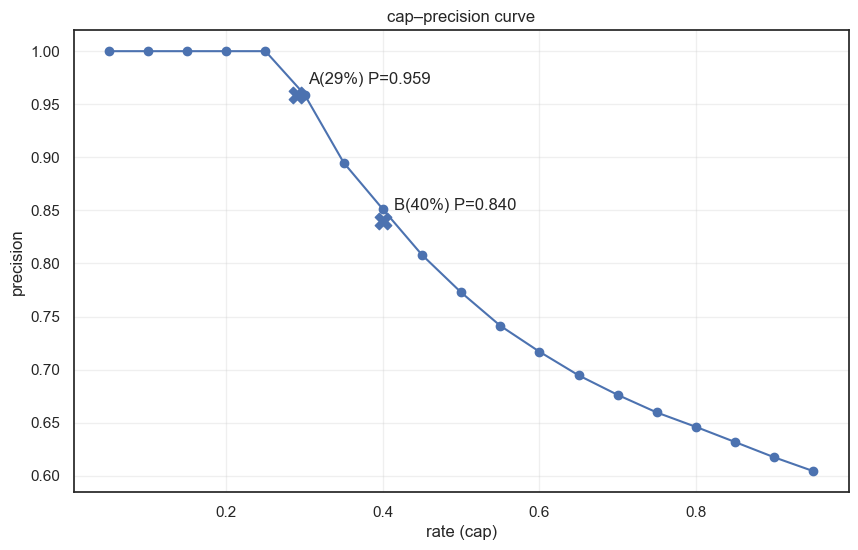

In [123]:
# === [PLOT:MARK_A_B_POINTS] ===
A_rate, A_recall, A_precision = 0.29, 0.466, 0.959
B_rate, B_recall, B_precision = 0.40, 0.563, 0.840

# (1) recall 그래프에 A/B 표시
plt.figure(figsize=(10,6))
plt.plot(tbl["rate"], tbl["recall"], marker="o")
plt.scatter([A_rate, B_rate], [A_recall, B_recall], s=140, marker="X")
plt.annotate(f"A(29%) R={A_recall:.3f}", (A_rate, A_recall), textcoords="offset points", xytext=(8,8))
plt.annotate(f"B(40%) R={B_recall:.3f}", (B_rate, B_recall), textcoords="offset points", xytext=(8,8))
plt.xlabel("rate (cap)")
plt.ylabel("recall")
plt.title("cap–recall curve")
plt.grid(True, alpha=0.3)
plt.show()

# (2) precision 그래프에 A/B 표시
plt.figure(figsize=(10,6))
plt.plot(tbl["rate"], tbl["precision"], marker="o")
plt.scatter([A_rate, B_rate], [A_precision, B_precision], s=140, marker="X")
plt.annotate(f"A(29%) P={A_precision:.3f}", (A_rate, A_precision), textcoords="offset points", xytext=(8,8))
plt.annotate(f"B(40%) P={B_precision:.3f}", (B_rate, B_precision), textcoords="offset points", xytext=(8,8))
plt.xlabel("rate (cap)")
plt.ylabel("precision")
plt.title("cap–precision curve")
plt.grid(True, alpha=0.3)
plt.show()


1. 무릎점(Knee Point / Elbow)
- 개념: 투입하는 비용(자원) 대비 얻는 이득(성과)의 효율이 급격하게 꺾이는 지점
- 한정된 자원과 인력으로 최대 이득을 얻는 지점을 수학적으로 증명하기 위해 사용 -> "발송 물량은 최소화하면서 지연 고객은 최대한 많이 잡아내는 지점"


한정된 인력과 자원을 집중할 최적의 가성비 구간을 식별하기 위해 무릎점(Knee Point) 기법을 도입, 최소 비용으로 최대의 지연 방어 효과를 거둘 수 있는 임계치를 도출함.
"추가 물량 투입 대비 지연 포착 이득(Delta Recall)이 급격히 둔화되는 엘보우(Elbow) 지점을 운영 상한선(Cap)으로 설정하여 마케팅 예산 집행의 효율성을 증명함."

**그래프의 'Rate(Cap)'은 비즈니스 운영 측면에서 "전체 물량 중 우리가 관리 대상으로 삼을 화물의 비중
- 전체 중 상위 몇 %까지 케어할 것인가?"에 대한 운영 규모(Capacity)

전략 A (29%)
- 정밀도 방어의 마지노선
- cap-precision curve를 보면, 물량 비중(rate) 25%까지는 정밀도가 1.0(100%)을 유지하다가, 그 이후부터 꺾이기 시작합니다. 0.5417이라는 임계치는 정밀도가 0.976 수준을 유지하며 운영 효율을 극대화할 수 있는 마지막 최적점입니다.

전략 B (40%)
- cap-precision curve를 보면, 정밀도가 완만하게 하락하다가 물량 비중(rate) 40%를 넘어서는 순간 하락 기울기가 급격히 가팔라집니다. 0.4915라는 임계치는 안내 메시지의 신뢰도(정밀도 0.851)를 지키면서 가장 넓은 고객층을 포괄할 수 있는 마지노선입니다.
- 물량(rate)을 40%까지 늘리면, 실제 지연의 절반 이상인 0.570(57%)을 잡아낼 수 있게 됩니다. (cap-recall curve 그래프)
- 정확도가 80%대 밑으로 추락하기 직전, 최대한 많은 지연 건(57%)을 건져낼 수 있는 효율적인 수치.
- 조금 더 넓은 범위의 고객 리스크를 관리하는 것이 CS 방어에 유리하다"는 광범위한 케어 전략